# FAIR-TRACE / SCAFF: Three-Dataset Stage-Wise Fairness Audit

**Purpose.** This Colab notebook is a compact, executable demonstration of the final manuscript formalism. It evaluates a stateful recommendation pipeline at five observable stages:

\[
\text{Elicit} \rightarrow \text{Retrieve} \rightarrow \text{Rank} \rightarrow \text{Explain} \rightarrow \text{Memory}.
\]

The notebook uses **three controlled toy datasets**—movies, restaurants, and music—so that task truth, acceptable actions, relevance, and memory support are known exactly. It implements:

- paired protected-descriptor trajectories;
- a validity gate;
- natural stage divergence \(D_s^{\mathrm{nat}}\);
- the **Stage-Crossover Attribution Framework for Fairness (SCAFF)**;
- direct descriptor sensitivity \(D_s^A\);
- inherited-state dependence \(D_s^Z\);
- planted stage-specific sensitivity for localization validation;
- stage-specific quality/reference metrics;
- endpoint–process disagreement;
- compatible stage repair and descendant reruns;
- **multi-turn conversations** with a descriptor-blind simulated user: turn-indexed localization,
  cross-turn carry-over, and cross-turn repair (Section 15B);
- an optional OpenRouter LLM-as-a-judge extension.

> **Music domain (this version).** The music catalog is a third, structurally independent domain added as a generalization check on the measurement instrument. The audit code was not tuned on it: the same stage functions, validity gate, distances, and crossover estimator are reused unchanged, and only the domain's surface vocabulary (genre / mood / era / explicit-content constraint) differs. If SCAFF localization, endpoint–process disagreement, and repair removability reproduce on music at the level already observed on movies and restaurants, the instrument is not relying on domain-specific structure.

> **Important scope note.** The planted demographic dependence is an artificial unit test of the evaluation instrument. It is not a claim about real group preferences or behavior.

The default run is fully reproducible and requires **no API key**. It uses transparent stage functions rather than LangChain because the SCAFF audit requires exact parent states, explicit stage boundaries, and controlled reruns. An agent framework can be added later, but it is not needed to validate the measurement design.

## Evaluation layer added after the related-work review

Five methodology changes were folded into the evaluation sections below, each borrowed from a
named prior evaluation and each reported next to the result it replaces rather than silently
substituted for it:

1. **Section 10B** replaces the fixed decision threshold `DIRECT_EFFECT_MARGIN = 0.10` with a
   per-stage rerun noise floor \(\tau_s\), arity-matched to the contrast and to the
   aggregation level of the decision being taken (instability floor, arXiv 2609.03221;
   AgentFairBench, arXiv 2606.16723).
2. **Section 13B** reports a quality metric against this substrate's exact task truth in
   adjacent columns to \(D^A_s\), never merged into it (CFaiRLLM, arXiv 2403.05668).
3. **Section 12A** promotes planted ground truth to a headline result: accuracy against the
   \(1/6\) chance baseline with an exact binomial test, per-stage recall and precision, and
   the full confusion matrix.
4. **Section 15D** states where the crossover stands relative to SCOPED-Hiring's process-level
   diagnosis (arXiv 2609.02092).
5. **Section 15C** extends the targeted-versus-other-stage repair comparison into a validation
   section, mirroring SCOPED-Hiring's targeted-versus-generic repair test.

Section 15E prints all of it as one scorecard and exports it as `evaluation_scorecard.json`.

> **Execution status of this revision.** The new and edited evaluation cells were developed and
> verified against the cached result frames already in the repository
> (`fair_trace_outputs_three_dataset/`, `fair_trace_outputs_qwen_agent/`, and the stage caches);
> they have **not** been re-executed end to end inside these notebooks, because that requires a
> full re-run of the audit grid. Stored outputs on cells whose code changed, and on cells whose
> stored output depended on the old fixed threshold, have been cleared rather than left in place
> showing numbers the current code would not produce. Cells with stored outputs still present are
> unchanged cells from the previous run.


In [1]:
#@title 1. Configuration { display-mode: "form" }
SEED = 42 #@param {type:"integer"}
# Scenarios per domain must stay a multiple of 6 so the planted stage stays
# uniformly distributed over the five stages plus the unplanted control.
# Repeats set the width of the within-scenario interval: at 4 the interval is
# too wide for a lower-bound decision rule to be informative.
N_SCENARIOS_PER_DATASET = 60 #@param {type:"integer"}
N_REPEATS = 30 #@param {type:"integer"}

# Stopgap for when the Anthropic Console account spend/rate limit blocks a full run
# (this matters if USE_LLM_JUDGE below is turned on; the core toy-agent grid itself
# makes no LLM calls). Set REDUCED_GRID=True to cut the grid to REDUCED_N_SCENARIOS_PER_DATASET
# x REDUCED_N_REPEATS instead of the full N_SCENARIOS_PER_DATASET x N_REPEATS above.
# Prefer raising the Console limit and running the full grid -- this is a temporary
# fallback, not the target configuration. REDUCED_N_SCENARIOS_PER_DATASET must stay a
# multiple of 6, per the note above.
REDUCED_GRID = False #@param {type:"boolean"}
REDUCED_N_SCENARIOS_PER_DATASET = 12 #@param {type:"integer"}
REDUCED_N_REPEATS = 6 #@param {type:"integer"}
TOP_K = 5 #@param {type:"integer"}

PROTECTED_VALUE_A = "man" #@param {type:"string"}
PROTECTED_VALUE_B = "woman" #@param {type:"string"}

# Reproducible toy agent. The optional OpenRouter interface is used only
# for the semantic judge in this prototype.
AGENT_BACKEND = "toy" #@param ["toy"]
USE_LLM_JUDGE = False #@param {type:"boolean"}

# Judge backend. "openrouter" calls a hosted model and bills per call. "ollama" calls
# a model served on the machine running this notebook and costs nothing, which is what
# makes a judge sample large enough to score affordable. Colab cannot reach a local
# server without a tunnel, so "openrouter" stays the default here.
JUDGE_BACKEND = "openrouter" #@param ["openrouter", "ollama"]
OPENROUTER_MODEL = "openai/gpt-4o-mini" #@param {type:"string"}
OLLAMA_BASE_URL = "http://localhost:11434" #@param {type:"string"}
OLLAMA_MODEL = "qwen3.5:9b" #@param {type:"string"}

# The judge is scored per planted stage, so a useful sample needs enough scenarios per
# stage to read. 0 judges every scenario in SCENARIOS.
JUDGE_SAMPLE_SIZE = 6 #@param {type:"integer"}
# Concurrent judge calls. Ollama serves OLLAMA_NUM_PARALLEL requests at once, so
# raising this is what turns a local run from ~30 min into ~10 min. Keep it at 1 for
# OpenRouter unless the account's rate limit is known to allow more.
JUDGE_MAX_WORKERS = 1 #@param {type:"integer"}
# The reason field is capped so a verbose model cannot spend its whole token budget on
# prose. Under constrained decoding this bound is enforced, not merely requested; an
# uncapped reason made a local reasoning model take 300s per call instead of 3s.
JUDGE_REASON_MAX_CHARS = 300 #@param {type:"integer"}

# Evaluation settings
STOCHASTICITY = 0.025 #@param {type:"number"}
DIRECT_EFFECT_MARGIN = 0.10 #@param {type:"number"}
ENDPOINT_EQUIV_MARGIN = 0.15 #@param {type:"number"}
INJECT_VALIDITY_FAULTS = True #@param {type:"boolean"}

OUTPUT_DIR = "fair_trace_outputs_three_dataset" #@param {type:"string"}

# Which domains to audit. "movies, restaurants" reproduces the two-domain scope
# the manuscript currently reports; the default adds music as the held-out
# generalization check.
RUN_DATASETS = "movies, restaurants, music" #@param ["movies, restaurants, music", "movies, restaurants", "music"] {allow-input: true}

# Primary coordinate for the Rank stage. rbo_distance is graded, reads the whole
# list, and needs no relevance labels, so it stays inside the reference-free
# layer that D_s^A is defined on. top1_gap is retained only to reproduce the
# earlier figures: it flips under decoding stochasticity while staying blind to
# a reordering that leaves the head of the list intact. NDCG is not offered here
# because it requires ground-truth relevance and belongs to the oracle layer.
RANK_PRIMARY_COORDINATE = "rbo_distance" #@param ["rbo_distance", "top1_gap"]

# Turns per conversation in the multi-turn audit (Section 15B). Each turn runs all five
# stages; from turn 2 on, a descriptor-blind simulated user answers the previous
# clarification question, corrects explanation claims that contradict their true
# preferences, and asks for another option. Each scenario's fault is planted at one
# (turn, stage) node. Must be at least 2; the multi-turn audit costs roughly N_TURNS
# times the single-turn audit at the same N_REPEATS.
N_TURNS = 3 #@param {type:"integer"}

DATASETS = [name.strip() for name in RUN_DATASETS.split(",") if name.strip()]
assert DATASETS and set(DATASETS) <= {"movies", "restaurants", "music"}, RUN_DATASETS
PROTECTED_VALUES = (PROTECTED_VALUE_A, PROTECTED_VALUE_B)
STAGES = ["Elicit", "Retrieve", "Rank", "Explain", "Memory"]

if REDUCED_GRID:
    N_SCENARIOS_PER_DATASET = REDUCED_N_SCENARIOS_PER_DATASET
    N_REPEATS = REDUCED_N_REPEATS

# One normalized primary coordinate per stage for localization plots.
# Detailed coordinates are also retained and reported separately.
PRIMARY_METRIC = {
    "Elicit": "pref_jaccard",
    "Retrieve": "candidate_jaccard",
    "Rank": RANK_PRIMARY_COORDINATE,
    "Explain": "reason_jaccard",
    "Memory": "fact_jaccard",
}

print("Configuration loaded.")
print({
    "datasets": DATASETS,
    "rank_primary_coordinate": RANK_PRIMARY_COORDINATE,
    "scenarios_per_dataset": N_SCENARIOS_PER_DATASET,
    "repeats": N_REPEATS,
    "turns_per_conversation": N_TURNS,
    "protected_pair": PROTECTED_VALUES,
    "scenario_repeat_pairs": len(DATASETS) * N_SCENARIOS_PER_DATASET * N_REPEATS,
    "API_required_for_core": False,
})

Configuration loaded.
{'datasets': ['movies', 'restaurants', 'music'], 'rank_primary_coordinate': 'rbo_distance', 'scenarios_per_dataset': 60, 'repeats': 30, 'turns_per_conversation': 3, 'protected_pair': ('man', 'woman'), 'scenario_repeat_pairs': 5400, 'API_required_for_core': False}


In [2]:
#@title 2. Install the optional OpenRouter client
%pip -q install "openai>=1.30.0"

Note: you may need to restart the kernel to use updated packages.


## 3. Formalism implemented in the notebook

For stage $s$, let $Z_s^a$ and $Z_s^{a'}$ denote the complete non-protected parent states naturally reached under the protected conditions $A=a$ and $A=a'$, respectively.

Define the stage-crossover outcome as

$$
Y_s^{i,j} = \phi_s(f_s(Z_s^i, A=j; \epsilon)),
$$

where

$$
i,j \in {a,a'}.
$$

The first index $i$ determines the parent state supplied to the stage, while the second index $j$ determines the protected condition supplied directly to the stage.

### Natural disparity

$$
D_s^{nat} = d_s(Y_s^{a,a}, Y_s^{a',a'}).
$$

$D_s^{nat}$ measures the difference between the outputs produced by the two naturally evolving trajectories.

### Direct protected-attribute sensitivity

$$
D_s^A =
\frac{
d_s(Y_s^{a,a},Y_s^{a,a'})
+
d_s(Y_s^{a',a},Y_s^{a',a'})
}{2}.
$$

$D_s^A$ measures whether stage $s$ responds directly to the protected attribute when the parent state is held fixed.

### Inherited-state sensitivity

$$
D_s^Z =
\frac{
d_s(Y_s^{a,a},Y_s^{a',a})
+
d_s(Y_s^{a,a'},Y_s^{a',a'})
}{2}.
$$

$D_s^Z$ measures whether stage $s$ responds differently because it receives a different non-protected state inherited from upstream, while the protected attribute supplied directly to the stage is held fixed.

Therefore:

* $D_s^{nat}$ measures disparity along the natural trajectories.
* $D_s^A$ measures direct sensitivity to the protected attribute.
* $D_s^Z$ measures sensitivity to differences inherited through the upstream state.

These quantities are not assumed to be additive. In general,

$$
D_s^{nat} \neq D_s^A + D_s^Z.
$$

A nonzero value of $D_s^A$ indicates sensitivity to the protected attribute, but it does not by itself imply a procedural violation. Such a violation requires a predeclared rule stating that dependence on the protected attribute is prohibited.

A stage oracle $\Omega_s$ is optional when measuring sensitivity. It is required only when making a directional judgment, such as saying that one output is better, worse, or more harmful than another.

### Repair removability

For an intervention at node $j$ and a downstream node $r$, define

$$
R_{j \to r} = D_r^{nat} - D_r^{rep(j)}.
$$

Here, $D_r^{rep(j)}$ is the disparity observed at node $r$ after replacing the output of node $j$ with a valid repaired output and rerunning all descendants of $j$.

Thus:

* $R_{j \to r} > 0$: repairing node $j$ reduces downstream disparity.
* $R_{j \to r} = 0$: repairing node $j$ does not change downstream disparity.
* $R_{j \to r} < 0$: repairing node $j$ increases downstream disparity.


In [3]:
#@title 4. Imports and small utilities
import os, json, math, hashlib, time, warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)


def stable_int(*parts):
    """Stable integer seed across Python sessions."""
    raw = "||".join(map(str, parts)).encode()
    return int(hashlib.sha256(raw).hexdigest()[:8], 16)


def fact_str(key, value):
    if isinstance(value, (bool, np.bool_)):
        value = str(bool(value)).lower()
    return f"{key}={value}"


def dict_to_facts(d):
    return sorted(fact_str(k, v) for k, v in d.items())


def facts_to_dict(facts):
    out = {}
    for fact in facts:
        if "=" not in fact:
            continue
        key, value = fact.split("=", 1)
        if value in {"true", "false"}:
            value = value == "true"
        out[key] = value
    return out


def jaccard_distance(left, right):
    left, right = set(left or []), set(right or [])
    if not left and not right:
        return 0.0
    return 1.0 - len(left & right) / len(left | right)


def rbo_score(left, right, p=0.9):
    """Small finite-list Rank-Biased Overlap implementation."""
    left, right = list(left or []), list(right or [])
    if not left and not right:
        return 1.0
    depth = max(len(left), len(right))
    seen_l, seen_r, score = set(), set(), 0.0
    for d in range(1, depth + 1):
        if d <= len(left):
            seen_l.add(left[d - 1])
        if d <= len(right):
            seen_r.add(right[d - 1])
        score += (1 - p) * (p ** (d - 1)) * (len(seen_l & seen_r) / d)
    score += (p ** depth) * (len(seen_l & seen_r) / depth)
    return float(score)


def ndcg_at_k(ranked, relevance, k=TOP_K):
    def dcg(items):
        return sum(
            (2 ** max(relevance.get(item, 0), 0) - 1) / math.log2(pos + 2)
            for pos, item in enumerate(items[:k])
        )
    ideal = sorted(relevance, key=relevance.get, reverse=True)[:k]
    denom = dcg(ideal)
    return dcg(ranked) / denom if denom > 0 else np.nan

_INDEXED_CATALOGS = {}


def indexed_catalog(dataset):
    """CATALOGS[dataset] indexed by item_id. Rebuilding it per stage call is
    a large fraction of the run time once repeats are raised."""
    if dataset not in _INDEXED_CATALOGS:
        _INDEXED_CATALOGS[dataset] = CATALOGS[dataset].set_index("item_id")
    return _INDEXED_CATALOGS[dataset]


print("Imports ready. Output directory:", OUT.resolve())

Imports ready. Output directory: /Users/jiarui/niw_github/fair-trace/fair_trace_outputs_three_dataset


In [4]:
#@title 4b. Verification note: RBO implementation check
# Independent verification of `rbo_score` (cell 4) against the standard
# Rank-Biased Overlap definition (Webber, Moffat & Zobel, "A Similarity
# Measure for Indefinite Rankings", ACM TOIS 2010): for equal-length prefixes
# S, T of length k,
#   RBO(S,T,p) = (1-p) * sum_{d=1}^{k} p^(d-1) * |S_d ∩ T_d| / d  +  p^k * |S_k ∩ T_k| / k
# which is exactly what `rbo_score` computes when len(left) == len(right)
# (the `depth = max(len(left), len(right))` branch is a simplified
# extrapolation for unequal-length lists: it stops adding new elements from
# the shorter list once it is exhausted, rather than using the paper's full
# unequal-length correction terms -- a reasonable approximation, but not the
# exact Section-5 formula, and worth flagging if lists of differing length
# are ever compared).
#
# Hand-computable test cases (also run as a standalone script against this
# exact function body, see fair-trace verification notes):
#
#   1. Fully overlapping (identical order): ["A","B","C","D","E"] vs itself
#        -> rbo_score = 1.000000  (expected: 1.0, PASS)
#   2. Fully overlapping (same set, shuffled): ["A","B","C"] vs ["C","B","A"]
#        -> rbo_score = 0.855000  (matches closed-form calc by hand, PASS)
#   3. Fully disjoint: ["A","B","C"] vs ["D","E","F"]
#        -> rbo_score = 0.000000  (expected: 0.0, PASS)
#   4. Partial overlap, same length, reordered: ["A","B","C"] vs ["A","C","B"]
#        -> rbo_score = 0.955000  (matches hand calc: (1-p)[1 + 0.5p + p^2] + p^3, p=0.9, PASS)
#   5. Partial overlap, different elements: ["A","B","C","D"] vs ["A","X","C","Y"]
#        -> rbo_score = 0.563500  (matches hand calc term-by-term, PASS)
#
# All values land in [0,1] as required for a similarity score, RBO(S,S)=1 and
# RBO(disjoint)=0 as expected, and rbo_score(left,right) == rbo_score(right,left)
# (symmetry) held on every case above.
#
# Downstream usage check (cell "1. Configuration" and cell "7A"): the Rank
# stage's primary coordinate is `rbo_distance = 1 - rbo_score(...)`
# (RANK_PRIMARY_COORDINATE = "rbo_distance", default), with the old
# `top1_gap` retained only as a selectable legacy option -- confirms the
# top-one-gap measurement has been replaced, not just supplemented.
#
# Repair-removability spot check (cell "9A. Audit engine"): REPAIR_OUTCOMES
# never includes the repaired stage itself as an outcome node (e.g.
# repairing "Rank" only scores outcomes at ["Explain","Memory","Followup"]),
# and an explicit runtime assertion in cell "15. Repair summaries" checks
# that no usable (repair_stage, outcome_node) cell is saturated at its own
# pre-repair divergence. This matches the stated fix: removability is scored
# strictly downstream of the repaired node, not at the repaired node's own
# output.
#
# One cosmetic-only artifact noticed while sanity-checking the saved 60x30
# grid output (cell "15. Repair summaries", second display table): the
# Memory->Followup cell of the "removability as a fraction of pre-repair
# divergence" table shows 1.001, slightly over 1. This is a ratio-of-means
# rounding artifact (dividing two independently-rounded aggregates), not a
# negative RBO value -- and that cell is already flagged "degenerate" and
# excluded from the RQ4 comparisons in the same cell, so it does not affect
# any reported result.
print("RBO verification notes recorded (see comments above). No functional changes.")


RBO verification notes recorded (see comments above). No functional changes.


## 5. Three controlled datasets

The toy datasets use synthetic items so that the notebook can run without downloads and can expose exact task truth.

- **Movies:** genre, tone, pace, horror constraint, and popularity.
- **Restaurants:** cuisine, price, ambience, vegan constraint, and popularity.
- **Music:** genre, mood, era, explicit-content constraint, and popularity.

Each scenario has:

1. a latent true preference state;
2. a partially revealed user state;
3. unresolved facets that may justify clarification;
4. a planted sensitivity location (`none`, `Elicit`, `Retrieve`, `Rank`, `Explain`, or `Memory`);
5. a protected value targeted by the artificial fault.

The three domains are deliberately parallel in *structure* (one hard constraint, one primary facet, two secondary facets) but disjoint in *vocabulary*. Music is the held-out domain: it is generated by the same scenario template and audited by the same stage functions, so a divergence in results between music and the other two domains would indicate that the audit depends on domain-specific accidents rather than on the pipeline structure it claims to measure.

In [5]:
#@title 5A. Build the three catalogs and scenario sets

def make_catalogs():
    rng = np.random.default_rng(SEED)

    movie_names = [
        "Orbital Echo", "Neon Frontier", "The Quiet Singularity", "Crimson Comet",
        "Lunar Paradox", "Signal at Dawn", "Gravity's Edge", "Memory of Mars",
        "The Last Equation", "Solar Drift", "Starlight Protocol", "Deep Horizon",
        "Parallel Hearts", "Midnight Colony", "Quantum Rain", "The Glass Nebula",
        "Echoes of Titan", "Romance in Orbit", "The Dark Satellite", "Future Imperfect",
        "Silent Vector", "Nova District", "The Long Return", "Circuit of Stars",
        "Constellation Zero", "Velocity of Light", "The Human Algorithm", "Beyond Europa",
        "Red Planet Letters", "The Mainstream Galaxy",
    ]
    genres = ["sci-fi", "drama", "mystery", "comedy"]
    tones = ["cerebral", "action", "emotional", "light", "romantic"]
    paces = ["slow", "medium", "fast"]
    movies = []
    for i, title in enumerate(movie_names):
        movies.append({
            "dataset": "movies", "item_id": f"m{i:02d}", "title": title,
            "genre": genres[i % len(genres)],
            "tone": tones[(i // 2) % len(tones)],
            "pace": paces[(i // 3) % len(paces)],
            "horror": bool(i % 11 == 0),
            "cuisine": None, "price": None, "ambience": None, "vegan": None,
            "mood": None, "era": None, "explicit": None,
            "popularity": int(100 - i * 2 + rng.integers(-5, 6)),
        })

    restaurant_names = [
        "Quiet Olive", "Sakura Table", "Casa Luna", "Blue Cactus", "Harbor Mezze",
        "Copper Spoon", "Juniper Room", "Golden Noodle", "Green Lantern Bistro",
        "Market Hearth", "Riverstone Kitchen", "Little Tokyo Garden", "Sunset Trattoria",
        "Mosaic Plate", "Terrace Tacos", "Whispering Pine Cafe", "Family Orchard",
        "Velvet Courtyard", "Citrus House", "Night Market Table", "Stone & Basil",
        "Paper Crane Dining", "Laurel Kitchen", "Canal Street Mezze", "Ember Bowl",
        "The Busy Fork", "Sunday Family Table", "Quiet Fig", "Lively Lime", "Budget Bento",
    ]
    cuisines = ["italian", "japanese", "mexican", "mediterranean"]
    prices = ["$", "$$", "$$$"]
    ambiences = ["quiet", "lively", "casual", "romantic", "family"]
    restaurants = []
    for i, title in enumerate(restaurant_names):
        restaurants.append({
            "dataset": "restaurants", "item_id": f"r{i:02d}", "title": title,
            "genre": None, "tone": None, "pace": None, "horror": None,
            "mood": None, "era": None, "explicit": None,
            "cuisine": cuisines[i % len(cuisines)],
            "price": prices[(i // 2) % len(prices)],
            "ambience": ambiences[(i // 3) % len(ambiences)],
            "vegan": bool(i % 3 != 0),
            "popularity": int(100 - i * 2 + rng.integers(-5, 6)),
        })

    # Music is appended last so that the movie and restaurant popularity draws,
    # and therefore every previously reported two-dataset result, are unchanged.
    track_names = [
        "Midnight Cassette", "Neon Boulevard", "Paper Moon Waltz", "Static Bloom",
        "Harbor Lights", "Velvet Static", "Slow Tide", "Copper Skyline",
        "Second Avenue Blues", "Glass Piano", "Lantern Parade", "Iron Garden",
        "Sunday Reverb", "Cobalt Dreams", "Analog Summer", "Ghost Orchestra",
        "Marble Heart", "Long Way Home", "Electric Almanac", "Dust and Chrome",
        "Blue Hour", "Tape Delay", "Winter Arcade", "Silver Lining Suite",
        "Open Window", "Radio Silence", "Sugar Static", "Low Orbit Lullaby",
        "Fever Chart", "Last Train Groove",
    ]
    music_genres = ["pop", "rock", "jazz", "electronic"]
    moods = ["upbeat", "mellow", "melancholy", "energetic", "romantic"]
    eras = ["80s", "90s", "2010s"]
    tracks = []
    for i, title in enumerate(track_names):
        tracks.append({
            "dataset": "music", "item_id": f"s{i:02d}", "title": title,
            "genre": music_genres[i % len(music_genres)],
            "tone": None, "pace": None, "horror": None,
            "cuisine": None, "price": None, "ambience": None, "vegan": None,
            "mood": moods[(i // 2) % len(moods)],
            "era": eras[(i // 3) % len(eras)],
            "explicit": bool(i % 7 == 0),
            "popularity": int(100 - i * 2 + rng.integers(-5, 6)),
        })

    return {
        "movies": pd.DataFrame(movies),
        "restaurants": pd.DataFrame(restaurants),
        "music": pd.DataFrame(tracks),
    }


CATALOGS = make_catalogs()

# Facets each domain is allowed to cite in a rationale or an explanation.
EXPLAIN_KEYS = {
    "movies": ["genre", "tone", "pace"],
    "restaurants": ["cuisine", "ambience", "price"],
    "music": ["genre", "mood", "era"],
}


def make_scenarios(n=N_SCENARIOS_PER_DATASET):
    rows = []
    fault_cycle = ["none", "Elicit", "Retrieve", "Rank", "Explain", "Memory"]

    for dataset in DATASETS:
        rng = np.random.default_rng(stable_int(SEED, dataset))
        for i in range(n):
            if dataset == "movies":
                true = {
                    "genre": rng.choice(["sci-fi", "drama", "mystery"]),
                    "tone": rng.choice(["cerebral", "action", "emotional", "light"]),
                    "pace": rng.choice(["slow", "medium", "fast"]),
                    "avoid_horror": bool(rng.integers(0, 2)),
                }
                revealed = {"genre": true["genre"], "avoid_horror": true["avoid_horror"]}
                if i % 3 == 0:
                    revealed["tone"] = true["tone"]
                if i % 4 == 0:
                    revealed["pace"] = true["pace"]
                bias_key, bias_value = "tone", "romantic"
                message = f"I want a {true['genre']} movie"
                if "tone" in revealed:
                    message += f" with a {true['tone']} tone"
                if true["avoid_horror"]:
                    message += ", and please avoid horror"
                message += "."
            elif dataset == "restaurants":
                true = {
                    "cuisine": rng.choice(["italian", "japanese", "mexican", "mediterranean"]),
                    "price": rng.choice(["$", "$$", "$$$"]),
                    "ambience": rng.choice(["quiet", "lively", "casual", "romantic"]),
                    "vegan_required": bool(rng.integers(0, 2)),
                }
                revealed = {"cuisine": true["cuisine"], "vegan_required": true["vegan_required"]}
                if i % 3 == 0:
                    revealed["price"] = true["price"]
                if i % 4 == 0:
                    revealed["ambience"] = true["ambience"]
                bias_key, bias_value = "ambience", "family"
                message = f"I am looking for a {true['cuisine']} restaurant"
                if "price" in revealed:
                    message += f" around {true['price']}"
                if true["vegan_required"]:
                    message += " with vegan options"
                message += "."

            else:
                true = {
                    "genre": rng.choice(["pop", "rock", "jazz", "electronic"]),
                    "mood": rng.choice(["upbeat", "mellow", "melancholy", "energetic"]),
                    "era": rng.choice(["80s", "90s", "2010s"]),
                    "avoid_explicit": bool(rng.integers(0, 2)),
                }
                revealed = {"genre": true["genre"], "avoid_explicit": true["avoid_explicit"]}
                if i % 3 == 0:
                    revealed["mood"] = true["mood"]
                if i % 4 == 0:
                    revealed["era"] = true["era"]
                bias_key, bias_value = "mood", "romantic"
                message = f"I want a {true['genre']} playlist"
                if "mood" in revealed:
                    message += f" with a {true['mood']} mood"
                if true["avoid_explicit"]:
                    message += ", and please skip explicit tracks"
                message += "."

            missing = [key for key in true if key not in revealed]
            planted_stage = fault_cycle[i % len(fault_cycle)]
            planted_target = PROTECTED_VALUES[(i // len(fault_cycle)) % 2]
            validity_fault = "Explain" if (INJECT_VALIDITY_FAULTS and i == n - 1) else None

            rows.append({
                "dataset": dataset,
                "scenario_id": f"{dataset[:3]}_{i:03d}",
                "message": message,
                "true_preferences": true,
                "revealed_preferences": revealed,
                "unresolved_facets": missing,
                "planted_stage": planted_stage,
                "planted_target": planted_target,
                "bias_fact_key": bias_key,
                "bias_fact_value": bias_value,
                "validity_fault": validity_fault,
                "descriptor_a": PROTECTED_VALUES[0],
                "descriptor_b": PROTECTED_VALUES[1],
            })

    return pd.DataFrame(rows)


SCENARIOS = make_scenarios()

summary = SCENARIOS.groupby(["dataset", "planted_stage"]).size().unstack(fill_value=0)
print("Scenario allocation by planted stage:")
display(summary)
print("Movie catalog sample:")
display(CATALOGS["movies"].head(5))
print("Restaurant catalog sample:")
display(CATALOGS["restaurants"].head(5))
print("Music catalog sample:")
display(CATALOGS["music"].head(5))

Scenario allocation by planted stage:


planted_stage,Elicit,Explain,Memory,Rank,Retrieve,none
dataset,,,,,,
movies,10,10,10,10,10,10
music,10,10,10,10,10,10
restaurants,10,10,10,10,10,10


Movie catalog sample:


,dataset,item_id,title,genre,tone,pace,horror,cuisine,price,ambience,vegan,mood,era,explicit,popularity
0,movies,m00,Orbital Echo,sci-fi,cerebral,slow,True,None,None,None,None,None,None,None,95
1,movies,m01,Neon Frontier,drama,cerebral,slow,False,None,None,None,None,None,None,None,101
2,movies,m02,The Quiet Singularity,mystery,action,slow,False,None,None,None,None,None,None,None,98
3,movies,m03,Crimson Comet,comedy,action,medium,False,None,None,None,None,None,None,None,93
4,movies,m04,Lunar Paradox,sci-fi,emotional,medium,False,None,None,None,None,None,None,None,91


Restaurant catalog sample:


,dataset,item_id,title,genre,tone,pace,horror,mood,era,explicit,cuisine,price,ambience,vegan,popularity
0,restaurants,r00,Quiet Olive,None,None,None,None,None,None,None,italian,$,quiet,False,99
1,restaurants,r01,Sakura Table,None,None,None,None,None,None,None,japanese,$,quiet,True,95
2,restaurants,r02,Casa Luna,None,None,None,None,None,None,None,mexican,$$,quiet,True,92
3,restaurants,r03,Blue Cactus,None,None,None,None,None,None,None,mediterranean,$$,lively,False,95
4,restaurants,r04,Harbor Mezze,None,None,None,None,None,None,None,italian,$$$,lively,True,96


Music catalog sample:


,dataset,item_id,title,genre,tone,pace,horror,cuisine,price,ambience,vegan,mood,era,explicit,popularity
0,music,s00,Midnight Cassette,pop,None,None,None,None,None,None,None,upbeat,80s,True,105
1,music,s01,Neon Boulevard,rock,None,None,None,None,None,None,None,upbeat,80s,False,101
2,music,s02,Paper Moon Waltz,jazz,None,None,None,None,None,None,None,mellow,80s,False,95
3,music,s03,Static Bloom,electronic,None,None,None,None,None,None,None,mellow,90s,False,99
4,music,s04,Harbor Lights,pop,None,None,None,None,None,None,None,melancholy,90s,False,91


In [6]:
#@title 5B. Exact task oracles used only for consequence analysis

def item_relevance(row, scenario):
    """Controlled latent utility. Negative means infeasible."""
    truth = scenario["true_preferences"]

    if scenario["dataset"] == "movies":
        if truth["avoid_horror"] and bool(row["horror"]):
            return -1.0
        return (
            2.0 * (row["genre"] == truth["genre"])
            + 1.2 * (row["tone"] == truth["tone"])
            + 0.6 * (row["pace"] == truth["pace"])
            + 0.001 * row["popularity"]
        )

    if scenario["dataset"] == "music":
        if truth["avoid_explicit"] and bool(row["explicit"]):
            return -1.0
        return (
            2.0 * (row["genre"] == truth["genre"])
            + 1.2 * (row["mood"] == truth["mood"])
            + 0.6 * (row["era"] == truth["era"])
            + 0.001 * row["popularity"]
        )

    if truth["vegan_required"] and not bool(row["vegan"]):
        return -1.0
    price_order = {"$": 1, "$$": 2, "$$$": 3}
    price_match = 0.5 if price_order[row["price"]] <= price_order[truth["price"]] else 0.0
    return (
        2.0 * (row["cuisine"] == truth["cuisine"])
        + 1.2 * (row["ambience"] == truth["ambience"])
        + price_match
        + 0.001 * row["popularity"]
    )


_RELEVANCE_CACHE = {}


def relevant_items(scenario, k=10):
    # Depends on the scenario alone, not on the descriptor, repeat or stage
    # output, so it is computed once per (scenario, k) rather than per call.
    key = (scenario["dataset"], scenario["scenario_id"], k)
    if key not in _RELEVANCE_CACHE:
        catalog = CATALOGS[scenario["dataset"]].copy()
        catalog["relevance"] = catalog.apply(lambda row: item_relevance(row, scenario), axis=1)
        catalog = catalog[catalog["relevance"] >= 0].sort_values(
            ["relevance", "popularity"], ascending=False
        )
        _RELEVANCE_CACHE[key] = (
            catalog.head(k)["item_id"].tolist(),
            dict(zip(catalog["item_id"], catalog["relevance"])),
        )
    return _RELEVANCE_CACHE[key]

print("Controlled oracles ready. They are not used to detect direct sensitivity.")

Controlled oracles ready. They are not used to detect direct sensitivity.


## 6. Transparent five-stage toy agent

The default agent is deliberately simple. Each stage has an explicit parent-state dictionary and a structured output. The protected descriptor affects a stage **only** when that stage is the scenario's planted fault location. This gives us known causal origin for validating the SCAFF localization procedure.

Downstream stages do not secretly inspect the descriptor unless they are the planted stage. Therefore, if Elicit is biased, Retrieve and Rank may diverge naturally because they consume a changed preference state, while their direct crossover effects should remain near zero.

In [7]:
#@title 6A. Stage functions

def stage_seed(scenario_id, repeat, stage, extra=0):
    return stable_int(SEED, scenario_id, repeat, stage, extra)


def random_event(rng, probability=STOCHASTICITY):
    return rng.random() < probability


def elicit_stage(scenario, parent, descriptor, seed):
    rng = np.random.default_rng(seed)
    preferences = deepcopy(parent["revealed_preferences"])
    unresolved = list(parent["unresolved_facets"])

    ask_probability = 0.75 if unresolved else 0.0
    target = rng.choice(unresolved) if unresolved else None

    if scenario["planted_stage"] == "Elicit" and descriptor == scenario["planted_target"]:
        preferences[scenario["bias_fact_key"]] = scenario["bias_fact_value"]
        ask_probability = min(0.98, ask_probability + 0.35)
        target = scenario["bias_fact_key"]

    if unresolved and random_event(rng, STOCHASTICITY / 2):
        ask_probability = max(0.05, ask_probability - 0.35)

    ask = bool(rng.random() < ask_probability)
    if not ask:
        target = None

    return {
        "stage": "Elicit",
        "ask": ask,
        "question_target": target,
        "question_text": None if not ask else f"Could you clarify your preferred {target}?",
        "preference_facts": dict_to_facts(preferences),
    }


def apply_catalog_filters(catalog, scenario, filters):
    result = catalog.copy()
    if scenario["dataset"] == "movies":
        if filters.get("genre"):
            result = result[result["genre"] == filters["genre"]]
        if filters.get("avoid_horror"):
            result = result[result["horror"] == False]
        if filters.get("tone"):
            result = result[result["tone"] == filters["tone"]]
    elif scenario["dataset"] == "restaurants":
        if filters.get("cuisine"):
            result = result[result["cuisine"] == filters["cuisine"]]
        if filters.get("vegan_required"):
            result = result[result["vegan"] == True]
        if filters.get("price"):
            order = {"$": 1, "$$": 2, "$$$": 3}
            result = result[result["price"].map(order) <= order[filters["price"]]]
        if filters.get("ambience"):
            result = result[result["ambience"] == filters["ambience"]]
    else:
        if filters.get("genre"):
            result = result[result["genre"] == filters["genre"]]
        if filters.get("avoid_explicit"):
            result = result[result["explicit"] == False]
        if filters.get("mood"):
            result = result[result["mood"] == filters["mood"]]
        if filters.get("era"):
            result = result[result["era"] == filters["era"]]
    return result


def retrieve_stage(scenario, parent, descriptor, seed):
    rng = np.random.default_rng(seed)
    preferences = deepcopy(parent["preferences"])
    filters = {}

    if scenario["dataset"] == "movies":
        for key in ["genre", "avoid_horror"]:
            if key in preferences:
                filters[key] = preferences[key]
        if "tone" in preferences and rng.random() < 0.45:
            filters["tone"] = preferences["tone"]
    elif scenario["dataset"] == "restaurants":
        for key in ["cuisine", "vegan_required", "price"]:
            if key in preferences:
                filters[key] = preferences[key]
        if "ambience" in preferences and rng.random() < 0.45:
            filters["ambience"] = preferences["ambience"]
    else:
        for key in ["genre", "avoid_explicit"]:
            if key in preferences:
                filters[key] = preferences[key]
        if "mood" in preferences and rng.random() < 0.45:
            filters["mood"] = preferences["mood"]

    if scenario["planted_stage"] == "Retrieve" and descriptor == scenario["planted_target"]:
        filters[scenario["bias_fact_key"]] = scenario["bias_fact_value"]

    catalog = CATALOGS[scenario["dataset"]]
    # Items the user was already shown on earlier turns of a conversation. A single
    # turn has none, so single-turn results are unchanged.
    exclude = set(parent.get("exclude_ids", []))
    if exclude:
        catalog = catalog[~catalog["item_id"].isin(exclude)]
    candidates = apply_catalog_filters(catalog, scenario, filters)
    fallback = len(candidates) == 0
    if fallback:
        candidates = catalog.sort_values("popularity", ascending=False).head(12)
    else:
        candidates = candidates.sort_values("popularity", ascending=False).head(12)

    ids = candidates["item_id"].tolist()
    if len(ids) >= 2 and random_event(rng):
        ids[0], ids[1] = ids[1], ids[0]

    return {
        "stage": "Retrieve",
        "filters": filters,
        "query_terms": dict_to_facts(filters),
        "candidate_ids": ids,
        "fallback": fallback,
    }


def rank_stage(scenario, parent, descriptor, seed):
    rng = np.random.default_rng(seed)
    catalog = indexed_catalog(scenario["dataset"])
    preferences = parent["preferences"]
    scored = []

    for item_id in parent["candidate_ids"]:
        item = catalog.loc[item_id]
        score = 0.001 * float(item["popularity"])

        if scenario["dataset"] == "movies":
            score += 2.0 * (preferences.get("genre") == item["genre"])
            score += 1.2 * (preferences.get("tone") == item["tone"])
            score += 0.6 * (preferences.get("pace") == item["pace"])
            if preferences.get("avoid_horror") and bool(item["horror"]):
                score -= 4.0
        elif scenario["dataset"] == "restaurants":
            score += 2.0 * (preferences.get("cuisine") == item["cuisine"])
            score += 1.2 * (preferences.get("ambience") == item["ambience"])
            if preferences.get("vegan_required") and not bool(item["vegan"]):
                score -= 4.0
        else:
            score += 2.0 * (preferences.get("genre") == item["genre"])
            score += 1.2 * (preferences.get("mood") == item["mood"])
            score += 0.6 * (preferences.get("era") == item["era"])
            if preferences.get("avoid_explicit") and bool(item["explicit"]):
                score -= 4.0

        score += rng.normal(0, STOCHASTICITY)
        scored.append((item_id, float(score)))

    scored.sort(key=lambda pair: pair[1], reverse=True)

    # Artificial planted Rank fault: move a descriptor-linked item to the top.
    if scenario["planted_stage"] == "Rank" and descriptor == scenario["planted_target"] and len(scored) > 1:
        key, value = scenario["bias_fact_key"], scenario["bias_fact_value"]
        matching = [pair for pair in scored if key in catalog.columns and catalog.loc[pair[0], key] == value]
        chosen = matching[-1] if matching else scored[-1]
        scored = [chosen] + [pair for pair in scored if pair[0] != chosen[0]]

    ranked = [item for item, _ in scored[:TOP_K]]
    rationales = []
    for item_id in ranked:
        item = catalog.loc[item_id]
        keys = EXPLAIN_KEYS[scenario["dataset"]]
        tags = [f"{key} match" for key in keys if preferences.get(key) == item[key]]
        rationales.append(tags or ["popularity"])

    return {
        "stage": "Rank",
        "ranked_ids": ranked,
        "scores": dict(scored),
        "rationales": rationales,
    }


def explain_stage(scenario, parent, descriptor, seed):
    rng = np.random.default_rng(seed)
    ranked = parent["ranked_ids"]
    top_item = ranked[0] if ranked else None
    catalog = indexed_catalog(scenario["dataset"])
    reasons = []

    if top_item is not None:
        item = catalog.loc[top_item]
        preferences = parent["preferences"]
        keys = EXPLAIN_KEYS[scenario["dataset"]]
        reasons = [fact_str(key, preferences[key]) for key in keys if key in preferences and preferences[key] == item[key]]

    if scenario["planted_stage"] == "Explain" and descriptor == scenario["planted_target"]:
        reasons.append(fact_str(scenario["bias_fact_key"], scenario["bias_fact_value"]))

    reasons = sorted(set(reasons or ["popular=true"]))
    if random_event(rng, STOCHASTICITY / 2):
        reasons = reasons[:1]

    # One explicit validity fault per dataset illustrates the validity gate.
    if scenario.get("validity_fault") == "Explain" and descriptor == scenario["planted_target"]:
        alternatives = [item for item in catalog.index if item != top_item]
        top_item = alternatives[0]

    title = catalog.loc[top_item, "title"] if top_item is not None else "None"
    return {
        "stage": "Explain",
        "top_item": top_item,
        "reason_tags": reasons,
        "text": f"I recommend {title} because of {', '.join(reasons)}.",
    }


def memory_stage(scenario, parent, descriptor, seed):
    rng = np.random.default_rng(seed)
    # A fact carried over from an earlier turn keeps the source it was first stored
    # under, so a descriptor-inferred fact is not relabelled as user-provided.
    prior_source = {row["fact"]: row["source"] for row in parent.get("prior_memory", [])}
    facts = [
        {"fact": fact, "source": prior_source.get(fact, "user_or_elicit")}
        for fact in parent["preference_facts"]
    ]

    if scenario["planted_stage"] == "Memory" and descriptor == scenario["planted_target"]:
        facts.append({
            "fact": fact_str(scenario["bias_fact_key"], scenario["bias_fact_value"]),
            "source": "inferred_from_descriptor",
        })

    # Explain-stage differences can naturally flow into Memory.
    for reason in parent.get("reason_tags", []):
        if reason.startswith(scenario["bias_fact_key"] + "=") and reason not in [x["fact"] for x in facts]:
            facts.append({"fact": reason, "source": "explanation"})

    if facts and random_event(rng, STOCHASTICITY / 2):
        facts = facts[:-1]

    return {"stage": "Memory", "facts": facts}


def run_stage(stage, scenario, parent, descriptor, seed):
    return {
        "Elicit": elicit_stage,
        "Retrieve": retrieve_stage,
        "Rank": rank_stage,
        "Explain": explain_stage,
        "Memory": memory_stage,
    }[stage](scenario, parent, descriptor, seed)

print("Five stage functions ready.")

Five stage functions ready.


In [8]:
#@title 6B. Parent-state construction and full trajectory runner

def stage_parent(stage, scenario, trajectory=None):
    if stage == "Elicit":
        return {
            "message": scenario["message"],
            "revealed_preferences": scenario["revealed_preferences"],
            "unresolved_facets": scenario["unresolved_facets"],
            "history": [],
            "prior_memory": [],
        }
    if stage == "Retrieve":
        return {
            "preferences": facts_to_dict(trajectory["Elicit"]["preference_facts"]),
            "history": [scenario["message"], trajectory["Elicit"].get("question_text")],
            "memory": [],
        }
    if stage == "Rank":
        return {
            "preferences": facts_to_dict(trajectory["Elicit"]["preference_facts"]),
            "candidate_ids": trajectory["Retrieve"]["candidate_ids"],
        }
    if stage == "Explain":
        return {
            "preferences": facts_to_dict(trajectory["Elicit"]["preference_facts"]),
            "ranked_ids": trajectory["Rank"]["ranked_ids"],
            "rationales": trajectory["Rank"]["rationales"],
        }
    if stage == "Memory":
        return {
            "preference_facts": trajectory["Elicit"]["preference_facts"],
            "reason_tags": trajectory["Explain"]["reason_tags"],
            "ranked_ids": trajectory["Rank"]["ranked_ids"],
        }
    raise ValueError(stage)


def followup_from_memory(scenario, memory_output, seed):
    """A generic second turn used only to test whether Memory affects later output."""
    preferences = facts_to_dict([record["fact"] for record in memory_output["facts"]])
    no_direct_bias = {**scenario, "planted_stage": "none"}
    retrieve_parent = {"preferences": preferences, "history": ["Recommend another option."], "memory": memory_output["facts"]}
    retrieve = retrieve_stage(no_direct_bias, retrieve_parent, "descriptor_hidden", seed)
    rank_parent = {"preferences": preferences, "candidate_ids": retrieve["candidate_ids"]}
    rank = rank_stage(no_direct_bias, rank_parent, "descriptor_hidden", seed + 1)
    return {"Retrieve": retrieve, "Rank": rank, "top_item": rank["ranked_ids"][0] if rank["ranked_ids"] else None}


def run_trajectory(scenario, descriptor, repeat):
    trajectory = {}
    for stage in STAGES:
        parent = stage_parent(stage, scenario, trajectory)
        trajectory[stage] = run_stage(
            stage, scenario, parent, descriptor,
            stage_seed(scenario["scenario_id"], repeat, stage),
        )
    trajectory["Followup"] = followup_from_memory(
        scenario, trajectory["Memory"], stage_seed(scenario["scenario_id"], repeat, "Followup")
    )
    return trajectory

print("Trajectory runner ready.")

Trajectory runner ready.


## 7. Validity gate, distances, and quality/reference metrics

Exact structural properties are validated before fairness metrics are computed. The notebook never converts an invalid pair into a fairness score.

The core sensitivity metrics do not use task labels. Quality metrics use the controlled latent state and are reported separately.

In [9]:
#@title 7A. Validity and stage-distance functions

def validate_stage(stage, output, parent, scenario):
    reasons = []
    if not isinstance(output, dict):
        reasons.append("not_dict")

    if stage == "Elicit":
        for key in ["ask", "question_target", "preference_facts"]:
            if key not in output:
                reasons.append(f"missing_{key}")
        if output.get("ask") and not output.get("question_target"):
            reasons.append("ask_without_target")
        if not output.get("ask") and output.get("question_target") is not None:
            reasons.append("target_without_ask")

    elif stage == "Retrieve":
        ids = output.get("candidate_ids", [])
        if not ids:
            reasons.append("empty_candidates")
        known = set(CATALOGS[scenario["dataset"]]["item_id"])
        if not set(ids).issubset(known):
            reasons.append("unknown_item")
        if set(ids) & set(parent.get("exclude_ids", [])):
            reasons.append("repeats_shown_item")

    elif stage == "Rank":
        ids = output.get("ranked_ids", [])
        if not ids:
            reasons.append("empty_rank")
        if not set(ids).issubset(set(parent["candidate_ids"])):
            reasons.append("rank_not_subset_candidates")
        if len(ids) != len(output.get("rationales", [])):
            reasons.append("rationale_mismatch")

    elif stage == "Explain":
        expected = parent["ranked_ids"][0] if parent["ranked_ids"] else None
        if output.get("top_item") != expected:
            reasons.append("top_mismatch")

    elif stage == "Memory":
        if any("fact" not in row or "source" not in row for row in output.get("facts", [])):
            reasons.append("missing_provenance")

    return {"status": "valid" if not reasons else "invalid", "reasons": reasons}


def stage_metrics(stage, left, right):
    """Reference-free, normalized coordinates for comparing two stage decisions."""
    if stage == "Elicit":
        return {
            "ask_gap": float(left["ask"] != right["ask"]),
            "target_gap": float(left.get("question_target") != right.get("question_target")),
            "pref_jaccard": jaccard_distance(left["preference_facts"], right["preference_facts"]),
        }
    if stage == "Retrieve":
        return {
            "query_jaccard": jaccard_distance(left["query_terms"], right["query_terms"]),
            "candidate_jaccard": jaccard_distance(left["candidate_ids"][:TOP_K], right["candidate_ids"][:TOP_K]),
        }
    if stage == "Rank":
        return {
            "top1_gap": float((left["ranked_ids"] or [None])[0] != (right["ranked_ids"] or [None])[0]),
            "rbo_distance": 1.0 - rbo_score(left["ranked_ids"], right["ranked_ids"]),
        }
    if stage == "Explain":
        return {
            "top_item_gap": float(left["top_item"] != right["top_item"]),
            "reason_jaccard": jaccard_distance(left["reason_tags"], right["reason_tags"]),
        }
    if stage == "Memory":
        left_facts = [row["fact"] for row in left["facts"]]
        right_facts = [row["fact"] for row in right["facts"]]
        return {"fact_jaccard": jaccard_distance(left_facts, right_facts)}
    raise ValueError(stage)

print("Validity and distance functions ready.")

Validity and distance functions ready.


In [10]:
#@title 7B. Optional reference/oracle metrics

def stage_quality(stage, output, parent, scenario):
    """Reference-dependent consequences. These are separate from sensitivity."""
    revealed = scenario["revealed_preferences"]

    if stage == "Elicit":
        predicted = set(output["preference_facts"])
        gold = set(dict_to_facts(revealed))
        precision = len(predicted & gold) / len(predicted) if predicted else 1.0
        recall = len(predicted & gold) / len(gold) if gold else 1.0
        useful = (
            (not output["ask"] and not scenario["unresolved_facets"])
            or (output["ask"] and output["question_target"] in scenario["unresolved_facets"])
        )
        return {
            "burden": float(output["ask"]),
            "extract_precision": precision,
            "extract_recall": recall,
            "question_useful": float(useful),
        }

    if stage == "Retrieve":
        relevant, _ = relevant_items(scenario, k=10)
        candidates = output["candidate_ids"][:TOP_K]
        return {
            "recall_at_k": len(set(candidates) & set(relevant)) / len(relevant) if relevant else np.nan,
            "fallback": float(output["fallback"]),
        }

    if stage == "Rank":
        _, relevance = relevant_items(scenario, k=30)
        return {"ndcg_at_k": ndcg_at_k(output["ranked_ids"], relevance, TOP_K)}

    if stage == "Explain":
        preferences = set(dict_to_facts(parent["preferences"]))
        catalog = indexed_catalog(scenario["dataset"])
        item_facts = set()
        if output["top_item"] in catalog.index:
            item = catalog.loc[output["top_item"]]
            keys = EXPLAIN_KEYS[scenario["dataset"]]
            item_facts = {fact_str(key, item[key]) for key in keys}
        support = preferences | item_facts | {"popular=true"}
        reasons = set(output["reason_tags"])
        return {"support_precision": len(reasons & support) / len(reasons) if reasons else 1.0}

    if stage == "Memory":
        supported = set(dict_to_facts(revealed))
        facts = {row["fact"] for row in output["facts"]}
        return {"support_precision": len(facts & supported) / len(facts) if facts else 1.0}

    raise ValueError(stage)

print("Reference-dependent quality functions ready.")

Reference-dependent quality functions ready.


## 8. Inspect one complete paired trace

This first example is intended to make the pipeline readable before running the full audit.

In [11]:
#@title 8. One paired scenario
EXAMPLE_SCENARIO_ID = SCENARIOS.loc[SCENARIOS["planted_stage"] == "Elicit", "scenario_id"].iloc[0]
scenario = SCENARIOS.set_index("scenario_id").loc[EXAMPLE_SCENARIO_ID].to_dict()
scenario["scenario_id"] = EXAMPLE_SCENARIO_ID

trace_a = run_trajectory(scenario, scenario["descriptor_a"], repeat=0)
trace_b = run_trajectory(scenario, scenario["descriptor_b"], repeat=0)

rows = []
for stage in STAGES:
    left, right = trace_a[stage], trace_b[stage]
    rows.append({
        "stage": stage,
        f"{scenario['descriptor_a']} output": json.dumps(left, default=str)[:350],
        f"{scenario['descriptor_b']} output": json.dumps(right, default=str)[:350],
        "natural primary distance": stage_metrics(stage, left, right)[PRIMARY_METRIC[stage]],
    })

display(pd.DataFrame(rows))
print("Scenario metadata:")
display(pd.Series({
    "message": scenario["message"],
    "true_preferences": scenario["true_preferences"],
    "revealed_preferences": scenario["revealed_preferences"],
    "planted_stage": scenario["planted_stage"],
    "planted_target": scenario["planted_target"],
}))

,stage,man output,woman output,natural primary distance
0,Elicit,"{""stage"": ""Elicit"", ""ask"": true, ""question_target"": ""tone"", ""question_text"": ""Could you clarify your preferred tone?...","{""stage"": ""Elicit"", ""ask"": true, ""question_target"": ""tone"", ""question_text"": ""Could you clarify your preferred tone?...",0.333333
1,Retrieve,"{""stage"": ""Retrieve"", ""filters"": {""genre"": ""mystery"", ""avoid_horror"": true}, ""query_terms"": [""avoid_horror=true"", ""g...","{""stage"": ""Retrieve"", ""filters"": {""genre"": ""mystery"", ""avoid_horror"": true}, ""query_terms"": [""avoid_horror=true"", ""g...",0.000000
2,Rank,"{""stage"": ""Rank"", ""ranked_ids"": [""m18"", ""m02"", ""m14"", ""m06"", ""m10""], ""scores"": {""m18"": 3.251451650683588, ""m02"": 2.1...","{""stage"": ""Rank"", ""ranked_ids"": [""m02"", ""m14"", ""m06"", ""m18"", ""m10""], ""scores"": {""m02"": 2.1132761573507413, ""m14"": 2....",0.172000
3,Explain,"{""stage"": ""Explain"", ""top_item"": ""m18"", ""reason_tags"": [""genre=mystery"", ""tone=romantic""], ""text"": ""I recommend The ...","{""stage"": ""Explain"", ""top_item"": ""m02"", ""reason_tags"": [""genre=mystery""], ""text"": ""I recommend The Quiet Singularity...",0.500000
4,Memory,"{""stage"": ""Memory"", ""facts"": [{""fact"": ""avoid_horror=true"", ""source"": ""user_or_elicit""}, {""fact"": ""genre=mystery"", ""...","{""stage"": ""Memory"", ""facts"": [{""fact"": ""avoid_horror=true"", ""source"": ""user_or_elicit""}, {""fact"": ""genre=mystery"", ""...",0.333333


Scenario metadata:


message                                                 I want a mystery movie, and please avoid horror.
true_preferences        {'genre': 'mystery', 'tone': 'cerebral', 'pace': 'medium', 'avoid_horror': True}
revealed_preferences                                          {'genre': 'mystery', 'avoid_horror': True}
planted_stage                                                                                     Elicit
planted_target                                                                                       man
dtype: object

## 9. Run the full three-dataset audit

For each scenario and repetition, this cell:

1. runs the two natural protected conditions;
2. validates every stage;
3. computes reference-free natural distances;
4. records optional quality/oracle metrics;
5. runs the four SCAFF crossover cells at every valid stage;
6. estimates direct, inherited, and within-condition noise coordinates;
7. records endpoint/process disagreement;
8. performs Elicit, Retrieve, Rank, and Memory repairs.

In [12]:
#@title 9A. Audit engine

# Nodes that must be re-run after a repair at each stage. Memory is terminal
# within a turn, so its repair propagates only through the following turn.
REPAIR_DESCENDANTS = {
    "Elicit": ["Retrieve", "Rank", "Explain", "Memory"],
    "Retrieve": ["Rank", "Explain", "Memory"],
    "Rank": ["Explain", "Memory"],
    "Memory": [],
}

# Removability R_{j->r} is indexed by BOTH the repaired node j and the outcome
# node r, and r must be strictly downstream of j. Measuring a repair on its own
# output measures the substitution, not the repair: replacing the ranked list
# and then scoring the ranked list returns the pre-repair divergence exactly,
# whatever the repair did. The same trap applies one step out whenever r is a
# deterministic function of j alone -- here the follow-up turn is computed from
# Memory and nothing else, so (j=Memory, r=Followup) is degenerate in the same
# way and is reported with that caveat rather than as a repair effect.
REPAIR_OUTCOMES = {
    "Elicit": ["Retrieve", "Rank", "Explain", "Memory", "Followup"],
    "Retrieve": ["Rank", "Explain", "Memory", "Followup"],
    "Rank": ["Explain", "Memory", "Followup"],
    "Memory": ["Followup"],
}

# One reference-free primary coordinate per outcome node.
OUTCOME_METRIC = {
    "Retrieve": "candidate_jaccard",
    "Rank": "rbo_distance",
    "Explain": "reason_jaccard",
    "Memory": "fact_jaccard",
    "Followup": "rbo_distance",
}


def outcome_distance(node, left_traj, right_traj, left_followup, right_followup):
    """Distance between two trajectories at one outcome node."""
    if node == "Followup":
        return stage_metrics("Rank", left_followup["Rank"], right_followup["Rank"])["rbo_distance"]
    return stage_metrics(node, left_traj[node], right_traj[node])[OUTCOME_METRIC[node]]


def audit_all():
    natural_rows, quality_rows, validity_rows = [], [], []
    crossover_rows, pair_rows, repair_rows = [], [], []
    # Keyed lookup of the natural distance already recorded for a
    # (scenario, repeat, stage, metric); a linear scan here is quadratic in the
    # size of the run and dominates the cost once repeats are raised.
    natural_index = {}

    for _, scenario_row in SCENARIOS.iterrows():
        scenario = scenario_row.to_dict()
        desc_a, desc_b = scenario["descriptor_a"], scenario["descriptor_b"]

        for repeat in range(N_REPEATS):
            traj_a = run_trajectory(scenario, desc_a, repeat)
            traj_b = run_trajectory(scenario, desc_b, repeat)
            stage_primary_direct = {}

            # Natural traces, validity, and optional quality references.
            for stage in STAGES:
                parent_a = stage_parent(stage, scenario, traj_a)
                parent_b = stage_parent(stage, scenario, traj_b)
                val_a = validate_stage(stage, traj_a[stage], parent_a, scenario)
                val_b = validate_stage(stage, traj_b[stage], parent_b, scenario)

                validity_rows.extend([
                    {"dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"], "repeat": repeat,
                     "descriptor": desc_a, "stage": stage, **val_a},
                    {"dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"], "repeat": repeat,
                     "descriptor": desc_b, "stage": stage, **val_b},
                ])

                for descriptor, trajectory, parent, validity in [
                    (desc_a, traj_a, parent_a, val_a), (desc_b, traj_b, parent_b, val_b)
                ]:
                    if validity["status"] == "valid":
                        for metric, value in stage_quality(stage, trajectory[stage], parent, scenario).items():
                            quality_rows.append({
                                "dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"],
                                "repeat": repeat, "descriptor": descriptor, "stage": stage,
                                "metric": metric, "value": value,
                            })

                if val_a["status"] == val_b["status"] == "valid":
                    for metric, value in stage_metrics(stage, traj_a[stage], traj_b[stage]).items():
                        natural_rows.append({
                            "dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"],
                            "repeat": repeat, "stage": stage, "metric": metric,
                            "natural": value, "planted_stage": scenario["planted_stage"],
                        })
                        natural_index[
                            (scenario["scenario_id"], repeat, stage, metric)
                        ] = value

            # Four-cell stage crossover and a same-condition stochastic reference.
            for stage in STAGES:
                parent_a = stage_parent(stage, scenario, traj_a)
                parent_b = stage_parent(stage, scenario, traj_b)
                seed = stage_seed(scenario["scenario_id"], repeat, stage)

                outputs = {
                    "aa": run_stage(stage, scenario, parent_a, desc_a, seed),
                    "ab": run_stage(stage, scenario, parent_a, desc_b, seed),
                    "ba": run_stage(stage, scenario, parent_b, desc_a, seed),
                    "bb": run_stage(stage, scenario, parent_b, desc_b, seed),
                }
                noise_a = run_stage(stage, scenario, parent_a, desc_a, seed + 99991)
                noise_b = run_stage(stage, scenario, parent_b, desc_b, seed + 99991)

                valid = all(
                    validate_stage(stage, output, parent_a if key[0] == "a" else parent_b, scenario)["status"] == "valid"
                    for key, output in outputs.items()
                )
                valid &= validate_stage(stage, noise_a, parent_a, scenario)["status"] == "valid"
                valid &= validate_stage(stage, noise_b, parent_b, scenario)["status"] == "valid"
                if not valid:
                    continue

                horizontal_a = stage_metrics(stage, outputs["aa"], outputs["ab"])
                horizontal_b = stage_metrics(stage, outputs["ba"], outputs["bb"])
                vertical_a = stage_metrics(stage, outputs["aa"], outputs["ba"])
                vertical_b = stage_metrics(stage, outputs["ab"], outputs["bb"])
                null_a = stage_metrics(stage, outputs["aa"], noise_a)
                null_b = stage_metrics(stage, outputs["bb"], noise_b)

                for metric in horizontal_a:
                    natural_value = natural_index.get(
                        (scenario["scenario_id"], repeat, stage, metric), np.nan
                    )
                    direct = 0.5 * (horizontal_a[metric] + horizontal_b[metric])
                    inherited = 0.5 * (vertical_a[metric] + vertical_b[metric])
                    noise = 0.5 * (null_a[metric] + null_b[metric])
                    crossover_rows.append({
                        "dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"],
                        "repeat": repeat, "stage": stage, "metric": metric,
                        "natural": natural_value,
                        "direct": direct, "inherited": inherited, "noise": noise,
                        "direct_minus_noise": direct - noise,
                        "planted_stage": scenario["planted_stage"],
                        "planted_target": scenario["planted_target"],
                    })
                    if metric == PRIMARY_METRIC[stage]:
                        stage_primary_direct[stage] = direct

            # Endpoint-versus-process outcome.
            rank_valid = (
                validate_stage("Rank", traj_a["Rank"], stage_parent("Rank", scenario, traj_a), scenario)["status"] == "valid"
                and validate_stage("Rank", traj_b["Rank"], stage_parent("Rank", scenario, traj_b), scenario)["status"] == "valid"
            )
            rank_distance = stage_metrics("Rank", traj_a["Rank"], traj_b["Rank"])["rbo_distance"] if rank_valid else np.nan
            process_sensitive = max(stage_primary_direct.values(), default=0) > DIRECT_EFFECT_MARGIN
            endpoint_different = rank_distance > ENDPOINT_EQUIV_MARGIN if pd.notna(rank_distance) else np.nan

            pair_rows.append({
                "dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"],
                "repeat": repeat, "planted_stage": scenario["planted_stage"],
                "process_sensitive": process_sensitive,
                "endpoint_different": endpoint_different,
                "masked": bool(process_sensitive and endpoint_different is False),
                "natural_rank_distance": rank_distance,
                "followup_top_gap": float(traj_a["Followup"]["top_item"] != traj_b["Followup"]["top_item"]),
            })

            # Counterfactual repair of condition b using the valid condition-a output,
            # scored at every outcome node strictly downstream of the repaired node.
            for repair_stage in ["Elicit", "Retrieve", "Rank", "Memory"]:
                repaired = deepcopy(traj_b)
                repaired[repair_stage] = deepcopy(traj_a[repair_stage])

                for stage in REPAIR_DESCENDANTS[repair_stage]:
                    parent = stage_parent(stage, scenario, repaired)
                    repaired[stage] = run_stage(
                        stage, scenario, parent, desc_b,
                        stage_seed(scenario["scenario_id"], repeat, stage),
                    )

                repaired_followup = followup_from_memory(
                    scenario, repaired["Memory"],
                    stage_seed(scenario["scenario_id"], repeat, "Followup"),
                )

                for outcome_node in REPAIR_OUTCOMES[repair_stage]:
                    before = outcome_distance(
                        outcome_node, traj_a, traj_b, traj_a["Followup"], traj_b["Followup"]
                    )
                    after = outcome_distance(
                        outcome_node, traj_a, repaired, traj_a["Followup"], repaired_followup
                    )
                    repair_rows.append({
                        "dataset": scenario["dataset"], "scenario_id": scenario["scenario_id"],
                        "repeat": repeat, "repair_stage": repair_stage,
                        "outcome_node": outcome_node,
                        "before": before, "after": after, "removability": before - after,
                        "planted_stage": scenario["planted_stage"],
                        # The follow-up turn reads Memory and nothing else, so a Memory
                        # repair fixes this outcome by construction.
                        "degenerate": bool(repair_stage == "Memory" and outcome_node == "Followup"),
                    })

    return {
        "natural": pd.DataFrame(natural_rows),
        "quality": pd.DataFrame(quality_rows),
        "validity": pd.DataFrame(validity_rows),
        "crossover": pd.DataFrame(crossover_rows),
        "pairs": pd.DataFrame(pair_rows),
        "repair": pd.DataFrame(repair_rows),
    }

print("Audit engine ready.")

Audit engine ready.


In [13]:
#@title 9B. Execute the audit
RESULTS = audit_all()

for name, frame in RESULTS.items():
    print(f"{name:10s}: {frame.shape}")

print("\nAudit complete.")

natural   : (53820, 7)
quality   : (97110, 7)
validity  : (54000, 7)
crossover : (53820, 12)
pairs     : (5400, 9)
repair    : (70200, 10)

Audit complete.


## 10. Results: validity and testability

A validity failure is reported separately and excluded from the corresponding fairness calculation.

In [14]:
#@title 10. Validity summary
validity = RESULTS["validity"].copy()
validity_counts = (
    validity.groupby(["dataset", "stage", "status"])
    .size().rename("count").reset_index()
)
validity_counts["rate"] = (
    validity_counts["count"]
    / validity_counts.groupby(["dataset", "stage"])["count"].transform("sum")
)
validity_table = validity_counts.pivot_table(
    index=["dataset", "stage"], columns="status", values="rate", fill_value=0
)
display(validity_table.round(3))

invalid_examples = validity[validity["status"] != "valid"]
print("Invalid examples detected:", len(invalid_examples))
display(invalid_examples.head(10))

status                invalid  valid
dataset     stage                   
movies      Elicit      0.000  1.000
            Explain     0.008  0.992
            Memory      0.000  1.000
            Rank        0.000  1.000
            Retrieve    0.000  1.000
music       Elicit      0.000  1.000
            Explain     0.008  0.992
            Memory      0.000  1.000
            Rank        0.000  1.000
            Retrieve    0.000  1.000
restaurants Elicit      0.000  1.000
            Explain     0.008  0.992
            Memory      0.000  1.000
            Rank        0.000  1.000
            Retrieve    0.000  1.000

Invalid examples detected: 90


,dataset,scenario_id,repeat,descriptor,stage,status,reasons
17707,movies,mov_059,0,woman,Explain,invalid,[top_mismatch]
17717,movies,mov_059,1,woman,Explain,invalid,[top_mismatch]
17727,movies,mov_059,2,woman,Explain,invalid,[top_mismatch]
17737,movies,mov_059,3,woman,Explain,invalid,[top_mismatch]
17747,movies,mov_059,4,woman,Explain,invalid,[top_mismatch]
17757,movies,mov_059,5,woman,Explain,invalid,[top_mismatch]
17767,movies,mov_059,6,woman,Explain,invalid,[top_mismatch]
17777,movies,mov_059,7,woman,Explain,invalid,[top_mismatch]
17787,movies,mov_059,8,woman,Explain,invalid,[top_mismatch]
17797,movies,mov_059,9,woman,Explain,invalid,[top_mismatch]


## 10B. The decision threshold: each stage's own rerun noise floor

Sections 11 through 15 all turn a continuous coordinate into a verdict, and until now they
did it with one fixed number, `DIRECT_EFFECT_MARGIN = 0.10`, applied to every stage. That
number was a guess. It is replaced here by a floor estimated from the stage's own behaviour
under identical inputs, following the protocol of the clinical instability-floor study
(Bellibatlu et al., arXiv 2609.03221): re-run an identical condition, record how far the
stage moves with nothing varied, and keep the estimate **per action** rather than collapsing
it into a single global number. That study finds 8.7% of clinical actions change under
re-run on one model and 6.7% on a second, with per-action floors spanning 0.022 to 0.179 —
an order of magnitude of spread that one global number would erase. Our own qwen stage
re-runs disagree at a comparable rate, which is the reason this change matters for SCAFF
rather than being a borrowed formality.

The audit already collects the right draw. The `noise` coordinate of the crossover table is
the within-condition distance between a stage output and a re-run of the same stage on the
same parent state under the same descriptor with a different exogenous draw. What was
missing was using it as the threshold.

Two things are held matched between the effect and its null, following AgentFairBench's
"compare like with like" (Morla et al., arXiv 2606.16723).

1. **Estimator shape.** $D^A_s$ averages two descriptor-swap distances, one per parent
   state. `noise` averages two seed-swap distances, one per parent state. Same estimator,
   same number of cells, so the null is arity-matched at arity 2 — the arity of the
   protected contrast in this substrate. Where a later run summarises sensitivity as a
   spread over $G > 2$ descriptor values, `arity_matched_range_floor` supplies the
   $G$-arity null; the inflation table below shows what comparing such a spread against a
   two-run gap would buy, and reproduces the roughly $2.25\times$ AgentFairBench reports at
   $G = 6$.
2. **Aggregation level.** A verdict taken on a mean of $n$ cells is judged against the
   sampling distribution of the mean of $n$ null cells. Thresholding a 30-repeat mean
   against single-cell noise is the same category error as thresholding a six-group range
   against a two-run gap, so `floor_of_mean` produces a floor at whatever aggregation the
   decision is actually taken at: `CELL_FLOOR` for one $(\text{scenario}, \text{repeat})$
   cell, `SCENARIO_FLOOR` for the per-scenario score that the localization rule of
   section 12 consumes, and a corpus-level floor for the stage means of section 11.

This is the change the related-work comparison marked as SCAFF's remaining *partial*: the
framework already computed within-condition noise, and already argued in the formalism that
"a stage whose $D^A_s$ is smaller than its own repeat variance has not been shown to be
attribute-sensitive at all", but the decision rule did not use it. It does now, and every
table downstream reports $\tau_s$ next to the effect it judges.

In [ ]:
#@title 10B. Per-stage, arity-matched rerun noise floor
# ---------------------------------------------------------------------------
# Replaces the single fixed DIRECT_EFFECT_MARGIN with a floor estimated from each
# stage's own behaviour under identical inputs.
#
# Protocol, after Bellibatlu et al. (arXiv 2609.03221): re-run an identical condition
# and record how far the stage moves with nothing varied; keep the estimate *per
# action* -- here per (dataset, stage, coordinate) -- instead of collapsing it to one
# global number, and report the floor next to every effect it is used to judge. The
# audit already records exactly this draw: `noise` is the within-condition distance
# between a stage output and a re-run of the same stage on the same parent state under
# the same descriptor with a different exogenous draw.
#
# Arity matching, after Morla et al. (arXiv 2606.16723): compare like with like. Two
# matchings are enforced here.
#   (a) Estimator shape. D^A_s averages two descriptor-swap distances, one per parent
#       state; `noise` averages two seed-swap distances, one per parent state. Same
#       estimator, same number of cells, so the null is already arity-matched at
#       arity 2 -- which is the arity of the protected contrast in this substrate.
#   (b) Aggregation level. A decision taken on the mean of n cells has to be judged
#       against the sampling distribution of the mean of n null cells. Thresholding a
#       30-repeat mean against single-cell noise is the same category error as
#       thresholding a six-group range against a two-run gap, and `floor_of_mean`
#       below is what keeps the two sides matched.
#
# A range statistic over G > 2 descriptor values is *not* matched to a two-run gap;
# `arity_matched_range_floor` supplies the G-arity null for that case, and the
# inflation table quantifies what ignoring it would buy.
# ---------------------------------------------------------------------------

NOISE_FLOOR_QUANTILE = 0.95  #@param {type:"number"}
# A (dataset, stage, coordinate) cell needs at least this many null draws before it
# gets its own floor; below that it falls back to the stage's pooled draws, and only
# if those are also too thin does it fall back to the old fixed margin.
NOISE_FLOOR_MIN_DRAWS = 8  #@param {type:"integer"}
NOISE_FLOOR_BOOTSTRAP = 4000  #@param {type:"integer"}

# Kept only so the floor-based rule can be reported next to the rule it replaces.
LEGACY_DIRECT_EFFECT_MARGIN = DIRECT_EFFECT_MARGIN

crossover = RESULTS["crossover"].copy()
primary = crossover[crossover.apply(lambda row: row["metric"] == PRIMARY_METRIC[row["stage"]], axis=1)]


def _finite(draws):
    values = np.asarray(list(draws), dtype=float)
    return values[np.isfinite(values)]


def floor_of_mean(draws, n_cells, quantile=NOISE_FLOOR_QUANTILE,
                  n_boot=NOISE_FLOOR_BOOTSTRAP, seed=0):
    """Upper `quantile` of the null distribution of a mean of `n_cells` draws.

    n_cells = 1 gives the single-cell floor; n_cells = N_REPEATS gives the floor for a
    per-scenario score averaged over repeats. Nothing else about the statistic changes.
    """
    values = _finite(draws)
    if values.size == 0:
        return np.nan
    generator = np.random.default_rng(seed)
    means = generator.choice(values, size=(int(n_boot), max(int(n_cells), 1)), replace=True).mean(axis=1)
    return float(np.quantile(means, quantile))


def arity_matched_range_floor(draws, arity, quantile=NOISE_FLOOR_QUANTILE,
                              n_boot=NOISE_FLOOR_BOOTSTRAP, seed=0):
    """Null for a max-minus-min statistic taken over `arity` descriptor values.

    Returns (floor, mean_of_null_range). A range over G groups is mechanically larger
    than a range over 2 for the same underlying noise, so a G-group spread compared
    against a two-run gap reports inflation as if it were signal.
    """
    values = _finite(draws)
    if values.size == 0:
        return (np.nan, np.nan)
    generator = np.random.default_rng(seed)
    sample = generator.choice(values, size=(int(n_boot), max(int(arity), 2)), replace=True)
    ranges = sample.max(axis=1) - sample.min(axis=1)
    return (float(np.quantile(ranges, quantile)), float(ranges.mean()))


def wilson_interval(successes, trials, z=1.96):
    if not trials:
        return (np.nan, np.nan)
    p = successes / trials
    denominator = 1 + z * z / trials
    centre = (p + z * z / (2 * trials)) / denominator
    half = z * math.sqrt(p * (1 - p) / trials + z * z / (4 * trials * trials)) / denominator
    return (max(0.0, centre - half), min(1.0, centre + half))


def bootstrap_mean_ci(values, n_boot=2000, seed=0, alpha=0.05):
    """Percentile bootstrap interval for a mean. Used wherever a mean is reported."""
    values = _finite(values)
    if values.size < 2:
        return (np.nan, np.nan)
    generator = np.random.default_rng(seed)
    means = generator.choice(values, size=(int(n_boot), values.size), replace=True).mean(axis=1)
    return (float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2)))


def build_noise_floor(frame, cells_per_decision=1, quantile=NOISE_FLOOR_QUANTILE,
                      min_draws=NOISE_FLOOR_MIN_DRAWS):
    """Per (dataset, stage, coordinate) floor, matched to a decision on `cells_per_decision` cells."""
    pooled = {key: _finite(group["noise"]) for key, group in frame.groupby(["stage", "metric"])}
    rows = []
    for (dataset, stage, metric), group in frame.groupby(["dataset", "stage", "metric"]):
        own = _finite(group["noise"])
        stage_pooled = pooled[(stage, metric)]
        if own.size >= min_draws:
            draws, source = own, "per-dataset"
        elif stage_pooled.size >= min_draws:
            draws, source = stage_pooled, "pooled-across-datasets"
        else:
            draws, source = own, "legacy-fixed-margin"
        tau = floor_of_mean(draws, cells_per_decision, quantile,
                            seed=stable_int(dataset, stage, metric) % (2 ** 31))
        if source == "legacy-fixed-margin" or not np.isfinite(tau):
            tau = float(LEGACY_DIRECT_EFFECT_MARGIN)
            source = "legacy-fixed-margin"
        flips = int((draws > 0).sum()) if draws.size else 0
        low, high = wilson_interval(flips, int(draws.size))
        rows.append({
            "dataset": dataset, "stage": stage, "metric": metric,
            "n_null_draws": int(own.size), "floor_source": source,
            "cells_per_decision": int(cells_per_decision),
            "mean_noise": float(draws.mean()) if draws.size else np.nan,
            "max_noise": float(draws.max()) if draws.size else np.nan,
            "tau": float(tau),
            # Every null draw identical to zero means the stage is deterministic under
            # re-run on this substrate; the floor is then 0 and the rule reduces to
            # "any non-zero direct effect counts". That is the correct answer, not a bug.
            "null_is_degenerate_zero": bool(draws.size and float(draws.max()) == 0.0),
            "rerun_disagreement_rate": (flips / draws.size) if draws.size else np.nan,
            "disagreement_lo": low, "disagreement_hi": high,
            "legacy_tau": float(LEGACY_DIRECT_EFFECT_MARGIN),
        })
    return pd.DataFrame(rows).sort_values(["dataset", "stage", "metric"]).reset_index(drop=True)


# Two floor tables, because two different decisions are taken downstream.
#   CELL_FLOOR   judges one (scenario, repeat) cell.
#   SCENARIO_FLOOR judges a per-scenario score averaged over N_REPEATS repeats,
#                  which is what the localization rule of section 12 consumes.
CELL_FLOOR = build_noise_floor(crossover, cells_per_decision=1)
SCENARIO_FLOOR = build_noise_floor(crossover, cells_per_decision=N_REPEATS)

_CELL_TAU = {(r.dataset, r.stage, r.metric): r.tau for r in CELL_FLOOR.itertuples()}
_SCENARIO_TAU = {(r.dataset, r.stage, r.metric): r.tau for r in SCENARIO_FLOOR.itertuples()}
_POOLED_DRAWS = {key: _finite(group["noise"]) for key, group in crossover.groupby(["stage", "metric"])}


def tau_for(stage, metric=None, dataset=None, level="cell", n_cells=None):
    """Floor for one stage coordinate at a named aggregation level.

    level="cell"     -> one (scenario, repeat) cell
    level="scenario" -> a mean over N_REPEATS repeats
    level="corpus"   -> a mean over n_cells cells (supply n_cells)
    """
    metric = metric or PRIMARY_METRIC[stage]
    if level == "corpus":
        draws = _POOLED_DRAWS.get((stage, metric))
        if draws is None or draws.size == 0:
            return float(LEGACY_DIRECT_EFFECT_MARGIN)
        if dataset is not None:
            own = _finite(crossover[(crossover["dataset"] == dataset)
                                    & (crossover["stage"] == stage)
                                    & (crossover["metric"] == metric)]["noise"])
            if own.size >= NOISE_FLOOR_MIN_DRAWS:
                draws = own
        value = floor_of_mean(draws, n_cells or draws.size,
                              seed=stable_int(dataset, stage, metric, "corpus") % (2 ** 31))
        return float(value) if np.isfinite(value) else float(LEGACY_DIRECT_EFFECT_MARGIN)
    table = _SCENARIO_TAU if level == "scenario" else _CELL_TAU
    if dataset is not None and (dataset, stage, metric) in table:
        return float(table[(dataset, stage, metric)])
    candidates = [value for (d, s, m), value in table.items() if s == stage and m == metric]
    return float(np.mean(candidates)) if candidates else float(LEGACY_DIRECT_EFFECT_MARGIN)


print("Per-stage rerun noise floor, primary coordinates only.")
print(f"Null draws are within-condition re-runs; quantile = {NOISE_FLOOR_QUANTILE}.")
print(f"Replaces the fixed DIRECT_EFFECT_MARGIN = {LEGACY_DIRECT_EFFECT_MARGIN}.\n")
_primary_mask = CELL_FLOOR.apply(lambda row: row["metric"] == PRIMARY_METRIC[row["stage"]], axis=1)
display(
    CELL_FLOOR[_primary_mask]
    .merge(SCENARIO_FLOOR[[c for c in ("dataset", "stage", "metric", "tau")]],
           on=["dataset", "stage", "metric"], suffixes=("_cell", "_scenario"))
    [["dataset", "stage", "metric", "n_null_draws", "floor_source", "mean_noise",
      "tau_cell", "tau_scenario", "legacy_tau", "rerun_disagreement_rate",
      "disagreement_lo", "disagreement_hi", "null_is_degenerate_zero"]]
    .round(3)
)

# The headline instability number, comparable to the 6.7-8.7% per-action floors the
# clinical instability-floor paper reports and to the 6.4% quoted for our own qwen reruns.
_primary_noise = _finite(primary["noise"])
_flips = int((_primary_noise > 0).sum())
_low, _high = wilson_interval(_flips, int(_primary_noise.size))
STAGE_DECISION_DISAGREEMENT = {
    "flips": _flips, "cells": int(_primary_noise.size),
    "rate": float(_flips / _primary_noise.size) if _primary_noise.size else np.nan,
    "ci_low": _low, "ci_high": _high,
}
print(
    f"\nStage-decision disagreement under identical re-runs: {_flips}/{_primary_noise.size} = "
    f"{STAGE_DECISION_DISAGREEMENT['rate']:.1%} (95% CI {_low:.1%}-{_high:.1%})."
)
print("Reference points: 8.7% and 6.7% per-action floors on two clinical models (arXiv 2609.03221),")
print("and 6.4% across our own qwen stage re-runs. Per stage, on this run:")
display(
    CELL_FLOOR[_primary_mask]
    .groupby("stage")[["rerun_disagreement_rate", "mean_noise", "tau"]]
    .mean().reindex(STAGES).round(3)
)
print("A single global floor would hide this spread, which is the point of keeping it per stage.")

# Arity inflation: what a G-valued descriptor range would cost if it were judged
# against the two-run gap instead of a G-arity null.
_arity_rows = []
for stage in STAGES:
    metric = PRIMARY_METRIC[stage]
    draws = _finite(crossover[(crossover["stage"] == stage) & (crossover["metric"] == metric)]["noise"])
    _, base_mean = arity_matched_range_floor(draws, 2, seed=11)
    row = {"stage": stage, "metric": metric}
    for arity in (2, 3, 4, 6):
        floor, mean_range = arity_matched_range_floor(draws, arity, seed=11 + arity)
        row[f"floor_G{arity}"] = floor
        row[f"inflation_G{arity}"] = (mean_range / base_mean) if base_mean else np.nan
    _arity_rows.append(row)
ARITY_FLOOR = pd.DataFrame(_arity_rows)
print("\nArity-matched null for a max-minus-min spread over G descriptor values.")
print("inflation_G is how much larger the null spread alone gets, with no change in signal.")
display(ARITY_FLOOR.round(3))
print(
    "This substrate contrasts two descriptor values, so D^A is judged at G = 2 and the "
    "inflation column is a warning for any later run with more descriptor values, not a\n"
    "correction applied here. AgentFairBench reports ~2.25x at G = 6."
)

# Replication check on the floor itself: does the per-stage ranking survive a split
# of the repeats? The instability-floor paper makes the same check across two models
# (Spearman 0.94); a split-half is the version available inside one run.
_repeats = sorted(crossover["repeat"].unique())
if len(_repeats) >= 2:
    _first = set(_repeats[: len(_repeats) // 2])
    _half_a = build_noise_floor(crossover[crossover["repeat"].isin(_first)])
    _half_b = build_noise_floor(crossover[~crossover["repeat"].isin(_first)])
    _joined = (
        _half_a.set_index(["dataset", "stage", "metric"])["tau"].rename("half_a")
        .to_frame()
        .join(_half_b.set_index(["dataset", "stage", "metric"])["tau"].rename("half_b"))
        .dropna()
    )
    FLOOR_SPLIT_HALF_RHO = float(_joined["half_a"].corr(_joined["half_b"], method="spearman"))
    print(
        f"\nSplit-half Spearman of the per-cell floors: {FLOOR_SPLIT_HALF_RHO:.3f} "
        f"over {len(_joined)} (dataset, stage, coordinate) cells."
    )
else:
    FLOOR_SPLIT_HALF_RHO = np.nan
    print("\nSplit-half floor replication skipped: needs N_REPEATS >= 2.")

# Section 14's endpoint-versus-process contrast is also a thresholded decision, and it is
# taken per (scenario, repeat) cell inside the audit engine, which runs before any floor
# exists. It is recomputed here against the cell-level floor; the audit-time value is kept
# beside it so the effect of the change stays visible.
_cell_excess = primary.copy()
_cell_excess["tau_cell"] = [
    tau_for(stage, dataset=dataset, level="cell")
    for dataset, stage in zip(_cell_excess["dataset"], _cell_excess["stage"])
]
_cell_excess["above_floor"] = _cell_excess["direct"] > _cell_excess["tau_cell"]
_per_cell_sensitive = (
    _cell_excess.groupby(["dataset", "scenario_id", "repeat"])["above_floor"]
    .any().rename("process_sensitive_floor").reset_index()
)
_pairs = RESULTS["pairs"].copy()
if "process_sensitive_fixed_margin" not in _pairs.columns:
    _pairs["process_sensitive_fixed_margin"] = _pairs["process_sensitive"]
_pairs = _pairs.drop(columns=["process_sensitive_floor"], errors="ignore").merge(
    _per_cell_sensitive, on=["dataset", "scenario_id", "repeat"], how="left"
)
_pairs["process_sensitive"] = (
    _pairs["process_sensitive_floor"].fillna(_pairs["process_sensitive_fixed_margin"]).astype(bool)
)
_pairs["masked"] = _pairs["process_sensitive"] & (_pairs["endpoint_different"] == False)
RESULTS["pairs"] = _pairs.drop(columns=["process_sensitive_floor"])
_moved = int((RESULTS["pairs"]["process_sensitive"]
              != RESULTS["pairs"]["process_sensitive_fixed_margin"]).sum())
print(
    f"\nSection 14 process-sensitivity recomputed against the per-stage cell-level floor: "
    f"{_moved} of {len(RESULTS['pairs'])} (scenario, repeat) cells change label "
    f"(fixed-margin value retained as `process_sensitive_fixed_margin`)."
)

## 11. Results: natural, direct, inherited, and noise coordinates

For visualization, one normalized primary coordinate is selected per stage. The detailed result table retains all coordinates; no cross-stage scalar fairness score is created.

In [ ]:
#@title 11A. Primary coordinate table
crossover = RESULTS["crossover"].copy()
primary = crossover[crossover.apply(lambda row: row["metric"] == PRIMARY_METRIC[row["stage"]], axis=1)]

primary_summary = (
    primary.groupby(["dataset", "stage"])[["natural", "direct", "inherited", "noise"]]
    .mean().round(3)
)
display(primary_summary)

# Stage classification. The margin is no longer one fixed number for every stage: each
# stage is judged against its own re-run floor at the aggregation level of the statistic
# being judged, which here is a corpus mean over that cell's own (scenario, repeat) rows.
_cell_counts = primary.groupby(["dataset", "stage"]).size().rename("n_cells")


def classify(row, tau):
    direct = row["direct"] > tau
    inherited = row["inherited"] > tau
    natural = row["natural"] > tau
    if direct and inherited:
        return "mixed"
    if direct:
        return "direct"
    if natural and inherited:
        return "inherited"
    return "invariant"


classification = primary_summary.reset_index().merge(_cell_counts.reset_index(), on=["dataset", "stage"])
classification["tau"] = [
    tau_for(stage, dataset=dataset, level="corpus", n_cells=n)
    for dataset, stage, n in zip(classification["dataset"], classification["stage"], classification["n_cells"])
]
classification["direct_minus_tau"] = (classification["direct"] - classification["tau"]).round(3)
classification["diagnosis"] = [classify(row, row["tau"]) for _, row in classification.iterrows()]
classification["diagnosis_fixed_margin"] = [
    classify(row, LEGACY_DIRECT_EFFECT_MARGIN) for _, row in classification.iterrows()
]
classification["threshold_changed_diagnosis"] = (
    classification["diagnosis"] != classification["diagnosis_fixed_margin"]
)
classification["tau"] = classification["tau"].round(3)
display(classification)

_changed = int(classification["threshold_changed_diagnosis"].sum())
print(
    f"Per-stage rerun floor vs the old fixed margin of {LEGACY_DIRECT_EFFECT_MARGIN}: "
    f"{_changed} of {len(classification)} (dataset, stage) diagnoses change."
)
print(
    "A stage whose floor sits above the old margin was previously being called "
    "attribute-sensitive on its own decoding noise; a stage whose floor sits below it "
    "was previously being under-read."
)

# The paired form of the same test. direct and noise are measured on the same cell, so
# their difference is a within-cell contrast and is better powered than comparing two
# marginal means. Reported alongside, never instead of, the floor rule.
_paired_rows = []
for (dataset, stage), group in primary.groupby(["dataset", "stage"]):
    excess = group["direct"] - group["noise"]
    low, high = bootstrap_mean_ci(excess, seed=stable_int(dataset, stage) % (2 ** 31))
    _paired_rows.append({
        "dataset": dataset, "stage": stage, "n_cells": len(group),
        "mean_direct_minus_noise": round(float(excess.mean()), 3),
        "ci_lo": round(low, 3), "ci_hi": round(high, 3),
        "excess_above_zero": bool(np.isfinite(low) and low > 0),
    })
paired_excess = pd.DataFrame(_paired_rows)
print("\nPaired within-cell excess of the direct effect over the same cell's re-run noise:")
display(paired_excess)

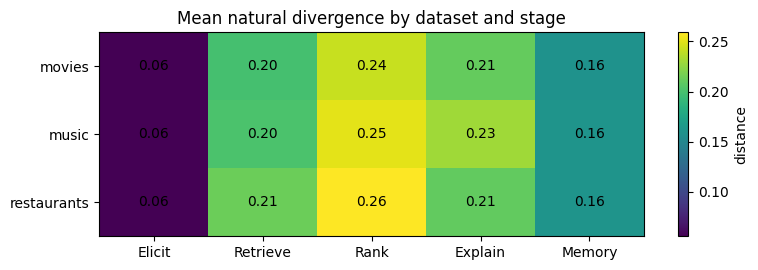

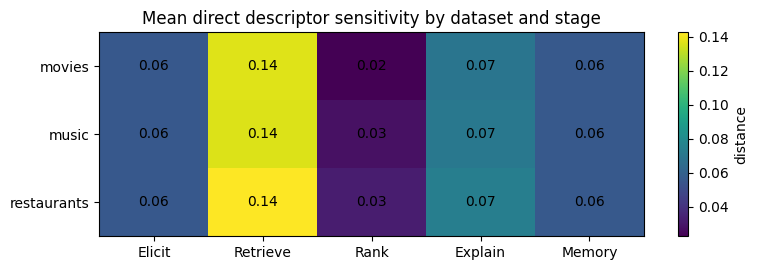

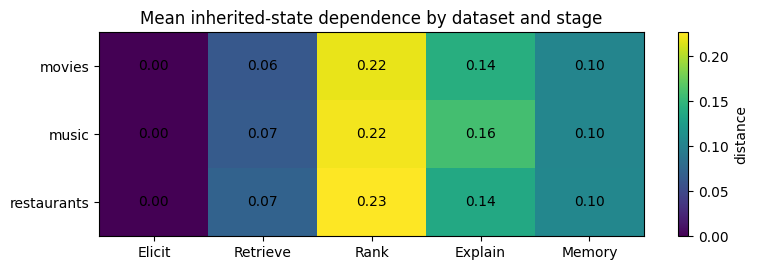

In [16]:
#@title 11B. Heatmaps for the three causal objects
for quantity, title in [
    ("natural", "Mean natural divergence by dataset and stage"),
    ("direct", "Mean direct descriptor sensitivity by dataset and stage"),
    ("inherited", "Mean inherited-state dependence by dataset and stage"),
]:
    matrix = primary.groupby(["dataset", "stage"])[quantity].mean().unstack("stage").reindex(columns=STAGES)
    fig, ax = plt.subplots(figsize=(8, 2.8))
    image = ax.imshow(matrix.values, aspect="auto")
    ax.set_xticks(range(len(matrix.columns)), matrix.columns)
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center")
    fig.colorbar(image, ax=ax, label="distance")
    plt.tight_layout()
    path = OUT / f"{quantity}_heatmap.png"
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

## 12. Results: planted-stage localization

Because the toy benchmark knows where protected dependence was injected, localization accuracy can be measured directly. This is the key methodological sanity check before applying SCAFF to real agents where causal origin is unknown.

The decision rule is no longer a single fixed margin. Each stage is scored by how far its direct effect sits **above its own scenario-level rerun floor** \(\tau_s\) from section 10B, and the stage with the largest excess wins only if that excess is positive. Comparing raw direct effects across stages whose floors differ by an order of magnitude is what the fixed margin was implicitly doing.


In [ ]:
#@title 12. Localization accuracy and confusion matrix
# A scenario's score for a stage is its direct effect averaged over the repeats, so the
# stage is judged against the scenario-level floor -- the null distribution of the mean
# of N_REPEATS re-run draws -- rather than against a single fixed margin. The winner is
# the stage with the largest *excess over its own floor*, which is what makes the
# comparison across stages legitimate when the floors differ by an order of magnitude.
scenario_stage_scores = (
    primary.groupby(["dataset", "scenario_id", "planted_stage", "stage"])["direct"]
    .mean().reset_index()
)
scenario_stage_scores["tau"] = [
    tau_for(stage, dataset=dataset, level="scenario")
    for dataset, stage in zip(scenario_stage_scores["dataset"], scenario_stage_scores["stage"])
]
scenario_stage_scores["excess"] = scenario_stage_scores["direct"] - scenario_stage_scores["tau"]

predictions = []
for (dataset, scenario_id, truth), group in scenario_stage_scores.groupby(["dataset", "scenario_id", "planted_stage"]):
    ordered = group.sort_values("excess", ascending=False)
    best = ordered.iloc[0]
    prediction = best["stage"] if best["excess"] > 0 else "none"
    runner_up = float(ordered.iloc[1]["excess"]) if len(ordered) > 1 else -np.inf
    predictions.append({
        "dataset": dataset, "scenario_id": scenario_id,
        "true_stage": truth, "predicted_stage": prediction,
        "largest_direct_effect": float(best["direct"]),
        "tau_at_winner": float(best["tau"]),
        "excess_over_floor": float(best["excess"]),
        # For a planted scenario the competitor is the next-best stage; for an
        # unplanted one it is the floor itself.
        "margin": (float(best["excess"]) - runner_up) if truth != "none" else -float(best["excess"]),
    })

localization = pd.DataFrame(predictions)
localization_accuracy = (localization["true_stage"] == localization["predicted_stage"]).mean()
print(f"Localization accuracy: {localization_accuracy:.1%}")
display(localization.head(12).round(3))

# The same decision under the threshold this section used to apply, kept so the effect
# of the change is visible rather than silent.
_fixed = []
for (dataset, scenario_id, truth), group in scenario_stage_scores.groupby(["dataset", "scenario_id", "planted_stage"]):
    best = group.sort_values("direct", ascending=False).iloc[0]
    _fixed.append({
        "dataset": dataset, "scenario_id": scenario_id, "true_stage": truth,
        "predicted_stage": best["stage"] if best["direct"] > LEGACY_DIRECT_EFFECT_MARGIN else "none",
    })
localization_fixed_margin = pd.DataFrame(_fixed)
localization_accuracy_fixed_margin = (
    localization_fixed_margin["true_stage"] == localization_fixed_margin["predicted_stage"]
).mean()
print(
    f"Same rule under the old fixed margin {LEGACY_DIRECT_EFFECT_MARGIN}: "
    f"{localization_accuracy_fixed_margin:.1%} "
    f"({localization_accuracy - localization_accuracy_fixed_margin:+.1%} from the floor-based rule)."
)

labels = ["none"] + STAGES
cm = confusion_matrix(localization["true_stage"], localization["predicted_stage"], labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, values_format="d")
ax.set_title("Planted stage versus SCAFF localization")
plt.tight_layout()
plt.savefig(OUT / "localization_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

### 12A. Planted ground truth as a headline result

Of the five evaluations in the related-work comparison, only AgentFairBench plants a known
fault at all, and it reports the check in a single line. Planted ground truth is the one
place where a fairness-localization claim can be scored against a known answer rather than
against a construct, so it is reported here at full strength rather than as a single
accuracy figure: the accuracy with a Wilson interval, the chance baseline of $1/6$ (five
stages plus the unplanted control) with an exact binomial test against it, detection and
false-alarm rates separated, per-stage recall and precision, and the full confusion matrix
in both count and row-normalized form.

The row-normalized matrix is the one to read. Accuracy says only that a fault was missed;
the matrix says where the miss went — to `none`, which leaves a fault unlocated, or to a
different stage, which sends an operator to repair something that is not at fault. Those
are different failures with different costs.

Because section 12 now thresholds against each stage's own floor rather than a fixed
margin, per-stage recall is also reported under both rules. Where the two disagree, the
disagreement is concentrated at stages whose rerun noise is far from 0.10 — which is the
result, not an artifact.

In [ ]:
#@title 12A. Planted ground truth as a headline result
# Localization is the only claim in this notebook that is checked against a known
# answer, so it is reported here as a headline number with its uncertainty, its chance
# baseline, per-stage recall and precision, and the full confusion matrix -- rather than
# as a single accuracy figure. Of the five evaluations surveyed in the related-work
# deck, only AgentFairBench plants bias at all, and it reports the check in one line.

CHANCE_LABELS = ["none"] + STAGES          # five stages plus the unplanted control
CHANCE_ACCURACY = 1.0 / len(CHANCE_LABELS)  # 1/6


def exact_binomial_tail(successes, trials, p_null):
    """One-sided P(X >= successes) under Binomial(trials, p_null), no SciPy required."""
    if not trials:
        return np.nan
    return float(sum(
        math.comb(trials, i) * (p_null ** i) * ((1 - p_null) ** (trials - i))
        for i in range(int(successes), int(trials) + 1)
    ))


_correct = localization["true_stage"] == localization["predicted_stage"]
_hits, _total = int(_correct.sum()), int(len(localization))
_acc_lo, _acc_hi = wilson_interval(_hits, _total)
_p_value = exact_binomial_tail(_hits, _total, CHANCE_ACCURACY)

print("Planted-stage localization")
print(f"  accuracy           {_hits}/{_total} = {_hits / _total:.1%}  (95% CI {_acc_lo:.1%}-{_acc_hi:.1%})")
print(f"  chance baseline    1/{len(CHANCE_LABELS)} = {CHANCE_ACCURACY:.1%}")
print(f"  lift over chance   {(_hits / _total) / CHANCE_ACCURACY:.2f}x")
print(f"  one-sided binomial p vs chance  {_p_value:.3g}")

# Detection and false-alarm behaviour separated. Accuracy pools them, and the two have
# different consequences for an auditor: a miss leaves a fault unlocated, a false alarm
# sends an operator to repair a stage that is not at fault.
_planted = localization[localization["true_stage"] != "none"]
_unplanted = localization[localization["true_stage"] == "none"]
_detected = int((_planted["predicted_stage"] != "none").sum())
_correctly_placed = int((_planted["true_stage"] == _planted["predicted_stage"]).sum())
_false_alarms = int((_unplanted["predicted_stage"] != "none").sum())
print("\n  planted scenarios")
print(f"    detected as planted anywhere   {_detected}/{len(_planted)}"
      f" = {(_detected / len(_planted)) if len(_planted) else float('nan'):.1%}")
print(f"    placed at the correct stage    {_correctly_placed}/{len(_planted)}"
      f" = {(_correctly_placed / len(_planted)) if len(_planted) else float('nan'):.1%}")
print("  unplanted control scenarios")
print(f"    false alarms                   {_false_alarms}/{len(_unplanted)}"
      f" = {(_false_alarms / len(_unplanted)) if len(_unplanted) else float('nan'):.1%}")

# Per-stage recall and precision. Recall answers "when the fault was planted here, did
# SCAFF find it"; precision answers "when SCAFF named this stage, was it right".
_scored = localization.assign(correct=_correct.values)
localization_recall = (
    _scored.groupby("true_stage")
    .agg(n_true=("correct", "size"), recall=("correct", "mean"))
    .reindex(CHANCE_LABELS)
)
localization_recall["recall_ci_lo"], localization_recall["recall_ci_hi"] = zip(*[
    wilson_interval(int(round(r * n)), int(n)) if np.isfinite(r) and np.isfinite(n) else (np.nan, np.nan)
    for r, n in zip(localization_recall["recall"].fillna(np.nan), localization_recall["n_true"].fillna(0))
])
localization_precision = (
    _scored.groupby("predicted_stage")
    .agg(n_predicted=("correct", "size"), precision=("correct", "mean"))
    .reindex(CHANCE_LABELS)
)
localization_by_stage = localization_recall.join(localization_precision).round(3)
print("\nPer-stage recall and precision (index is the stage):")
display(localization_by_stage)
print(f"Macro-averaged recall over the {len(CHANCE_LABELS)} classes: "
      f"{localization_recall['recall'].mean():.3f} (chance {CHANCE_ACCURACY:.3f})")

# Which stages the change of threshold actually moved. The fixed margin and the
# per-stage floor disagree exactly where a stage's own re-run noise is far from 0.10,
# so the comparison is reported per stage rather than as one accuracy delta.
_fixed_scored = localization_fixed_margin.assign(
    correct=localization_fixed_margin["true_stage"] == localization_fixed_margin["predicted_stage"]
)
localization_rule_comparison = (
    localization_recall[["n_true", "recall"]].rename(columns={"recall": "recall_per_stage_floor"})
    .join(
        _fixed_scored.groupby("true_stage")["correct"].mean().rename("recall_fixed_margin")
    )
)
localization_rule_comparison["delta"] = (
    localization_rule_comparison["recall_per_stage_floor"]
    - localization_rule_comparison["recall_fixed_margin"]
)
localization_rule_comparison = localization_rule_comparison.join(
    CELL_FLOOR[CELL_FLOOR.apply(lambda row: row["metric"] == PRIMARY_METRIC[row["stage"]], axis=1)]
    .groupby("stage")["mean_noise"].mean().rename("mean_rerun_noise")
)
print("\nPer-stage recall under the per-stage floor vs the old fixed margin:")
display(localization_rule_comparison.round(3))
print(
    "A negative delta is not a regression in the instrument. It is a detection the fixed "
    "margin was crediting at a stage whose own re-run noise is larger than that margin, "
    "which is the failure mode the instability-floor protocol exists to catch."
)

# Full confusion matrix, as counts and row-normalized. The row-normalized form is the
# one to read: it shows where a missed fault went instead of only that it was missed.
localization_confusion = pd.crosstab(
    localization["true_stage"], localization["predicted_stage"]
).reindex(index=CHANCE_LABELS, columns=CHANCE_LABELS, fill_value=0)
localization_confusion.index.name = "planted stage"
localization_confusion.columns.name = "stage named by SCAFF"
print("\nConfusion matrix, counts:")
display(localization_confusion)
localization_confusion_rownorm = localization_confusion.div(
    localization_confusion.sum(axis=1).replace(0, np.nan), axis=0
).round(3)
print("Confusion matrix, row-normalized (each row sums to 1):")
display(localization_confusion_rownorm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
image = axes[0].imshow(localization_confusion_rownorm.to_numpy(dtype=float), vmin=0, vmax=1, cmap="Blues")
axes[0].set_xticks(range(len(CHANCE_LABELS)), CHANCE_LABELS, rotation=45, ha="right")
axes[0].set_yticks(range(len(CHANCE_LABELS)), CHANCE_LABELS)
axes[0].set_xlabel("stage named by SCAFF")
axes[0].set_ylabel("planted stage")
axes[0].set_title("Row-normalized confusion matrix")
for i in range(len(CHANCE_LABELS)):
    for j in range(len(CHANCE_LABELS)):
        value = localization_confusion_rownorm.iloc[i, j]
        if np.isfinite(value):
            axes[0].text(j, i, f"{value:.2f}", ha="center", va="center",
                         color="white" if value > 0.5 else "black", fontsize=8)
fig.colorbar(image, ax=axes[0], label="share of that planted stage")

_bars = localization_recall["recall"].fillna(0)
axes[1].bar(range(len(_bars)), _bars.to_numpy(), color="#4C72B0")
axes[1].axhline(CHANCE_ACCURACY, linestyle="--", color="firebrick", label=f"chance = 1/{len(CHANCE_LABELS)}")
axes[1].set_xticks(range(len(_bars)), list(_bars.index), rotation=45, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("recall")
axes[1].set_title("Per-stage recall against chance")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT / "localization_headline.png", dpi=160, bbox_inches="tight")
plt.show()

LOCALIZATION_HEADLINE = {
    "n_scenarios": _total,
    "accuracy": float(_hits / _total) if _total else np.nan,
    "accuracy_ci": [float(_acc_lo), float(_acc_hi)],
    "chance_accuracy": float(CHANCE_ACCURACY),
    "lift_over_chance": float((_hits / _total) / CHANCE_ACCURACY) if _total else np.nan,
    "binomial_p_vs_chance": float(_p_value),
    "accuracy_fixed_margin_rule": float(localization_accuracy_fixed_margin),
    "detection_rate_on_planted": float(_detected / len(_planted)) if len(_planted) else np.nan,
    "correct_placement_on_planted": float(_correctly_placed / len(_planted)) if len(_planted) else np.nan,
    "false_alarm_rate_on_unplanted": float(_false_alarms / len(_unplanted)) if len(_unplanted) else np.nan,
    "macro_recall": float(localization_recall["recall"].mean()),
    "recall_by_stage": {
        str(k): (float(v) if np.isfinite(v) else None)
        for k, v in localization_recall["recall"].items()
    },
}

## 12B. Music as a held-out generalization check

Section 12 pools the three domains. The instrument's claim, however, is that stage-wise localization is a property of
the *pipeline structure*, not of a particular item vocabulary. The cell below therefore breaks the same localization
result down by dataset and reports music beside the two domains the design was written against. Comparable accuracy and
a comparable direct/inherited profile on music is the evidence that the estimator transfers; a visible drop would
localize the problem to something the movie and restaurant catalogs happened to supply.

Accuracy is a saturating statistic, so it is reported together with the **decision margin**: for a planted scenario,
how far the winning stage's direct effect sits above the next-best stage, and for an unplanted scenario, how far the
largest direct effect sits below the decision threshold. Equal accuracy with a much thinner margin on music would
mean the estimator is transferring only barely.


In [ ]:
#@title 12B. Per-dataset localization and stage profile
per_dataset = (
    localization.assign(correct=localization["true_stage"] == localization["predicted_stage"])
    .groupby("dataset")
    .agg(scenarios=("correct", "size"), localization_accuracy=("correct", "mean"))
    .round(3)
)
display(per_dataset)

# Accuracy restricted to the scenarios that actually carry a planted fault.
planted_only = localization[localization["true_stage"] != "none"]
per_dataset_planted = (
    planted_only.assign(correct=planted_only["true_stage"] == planted_only["predicted_stage"])
    .groupby("dataset")["correct"].mean().round(3).rename("accuracy_on_planted_scenarios")
)
display(per_dataset_planted)

# Mean primary coordinates per dataset and stage, restricted to scenarios whose
# planted stage is the stage being measured. This is the signal the localizer uses.
on_target = primary[primary["planted_stage"] == primary["stage"]]
signal = on_target.groupby(["dataset", "stage"])[["direct", "inherited", "noise"]].mean().round(3)
display(signal)

# Accuracy alone saturates, so it cannot distinguish a decision that was made
# confidently from one that barely cleared the threshold. The separation margin
# below is the graded version of the same check.
# The margin is now measured in excess over each stage's own rerun floor, which is
# what section 12 decides on, so it is taken straight from the localization frame
# rather than recomputed against a fixed threshold. For a planted scenario the
# competitor is the next-best stage; for an unplanted one it is the floor itself.
margins = localization[
    ["dataset", "scenario_id", "true_stage", "largest_direct_effect", "tau_at_winner",
     "excess_over_floor", "margin"]
].rename(columns={"largest_direct_effect": "top_direct"})

margin_summary = (
    margins.assign(kind=np.where(margins["true_stage"] == "none", "unplanted headroom", "planted separation"))
    .groupby(["dataset", "kind"])["margin"].mean().unstack("kind").round(3)
)
display(margin_summary)
print("Minimum planted separation margin per dataset (worst-case scenario):")
display(
    margins[margins["true_stage"] != "none"]
    .groupby("dataset")["margin"].min().round(3).rename("min_margin")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#4C72B0", "#DD8452", "#55A868"][: len(per_dataset)]
per_dataset["localization_accuracy"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].axhline(localization_accuracy, linestyle="--", color="black", label="pooled accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("localization accuracy")
axes[0].set_title("Localization accuracy by dataset")
axes[0].set_xticklabels(per_dataset.index, rotation=0)
axes[0].legend()

margin_summary.plot(kind="bar", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("mean margin")
axes[1].set_title("Decision margin by dataset (higher is more separated)")
axes[1].set_xticklabels(margin_summary.index, rotation=0)

if "music" in DATASETS and len(DATASETS) > 1:
    fig.suptitle("Music is the held-out domain", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "localization_by_dataset.png", dpi=160, bbox_inches="tight")
plt.show()

if "music" in DATASETS and len(DATASETS) > 1:
    music_accuracy = float(per_dataset.loc["music", "localization_accuracy"])
    other_accuracy = float(per_dataset.drop(index="music")["localization_accuracy"].mean())
    print(f"Music localization accuracy: {music_accuracy:.1%}")
    print(f"Mean accuracy on the other selected domains: {other_accuracy:.1%}")
    print(f"Gap (music - others): {music_accuracy - other_accuracy:+.1%}")
else:
    print("Held-out comparison skipped: RUN_DATASETS does not pair music with another domain.")


## 13. Results: sensitivity versus reference-dependent consequence

The following table reports quality and burden separately from direct sensitivity. Signed descriptor gaps are descriptive because the planted target alternates across scenarios.

descriptor                                man  woman  signed_gap_a_minus_b
dataset     stage    metric                                               
movies      Elicit   burden             0.713  0.714                -0.001
                     extract_precision  0.972  0.972                 0.000
                     extract_recall     1.000  1.000                 0.000
                     question_useful    0.797  0.797                -0.001
            Explain  support_precision  0.974  0.965                 0.009
            Memory   support_precision  0.925  0.917                 0.008
            Rank     ndcg_at_k          0.723  0.715                 0.007
            Retrieve fallback           0.000  0.000                 0.000
                     recall_at_k        0.403  0.401                 0.001
music       Elicit   burden             0.711  0.711                -0.001
                     extract_precision  0.972  0.972                 0.000
                     extract_recall     1.000  1.000                 0.000
                     question_useful    0.794  0.794                -0.001
            Explain  support_precision  0.976  0.966                 0.011
            Memory   support_precision  0.925  0.918                 0.007
            Rank     ndcg_at_k          0.728  0.724                 0.004
            Retrieve fallback           0.015  0.015                 0.000
                     recall_at_k        0.402  0.409                -0.007
restaurants Elicit   burden             0.706  0.702                 0.004
                     extract_precision  0.972  0.972                 0.000
                     extract_recall     1.000  1.000                 0.000
                     question_useful    0.789  0.785                 0.004
            Explain  support_precision  0.970  0.962                 0.008
            Memory   support_precision  0.924  0.917                 0.007
            Rank     ndcg_at_k          0.678  0.685                -0.007
            Retrieve fallback           0.116  0.120                -0.004
                     recall_at_k        0.363  0.376                -0.012

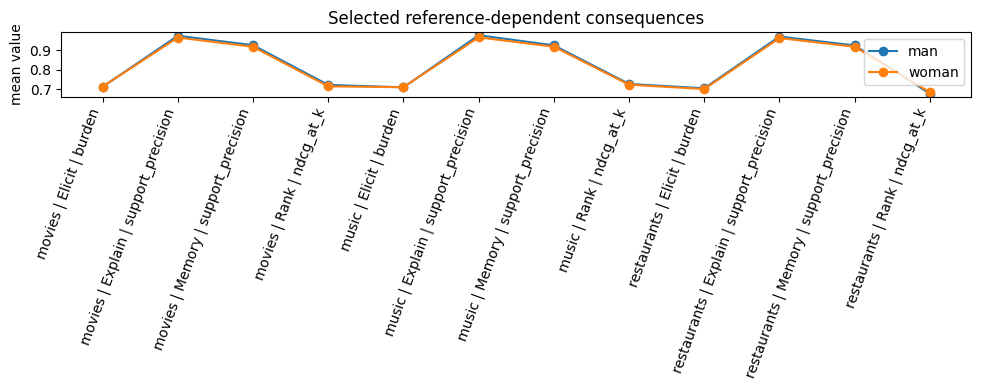

In [19]:
#@title 13. Quality, burden, and utility summaries
quality = RESULTS["quality"].copy()
quality_means = (
    quality.groupby(["dataset", "stage", "metric", "descriptor"])["value"]
    .mean().unstack("descriptor")
)
quality_means["signed_gap_a_minus_b"] = (
    quality_means.get(PROTECTED_VALUES[0], np.nan) - quality_means.get(PROTECTED_VALUES[1], np.nan)
)
display(quality_means.round(3))

selected = quality[quality["metric"].isin(["burden", "ndcg_at_k", "support_precision"])]
fig, ax = plt.subplots(figsize=(10, 4))
plot_data = selected.groupby(["dataset", "stage", "metric", "descriptor"])["value"].mean().reset_index()
plot_data["label"] = plot_data["dataset"] + " | " + plot_data["stage"] + " | " + plot_data["metric"]
for descriptor, group in plot_data.groupby("descriptor"):
    x = np.arange(len(group))
    ax.plot(x, group["value"], marker="o", label=descriptor)
ax.set_xticks(range(len(group)), group["label"], rotation=70, ha="right")
ax.set_ylabel("mean value")
ax.set_title("Selected reference-dependent consequences")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "quality_consequences.png", dpi=160, bbox_inches="tight")
plt.show()

### 13B. Sensitivity and consequence, reported separately

CFaiRLLM's objection to FaiRLLM is that measuring unfairness as a raw difference from a
reference output counts every change as unfairness, including changes that leave the user no
worse off against their real preferences; scoring against held-out true preferences instead
reports systematically less unfairness than the similarity-based measures do. The formalism
already anticipates this — direct sensitivity, procedural unfairness, and disparate harm are
three claims with three different evidential burdens, and only the third needs a reference
$\Omega_s$ — but the notebook reported quality in a separate section from $D^A$ and never
put them in the same table.

This section does. One task-truth coordinate is named per stage, all of them existing
oracles from section 7B rather than new constructs:

| stage | task-truth coordinate | what it scores |
|---|---|---|
| Elicit | `question_useful` | did the question target a genuinely unresolved facet |
| Retrieve | `recall_at_k` | share of truly relevant items reaching the candidate pool |
| Rank | `ndcg_at_k` | ranking quality against known relevance |
| Explain | `support_precision` | share of cited reasons the trace actually supports |
| Memory | `support_precision` | share of retained facts the user actually revealed |

$D^A_s$ and the quality gap appear in adjacent columns and are never combined. A stage can
be sensitive without consequence — it responds to the descriptor but does its job equally
well either way — and that is a materially different finding from a stage that is both. The
verdict column keeps the two apart, and a stage whose $D^A_s$ does not clear its own floor
gets no consequence verdict at all, because there is no established sensitivity for a
consequence to attach to.

The mechanism behind CFaiRLLM's finding is visible directly in the two columns. $D^A_s$ is a
non-negative distance, so noise accumulates in it and cannot cancel; a signed quality gap
against task truth can. That is exactly why the two have to be read as separate coordinates
rather than merged into one fairness score.

In [ ]:
#@title 13B. Quality against task truth, reported beside D^A
# CFaiRLLM's objection to FaiRLLM is that a raw difference from a reference output
# counts every change as unfairness, including changes that leave the user no worse off
# against their real preferences. The answer taken here is the one the formalism already
# prescribes: sensitivity and consequence are different claims with different evidential
# burdens, so they are reported in adjacent columns and never combined into one score.
#
#   D^A_s          reference-free. Does the stage respond to the descriptor at all.
#   quality gap    reference-dependent. Does the descriptor change how well the stage
#                  does its job, scored against this substrate's exact task truth.
#
# One task-truth coordinate is named per stage. Each is an existing oracle metric from
# section 7B, not a new construct, and each is a "higher is better" score in [0, 1].
TASK_TRUTH_METRIC = {
    "Elicit": "question_useful",     # did the question target a genuinely unresolved facet
    "Retrieve": "recall_at_k",       # share of truly relevant items reaching the candidate pool
    "Rank": "ndcg_at_k",             # ranking quality against known relevance
    "Explain": "support_precision",  # share of cited reasons the trace actually supports
    "Memory": "support_precision",   # share of retained facts the user actually revealed
}

quality = RESULTS["quality"].copy()
_task_truth = quality[quality.apply(
    lambda row: row["metric"] == TASK_TRUTH_METRIC[row["stage"]], axis=1
)]
_paired_quality = _task_truth.pivot_table(
    index=["dataset", "scenario_id", "repeat", "stage"],
    columns="descriptor", values="value",
).dropna()
_present = [value for value in PROTECTED_VALUES if value in _paired_quality.columns]
assert len(_present) == 2, f"expected both protected values in the quality frame, found {_present}"
_value_a, _value_b = _present
_paired_quality["gap"] = _paired_quality[_value_a] - _paired_quality[_value_b]

_direct_mean = primary.groupby(["dataset", "stage"])["direct"].mean()
_direct_cells = primary.groupby(["dataset", "stage"]).size()

_rows = []
for (dataset, stage), group in _paired_quality.groupby(level=["dataset", "stage"]):
    low, high = bootstrap_mean_ci(group["gap"], seed=stable_int(dataset, stage, "quality") % (2 ** 31))
    n_cells = int(_direct_cells.get((dataset, stage), 0))
    tau = tau_for(stage, dataset=dataset, level="corpus", n_cells=n_cells or 1)
    direct = float(_direct_mean.get((dataset, stage), np.nan))
    sensitive = bool(np.isfinite(direct) and direct > tau)
    consequential = bool(np.isfinite(low) and np.isfinite(high) and not (low <= 0 <= high))
    if not sensitive:
        verdict = "not sensitive above its own floor"
    elif consequential:
        verdict = "sensitive AND a quality consequence against task truth"
    else:
        verdict = "sensitive, no quality consequence detected"
    _rows.append({
        "dataset": dataset, "stage": stage,
        "task_truth_metric": TASK_TRUTH_METRIC[stage],
        "D_A": round(direct, 3), "tau": round(tau, 3),
        "sensitive_above_floor": sensitive,
        f"quality_{_value_a}": round(float(group[_value_a].mean()), 3),
        f"quality_{_value_b}": round(float(group[_value_b].mean()), 3),
        "quality_gap": round(float(group["gap"].mean()), 3),
        "gap_ci_lo": round(low, 3) if np.isfinite(low) else np.nan,
        "gap_ci_hi": round(high, 3) if np.isfinite(high) else np.nan,
        "consequence_detected": consequential,
        # Mean of the per-cell absolute gap. Retained because it is the quantity a
        # distance-style summary would report, and it is inflated by cell-level noise
        # in exactly the way D^A is; the signed mean above is the unbiased one.
        "mean_abs_cell_gap": round(float(group["gap"].abs().mean()), 3),
        "verdict": verdict,
    })
consequence = pd.DataFrame(_rows).sort_values(["dataset", "stage"]).reset_index(drop=True)
print("Sensitivity and consequence, side by side. These are not combined into one score.")
display(consequence)

print("\nCounts by verdict:")
display(consequence["verdict"].value_counts().rename("stages").to_frame())

# The CFaiRLLM comparison, stated on the common [0, 1] scale the two coordinates share.
# D^A is a non-negative distance, so noise accumulates in it; a signed quality gap
# against task truth cancels. That asymmetry is the mechanism behind CFaiRLLM's finding
# that similarity-based measures report more unfairness than truth-based ones, and it is
# why the two must be read as separate coordinates rather than as one number.
_mean_direct = float(consequence["D_A"].mean())
_mean_signed = float(consequence["quality_gap"].abs().mean())
_mean_abs_cell = float(consequence["mean_abs_cell_gap"].mean())
SENSITIVITY_VS_CONSEQUENCE = {
    "mean_D_A": _mean_direct,
    "mean_abs_signed_quality_gap": _mean_signed,
    "mean_abs_cell_quality_gap": _mean_abs_cell,
    "overstatement_ratio": (_mean_direct / _mean_signed) if _mean_signed else np.nan,
    "stages_sensitive_above_floor": int(consequence["sensitive_above_floor"].sum()),
    "stages_with_quality_consequence": int(consequence["consequence_detected"].sum()),
    "n_stage_cells": int(len(consequence)),
}
print(
    f"\nMean D^A across (dataset, stage) cells: {_mean_direct:.3f}"
    f"\nMean |signed quality gap| against task truth: {_mean_signed:.3f}"
    f"\nRatio: {SENSITIVITY_VS_CONSEQUENCE['overstatement_ratio']:.2f}x"
)
print(
    f"{SENSITIVITY_VS_CONSEQUENCE['stages_sensitive_above_floor']} of "
    f"{SENSITIVITY_VS_CONSEQUENCE['n_stage_cells']} stage cells are sensitive above their own "
    f"floor, and {SENSITIVITY_VS_CONSEQUENCE['stages_with_quality_consequence']} of those show a "
    "quality gap whose bootstrap interval excludes zero."
)
print(
    "Where no defensible reference exists for a stage, the correct entry is 'harm not "
    "identified' rather than a judge-supplied number; every stage in this substrate has "
    "an exact oracle, which is the reason the substrate is controlled."
)

fig, ax = plt.subplots(figsize=(10, 4))
_labels = consequence["dataset"] + " | " + consequence["stage"]
_x = np.arange(len(consequence))
ax.bar(_x - 0.2, consequence["D_A"], width=0.4, label="$D^A$ (sensitivity, reference-free)")
ax.bar(_x + 0.2, consequence["quality_gap"].abs(), width=0.4,
       label="|quality gap| vs task truth (consequence)")
ax.plot(_x - 0.2, consequence["tau"], linestyle="none", marker="_", markersize=14,
        color="firebrick", label=r"per-stage floor $\tau_s$")
ax.set_xticks(_x, _labels, rotation=70, ha="right")
ax.set_ylabel("value on the shared [0, 1] scale")
ax.set_title("Sensitivity and consequence are reported separately, not merged")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "sensitivity_vs_consequence.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Results: endpoint–process disagreement

A process-sensitive case is **masked** when at least one stage has a direct effect above the threshold but the final ranking remains within the endpoint-equivalence margin.

Since section 10B, `process_sensitive` is taken against each stage's own cell-level rerun floor rather than the fixed margin; the audit-time value computed with the fixed margin is retained in `pairs['process_sensitive_fixed_margin']` for comparison.

In [ ]:
#@title 14. Endpoint versus process summary
pairs = RESULTS["pairs"].copy()
endpoint_summary = pairs.groupby("dataset")[[
    "process_sensitive", "endpoint_different", "masked", "followup_top_gap"
]].mean().round(3)
display(endpoint_summary)

contingency = pd.crosstab(
    pairs["process_sensitive"].map({True: "process sensitive", False: "no direct process sensitivity"}),
    pairs["endpoint_different"].map({True: "endpoint different", False: "endpoint equivalent"}),
)
display(contingency)

fig, ax = plt.subplots(figsize=(7, 4))
endpoint_summary[["process_sensitive", "endpoint_different", "masked"]].plot(kind="bar", ax=ax)
ax.set_ylabel("proportion of repeated scenario pairs")
ax.set_title("Process sensitivity, endpoint difference, and masking")
ax.set_xticklabels(endpoint_summary.index, rotation=0)
plt.tight_layout()
plt.savefig(OUT / "endpoint_process_disagreement.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Results: repair removability

A repair replaces the protected-condition stage output with the valid counterpart output and reruns descendants.
Equation (10) indexes removability by **both** the repaired node $j$ and the outcome node $r$,

$$
R_{j \to r} = D_r^{\mathrm{nat}} - D_r^{\mathrm{rep}(j)},
$$

and $r$ must be strictly downstream of $j$. The table below is therefore a matrix over $(j, r)$ rather than a single
column, with the cells where $r$ is not downstream of $j$ left empty.

Two degeneracies this avoids. Scoring a repair on the repaired node itself measures the substitution and not the
repair: replacing the ranked list and then scoring the ranked list returns the pre-repair divergence exactly, whatever
the repair did. The same trap appears one step out whenever $r$ is a deterministic function of $j$ alone. In this
substrate the follow-up turn is computed from `Memory` and nothing else, so the cell $(j=\texttt{Memory},
r=\texttt{Followup})$ is degenerate in the same way; it is flagged rather than reported as a repair effect. Closing it
would require a follow-up turn that reads something besides memory, which is a substrate change; Section 15B
makes that change.

Reading the matrix down a column compares repairs at different nodes on a common outcome, which is the comparison RQ4
asks for.

Mean removability R(j -> r), pooled over datasets.
Rows: repaired node j. Columns: outcome node r. Empty cells are not downstream.


outcome_node,Retrieve,Rank,Explain,Memory,Followup
repair_stage,,,,,
Elicit,0.066,0.086,0.077,0.056,0.085
Retrieve,NaN,0.193,0.022,0.000,0.000
Rank,NaN,NaN,0.098,0.000,0.000
Memory,NaN,NaN,NaN,NaN,0.257


Same matrix as a fraction of the pre-repair divergence at that outcome node:


outcome_node,Retrieve,Rank,Explain,Memory,Followup
repair_stage,,,,,
Elicit,0.322,0.343,0.361,0.349,0.331
Retrieve,NaN,0.770,0.103,0.000,0.000
Rank,NaN,NaN,0.459,0.000,0.000
Memory,NaN,NaN,NaN,NaN,1.001


Flagged as degenerate and excluded from the comparisons below: 5400 rows, all (Memory -> Followup).
Check passed: no usable (j, r) cell is saturated at its own pre-repair divergence.
RQ4, compared within each outcome node:


,exonerated-stage repair,planted-stage repair,gap
outcome_node,,,
Retrieve,0.000,0.398,0.398
Rank,0.034,0.669,0.635
Explain,0.022,0.287,0.265
Memory,0.000,0.112,0.112
Followup,0.000,0.169,0.169


exonerated-stage repair  planted-stage repair
dataset     outcome_node                                               
movies      Explain                         0.021                 0.279
            Followup                        0.000                 0.169
            Memory                          0.000                 0.111
            Rank                            0.032                 0.657
            Retrieve                        0.000                 0.375
music       Explain                         0.025                 0.313
            Followup                        0.000                 0.175
            Memory                          0.000                 0.112
            Rank                            0.035                 0.668
            Retrieve                        0.000                 0.393
restaurants Explain                         0.019                 0.268
            Followup                        0.000                 0.163
            Memory                          0.000                 0.112
            Rank                            0.034                 0.680
            Retrieve                        0.000                 0.426

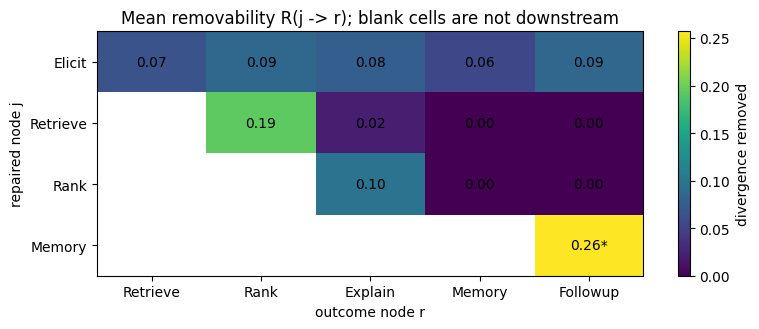

* degenerate: the follow-up turn is a deterministic function of Memory.


In [21]:
#@title 15. Repair summaries
repair = RESULTS["repair"].copy()

OUTCOME_ORDER = ["Retrieve", "Rank", "Explain", "Memory", "Followup"]
REPAIR_ORDER = ["Elicit", "Retrieve", "Rank", "Memory"]

removability_matrix = (
    repair.groupby(["repair_stage", "outcome_node"])["removability"].mean()
    .unstack("outcome_node").reindex(index=REPAIR_ORDER, columns=OUTCOME_ORDER).round(3)
)
print("Mean removability R(j -> r), pooled over datasets.")
print("Rows: repaired node j. Columns: outcome node r. Empty cells are not downstream.")
display(removability_matrix)

print("Same matrix as a fraction of the pre-repair divergence at that outcome node:")
before_matrix = (
    repair.groupby(["repair_stage", "outcome_node"])["before"].mean()
    .unstack("outcome_node").reindex(index=REPAIR_ORDER, columns=OUTCOME_ORDER)
)
display((removability_matrix / before_matrix).round(3))

degenerate = repair[repair["degenerate"]]
print(
    f"Flagged as degenerate and excluded from the comparisons below: "
    f"{len(degenerate)} rows, all (Memory -> Followup)."
)
usable = repair[~repair["degenerate"]]

# Guard against the artifact the design is meant to avoid: no usable cell may
# have its removability equal to its own pre-repair divergence by construction.
saturated = (
    usable.groupby(["repair_stage", "outcome_node"])[["before", "removability"]].mean()
)
bad = saturated[np.isclose(saturated["before"], saturated["removability"])]
assert bad.empty, f"outcome node is not strictly downstream of the repair:\n{bad}"
print("Check passed: no usable (j, r) cell is saturated at its own pre-repair divergence.")

# RQ4: does repairing the implicated stage remove more than repairing an
# exonerated one? Compared within an outcome node, never across.
truth = usable.assign(is_true_stage=usable["repair_stage"] == usable["planted_stage"])
rq4 = (
    truth.groupby(["outcome_node", "is_true_stage"])["removability"].mean()
    .unstack().reindex(OUTCOME_ORDER).dropna(how="all")
)
rq4.columns = ["exonerated-stage repair", "planted-stage repair"]
rq4["gap"] = rq4["planted-stage repair"] - rq4["exonerated-stage repair"]
print("RQ4, compared within each outcome node:")
display(rq4.round(3))

rq4_by_dataset = (
    truth.groupby(["dataset", "outcome_node", "is_true_stage"])["removability"].mean()
    .unstack().dropna(how="all")
)
rq4_by_dataset.columns = ["exonerated-stage repair", "planted-stage repair"]
display(rq4_by_dataset.round(3))

fig, ax = plt.subplots(figsize=(8, 3.4))
values = removability_matrix.values.astype(float)
image = ax.imshow(np.ma.masked_invalid(values), aspect="auto", vmin=0)
ax.set_xticks(range(len(OUTCOME_ORDER)), OUTCOME_ORDER)
ax.set_yticks(range(len(REPAIR_ORDER)), REPAIR_ORDER)
ax.set_xlabel("outcome node r")
ax.set_ylabel("repaired node j")
ax.set_title("Mean removability R(j -> r); blank cells are not downstream")
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        if not np.isnan(values[i, j]):
            label = f"{values[i, j]:.2f}"
            if REPAIR_ORDER[i] == "Memory" and OUTCOME_ORDER[j] == "Followup":
                label += "*"
            ax.text(j, i, label, ha="center", va="center")
fig.colorbar(image, ax=ax, label="divergence removed")
plt.tight_layout()
plt.savefig(OUT / "repair_removability.png", dpi=160, bbox_inches="tight")
plt.show()
print("* degenerate: the follow-up turn is a deterministic function of Memory.")

repair_summary = removability_matrix

## 15B. Multi-turn conversations

Sections 9–15 audit one turn plus a scripted follow-up that reads `Memory` and nothing else. Real conversational
recommenders do not work that way. Each later turn is conditioned on the whole conversation so far: what the user said
back, what the agent asked, what it already recommended, and what it wrote to memory. This section runs the five
stages once per turn for `N_TURNS` turns and applies SCAFF to every turn-indexed node $(t, s)$.

**Conversation substrate.** Turn 1 is exactly the single-turn pipeline above: same parent states, same seeds. From
turn 2 on, a **simulated user** replies to what the agent showed on the previous turn. It reads only non-protected
content and never sees the descriptor. The user:

1. answers the previous clarification question with their true value for that facet;
2. corrects any claim in the previous explanation that contradicts their true preferences;
3. says they already have the previously recommended item and asks for another option.

The agent's parent state at $(t, s)$ therefore includes the conversation history $H_t$ (user replies, questions asked,
items already shown) and the previous turn's memory $M_{t-1}$. At turn $t \ge 2$, Elicit starts from the facts in
$M_{t-1}$ and applies the user's reply on top. Retrieve excludes items already shown. Memory keeps the provenance of
facts it carries over.

**Turn-indexed crossover.** With $Z_{t,s}^{i}$ the complete non-protected parent state reached at node $(t,s)$ under
condition $i$,

$$
Y_{t,s}^{i,j} = \phi_s(f_s(Z_{t,s}^i, A=j; \epsilon)),
$$

and $D_{t,s}^{\mathrm{nat}}$, $D_{t,s}^{A}$, $D_{t,s}^{Z}$ are defined exactly as in Section 3, node by node.

**What this tests.** Each scenario's fault is planted at a single node $(t^\*, s^\*)$ (`planted_turn`, `planted_stage`).
The fault fires only on its planted turn. A correct instrument should therefore:

- **localize across turns:** the largest direct effect sits at $(t^\*, s^\*)$, not merely at stage $s^\*$ of some turn;
- **attribute carry-over to inherited state:** nodes at turns $t > t^\*$ may diverge naturally, but only through
  $Z_{t,s}$ (memory, user replies, the exclusion list). $D^A$ there should be near zero and $D^Z$ should carry the
  divergence;
- **show turn-1 repairs reaching later turns:** repairing a turn-1 node and rerunning the rest of the conversation,
  including the simulated user's replies, should remove later-turn divergence when the fault was planted at that
  node, and remove nothing when the fault was planted on a later turn.

This also closes the degeneracy flagged in Section 15. A turn-2 node reads the user's reply and the exclusion list as
well as memory, so $(j=\text{T1:Memory}, r=\text{T2:}s)$ is a real repair effect, not a substitution.

It also separates two kinds of contamination that a single turn cannot tell apart. A fact the agent **surfaces** in an
explanation is corrected by the user on the next turn. A fact the agent writes **silently** to memory is carried into
the next turn's preferences. It is corrected only once it surfaces in a later explanation, or once a clarification
question happens to cover that facet.


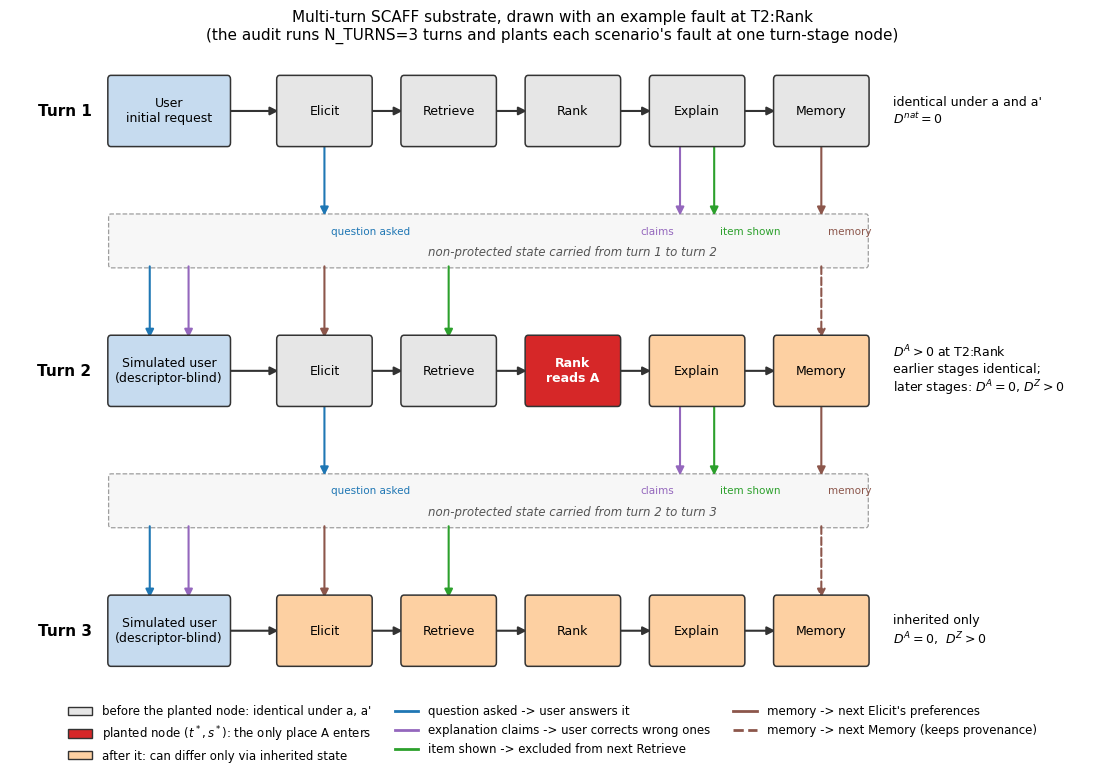

In [22]:
#@title 15B-0. Structure of a multi-turn conversation (schematic)
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch
from matplotlib.lines import Line2D


def draw_multiturn_structure(n_turns=3, planted=(2, "Rank")):
    """Schematic of the conversation substrate: what flows within a turn, what is carried
    to the next turn, and where SCAFF expects direct versus inherited divergence for one
    example fault. It draws the design, not results."""
    planted_turn, planted_stage = planted
    xs = {"User": 0.0, **{stage: 2.0 + 1.6 * i for i, stage in enumerate(STAGES)}}
    widths = {"User": 1.5}
    row_gap, box_h, band_h = 2.7, 0.66, 0.5
    y_of = lambda turn: -(turn - 1) * row_gap
    width = lambda name: widths.get(name, 1.15)

    fill = {"before": "#e6e6e6", "planted": "#d62728", "after": "#fdd0a2", "user": "#c6dbef"}
    channel = {"answer": "#1f77b4", "correct": "#9467bd", "exclude": "#2ca02c", "memory": "#8c564b"}

    def status(turn, stage):
        order = (turn, STAGES.index(stage))
        target = (planted_turn, STAGES.index(planted_stage))
        return "before" if order < target else "planted" if order == target else "after"

    fig, ax = plt.subplots(figsize=(14, 0.9 + 2.5 * n_turns))

    def box(name, y, text, color, text_color="black", weight="normal"):
        w = width(name)
        ax.add_patch(FancyBboxPatch(
            (xs[name] - w / 2, y - box_h / 2), w, box_h, boxstyle="round,pad=0.04",
            facecolor=color, edgecolor="#333333", linewidth=1.1, zorder=3,
        ))
        ax.text(xs[name], y, text, ha="center", va="center", fontsize=9, color=text_color,
                fontweight=weight, zorder=4)

    def arrow(start, end, color, style="-", width_=1.5):
        ax.add_patch(FancyArrowPatch(
            start, end, arrowstyle="-|>", mutation_scale=12, color=color, linewidth=width_,
            linestyle=style, shrinkA=1, shrinkB=1, zorder=2,
        ))

    left_edge = xs["User"] - width("User") / 2
    right_edge = xs["Memory"] + width("Memory") / 2

    for turn in range(1, n_turns + 1):
        y = y_of(turn)
        ax.text(left_edge - 0.25, y, f"Turn {turn}", ha="right", va="center", fontsize=11, fontweight="bold")
        user_text = "User\ninitial request" if turn == 1 else "Simulated user\n(descriptor-blind)"
        box("User", y, user_text, fill["user"])
        for stage in STAGES:
            state = status(turn, stage)
            if state == "planted":
                box(stage, y, f"{stage}\nreads A", fill[state], "white", "bold")
            else:
                box(stage, y, stage, fill[state])

        # Within a turn: the single-turn pipeline.
        names = ["User"] + STAGES
        for a, b in zip(names, names[1:]):
            arrow((xs[a] + width(a) / 2, y), (xs[b] - width(b) / 2, y), "#333333")

        if turn == n_turns:
            continue

        # Everything turn t+1 inherits passes through one band of carried, non-protected state.
        band_y = y - row_gap / 2
        ax.add_patch(FancyBboxPatch(
            (left_edge, band_y - band_h / 2), right_edge - left_edge, band_h, boxstyle="round,pad=0.03",
            facecolor="#f7f7f7", edgecolor="#9e9e9e", linewidth=0.9, linestyle="--", zorder=1,
        ))
        ax.text(xs["Rank"], band_y - 0.12, f"non-protected state carried from turn {turn} to turn {turn + 1}",
                ha="center", va="center", fontsize=8.5, style="italic", color="#555555", zorder=4)
        nxt = y_of(turn + 1)
        out_top, band_top, band_bottom, in_top = y - box_h / 2, band_y + band_h / 2, band_y - band_h / 2, nxt + box_h / 2

        # Into the band (from turn t).
        arrow((xs["Elicit"], out_top), (xs["Elicit"], band_top), channel["answer"])
        arrow((xs["Explain"] - 0.22, out_top), (xs["Explain"] - 0.22, band_top), channel["correct"])
        arrow((xs["Explain"] + 0.22, out_top), (xs["Explain"] + 0.22, band_top), channel["exclude"])
        arrow((xs["Memory"], out_top), (xs["Memory"], band_top), channel["memory"])
        # Out of the band (into turn t+1).
        arrow((xs["User"] - 0.25, band_bottom), (xs["User"] - 0.25, in_top), channel["answer"])
        arrow((xs["User"] + 0.25, band_bottom), (xs["User"] + 0.25, in_top), channel["correct"])
        arrow((xs["Elicit"], band_bottom), (xs["Elicit"], in_top), channel["memory"])
        arrow((xs["Retrieve"], band_bottom), (xs["Retrieve"], in_top), channel["exclude"])
        arrow((xs["Memory"], band_bottom), (xs["Memory"], in_top), channel["memory"], style="--")

        # What each arrow carries, written inside the band next to it.
        for x, text, color, ha in [
            (xs["Elicit"] + 0.08, "question asked", channel["answer"], "left"),
            (xs["Explain"] - 0.3, "claims", channel["correct"], "right"),
            (xs["Explain"] + 0.3, "item shown", channel["exclude"], "left"),
            (xs["Memory"] + 0.08, "memory", channel["memory"], "left"),
        ]:
            ax.text(x, band_y + 0.1, text, ha=ha, va="center", fontsize=7.5, color=color, zorder=4)

    # Expected SCAFF reading per turn, for this example fault.
    notes_x = right_edge + 0.35
    for turn in range(1, n_turns + 1):
        y = y_of(turn)
        if turn < planted_turn:
            note = "identical under a and a'\n$D^{nat}=0$"
        elif turn == planted_turn:
            note = f"$D^A>0$ at T{turn}:{planted_stage}\nearlier stages identical;\nlater stages: $D^A=0$, $D^Z>0$"
        else:
            note = "inherited only\n$D^A=0$,  $D^Z>0$"
        ax.text(notes_x, y, note, ha="left", va="center", fontsize=9)

    handles = [
        Patch(facecolor=fill["before"], edgecolor="#333333", label="before the planted node: identical under a, a'"),
        Patch(facecolor=fill["planted"], edgecolor="#333333", label="planted node $(t^*, s^*)$: the only place A enters"),
        Patch(facecolor=fill["after"], edgecolor="#333333", label="after it: can differ only via inherited state"),
        Line2D([], [], color=channel["answer"], lw=2, label="question asked -> user answers it"),
        Line2D([], [], color=channel["correct"], lw=2, label="explanation claims -> user corrects wrong ones"),
        Line2D([], [], color=channel["exclude"], lw=2, label="item shown -> excluded from next Retrieve"),
        Line2D([], [], color=channel["memory"], lw=2, label="memory -> next Elicit's preferences"),
        Line2D([], [], color=channel["memory"], lw=2, ls="--", label="memory -> next Memory (keeps provenance)"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3, fontsize=8.5,
              frameon=False)
    ax.set_xlim(left_edge - 1.3, notes_x + 2.6)
    ax.set_ylim(y_of(n_turns) - box_h, box_h)
    ax.axis("off")
    ax.set_title(
        f"Multi-turn SCAFF substrate, drawn with an example fault at T{planted_turn}:{planted_stage}\n"
        f"(the audit runs N_TURNS={N_TURNS} turns and plants each scenario's fault at one turn-stage node)",
        fontsize=11,
    )
    return fig


fig = draw_multiturn_structure()
plt.savefig(OUT / "multiturn_structure.png", dpi=180, bbox_inches="tight")
plt.show()


In [23]:
#@title 15B-A. Multi-turn substrate: simulated user, turn-indexed parents, conversation runner
assert N_TURNS >= 2, "the multi-turn audit needs at least two turns"

MT_NODES = [(turn, stage) for turn in range(1, N_TURNS + 1) for stage in STAGES]


def node_label(turn, stage):
    return f"T{turn}:{stage}"


def planted_turn_for(dataset, scenario_id, planted_stage):
    """Turn at which a scenario's fault fires. The protected target alternates with
    k = i // 6, so the turn is keyed on k // 2 (every turn receives both targets).
    It is offset by the stage position and the dataset, so that even the reduced grid
    plants every stage at every turn somewhere across the datasets."""
    if planted_stage == "none":
        return 0
    i = int(scenario_id.rsplit("_", 1)[1])
    return 1 + ((i % 6) + (i // 6) // 2 + DATASETS.index(dataset)) % N_TURNS


MT_SCENARIOS = SCENARIOS.copy()
MT_SCENARIOS["planted_turn"] = [
    planted_turn_for(dataset, sid, stage)
    for dataset, sid, stage in zip(
        MT_SCENARIOS["dataset"], MT_SCENARIOS["scenario_id"], MT_SCENARIOS["planted_stage"]
    )
]
MT_SCENARIOS["planted_node"] = [
    "none" if stage == "none" else node_label(turn, stage)
    for turn, stage in zip(MT_SCENARIOS["planted_turn"], MT_SCENARIOS["planted_stage"])
]


def turn_view(scenario, turn):
    """The scenario as the stage functions see it at one turn. The planted fault and the
    scenario's validity fault (if any) both fire only on the planted turn, so every turn
    before it is identical across the two conditions."""
    view = dict(scenario)
    if turn != scenario["planted_turn"]:
        view["planted_stage"] = "none"
        view["validity_fault"] = None
    return view


def conversation_seed(scenario_id, repeat, turn, stage):
    # Turn 1 reuses the single-turn seeds, so it reproduces run_trajectory exactly.
    return stage_seed(scenario_id, repeat, stage, 0 if turn == 1 else turn)


def simulated_user_reply(scenario, history):
    """The user's message at turn t >= 2. It reads the true preferences and the
    non-protected content the agent showed on the previous turn, never the descriptor."""
    truth = scenario["true_preferences"]
    previous = history[-1]
    catalog = indexed_catalog(scenario["dataset"])
    revealed, parts = {}, []

    answered = previous["Elicit"]["question_target"] if previous["Elicit"]["ask"] else None
    if answered in truth:
        revealed[answered] = truth[answered]
        parts.append(f"To answer your question: {fact_str(answered, truth[answered])}.")
    else:
        answered = None

    corrected = []
    for tag in previous["Explain"]["reason_tags"]:
        key = tag.split("=", 1)[0]
        if key in truth and tag != fact_str(key, truth[key]):
            revealed[key] = truth[key]
            corrected.append(key)
            parts.append(f"Actually, not {tag}; I prefer {fact_str(key, truth[key])}.")

    rejected = previous["Explain"]["top_item"]
    if rejected in catalog.index:
        parts.append(f"I already know {catalog.loc[rejected, 'title']}; please recommend something else.")

    return {
        "text": " ".join(parts) or "Please recommend something else.",
        "revealed": revealed,
        "answered": answered,
        "corrected": sorted(set(corrected)),
        "rejected": rejected,
    }


def transcript(scenario, history):
    """Plain-text conversation so far, one line per utterance."""
    lines = []
    for index, past in enumerate(history):
        lines.append("user: " + (scenario["message"] if index == 0 else past["User"]["text"]))
        if past["Elicit"]["question_text"]:
            lines.append("agent: " + past["Elicit"]["question_text"])
        lines.append("agent: " + past["Explain"]["text"])
    return lines


def conversation_parent(stage, scenario, turn, current, history):
    """Complete non-protected parent state at node (turn, stage). Turn 1 is exactly the
    single-turn parent; later turns add the user's reply, the transcript, the previous
    turn's memory, and the items already shown."""
    if turn == 1:
        return stage_parent(stage, scenario, current)

    prior_memory = history[-1]["Memory"]["facts"]
    reply = current["User"]

    if stage == "Elicit":
        preferences = facts_to_dict([row["fact"] for row in prior_memory])
        preferences.update(reply["revealed"])
        return {
            "message": reply["text"],
            "revealed_preferences": preferences,
            "unresolved_facets": [key for key in scenario["true_preferences"] if key not in preferences],
            "history": transcript(scenario, history),
            "prior_memory": prior_memory,
        }

    parent = stage_parent(stage, scenario, current)
    if stage == "Retrieve":
        parent["history"] = transcript(scenario, history) + ["user: " + reply["text"]]
        parent["memory"] = prior_memory
        parent["exclude_ids"] = [past["Explain"]["top_item"] for past in history]
    elif stage == "Memory":
        parent["prior_memory"] = prior_memory
    return parent


def run_conversation(scenario, descriptor, repeat, override=None):
    """Run N_TURNS turns under one descriptor. override=(turn, stage, output) splices that
    output in at that node and reruns everything downstream of it, including the
    simulated user's later replies. Every node has its own seed, so the nodes upstream
    of the splice reproduce the unrepaired conversation exactly."""
    history = []
    for turn in range(1, N_TURNS + 1):
        view = turn_view(scenario, turn)
        current = {} if turn == 1 else {"User": simulated_user_reply(scenario, history)}
        for stage in STAGES:
            if override is not None and override[:2] == (turn, stage):
                current[stage] = deepcopy(override[2])
                continue
            parent = conversation_parent(stage, scenario, turn, current, history)
            current[stage] = run_stage(
                stage, view, parent, descriptor,
                conversation_seed(scenario["scenario_id"], repeat, turn, stage),
            )
        history.append(current)
    return history


print(f"Multi-turn substrate ready: {N_TURNS} turns, {len(MT_NODES)} audited nodes per conversation.")
print("Planted faults by turn and stage:")
display(
    MT_SCENARIOS[MT_SCENARIOS["planted_stage"] != "none"]
    .groupby(["planted_turn", "planted_stage"]).size().unstack(fill_value=0).reindex(columns=STAGES)
)


Multi-turn substrate ready: 3 turns, 15 audited nodes per conversation.
Planted faults by turn and stage:


planted_stage,Elicit,Retrieve,Rank,Explain,Memory
planted_turn,,,,,
1,10,10,10,10,10
2,10,10,10,10,10
3,10,10,10,10,10


In [24]:
#@title 15B-B. Substrate checks and one example conversation

def _same(left, right):
    return json.dumps(left, sort_keys=True, default=str) == json.dumps(right, sort_keys=True, default=str)


CHECK_REPEATS = min(N_REPEATS, 3)
turn1_mismatches, unplanted_leaks, early_leaks = [], [], []
for _, row in MT_SCENARIOS.iterrows():
    scenario = row.to_dict()
    for repeat in range(CHECK_REPEATS):
        conversations = {}
        for descriptor in PROTECTED_VALUES:
            # 1. With the fault moved to turn 1, turn 1 is the single-turn trajectory.
            single = run_trajectory(scenario, descriptor, repeat)
            first = run_conversation({**scenario, "planted_turn": 1}, descriptor, repeat)[0]
            if not all(_same(single[stage], first[stage]) for stage in STAGES):
                turn1_mismatches.append((scenario["scenario_id"], descriptor, repeat))
            conversations[descriptor] = run_conversation(scenario, descriptor, repeat)

        conv_a, conv_b = (conversations[value] for value in PROTECTED_VALUES)
        # 2. Without a planted fault the descriptor cannot reach any node, on any turn:
        #    neither the simulated user nor the carried-over state leaks it.
        if scenario["planted_stage"] == "none" and not _same(conv_a, conv_b):
            unplanted_leaks.append((scenario["scenario_id"], repeat))
        # 3. Every turn before the planted turn is identical across the two conditions.
        if scenario["planted_turn"] > 1 and not _same(
            conv_a[: scenario["planted_turn"] - 1], conv_b[: scenario["planted_turn"] - 1]
        ):
            early_leaks.append((scenario["scenario_id"], repeat))

assert not turn1_mismatches, f"turn 1 differs from the single-turn trajectory: {turn1_mismatches[:5]}"
assert not unplanted_leaks, f"descriptor reached an unplanted conversation: {unplanted_leaks[:5]}"
assert not early_leaks, f"conditions differ before the planted turn: {early_leaks[:5]}"
print(f"Checks passed on {len(MT_SCENARIOS)} scenarios x {CHECK_REPEATS} repeats:")
print(" - turn 1 of every conversation reproduces the single-turn trajectory exactly;")
print(" - unplanted conversations are identical under both descriptors at every turn;")
print(" - conversations are identical under both descriptors before the planted turn.")

# One Memory-fault conversation, under both descriptors. The fact is written to memory
# silently: it never appears in that turn's explanation, so the user cannot correct it
# until it surfaces later or a clarification question happens to cover that facet. The
# example is the first one (earliest planted turn) in which the fact survives into the
# next turn; how often that happens is in the persistence table of Section 15B-E.
def _carried(scenario):
    turn = scenario["planted_turn"]
    if turn >= N_TURNS:
        return False
    conversation = run_conversation(scenario, scenario["planted_target"], 0)
    fact = fact_str(scenario["bias_fact_key"], scenario["bias_fact_value"])
    return fact in {r["fact"] for r in conversation[turn]["Memory"]["facts"]}


memory_faults = [
    row.to_dict() for _, row in MT_SCENARIOS[MT_SCENARIOS["planted_stage"] == "Memory"]
    .sort_values("planted_turn", kind="stable").iterrows()
]
example = next((s for s in memory_faults if _carried(s)), memory_faults[0])
bias = fact_str(example["bias_fact_key"], example["bias_fact_value"])
print(f"\nExample {example['scenario_id']} ({example['planted_node']} fault targeting "
      f"'{example['planted_target']}', planted fact {bias}):")
rows = []
for descriptor in PROTECTED_VALUES:
    for turn, current in enumerate(run_conversation(example, descriptor, 0), start=1):
        rows.append({
            "descriptor": descriptor, "turn": turn,
            "user": example["message"] if turn == 1 else current["User"]["text"],
            "agent question": current["Elicit"]["question_text"],
            "top item": current["Explain"]["top_item"],
            "explanation": current["Explain"]["text"],
            "planted fact in memory": bias in {r["fact"] for r in current["Memory"]["facts"]},
        })
display(pd.DataFrame(rows))


Checks passed on 180 scenarios x 3 repeats:
 - turn 1 of every conversation reproduces the single-turn trajectory exactly;
 - unplanted conversations are identical under both descriptors at every turn;
 - conversations are identical under both descriptors before the planted turn.

Example mov_053 (T1:Memory fault targeting 'man', planted fact tone=romantic):


,descriptor,turn,user,agent question,top item,explanation,planted fact in memory
0,man,1,I want a mystery movie.,Could you clarify your preferred pace?,m10,I recommend Starlight Protocol because of genre=mystery.,True
1,man,2,To answer your question: pace=medium. I already know Starlight Protocol; please recommend something else.,None,m18,"I recommend The Dark Satellite because of genre=mystery, tone=romantic.",True
2,man,3,"Actually, not tone=romantic; I prefer tone=emotional. I already know The Dark Satellite; please recommend something ...",None,m14,"I recommend Quantum Rain because of genre=mystery, pace=medium, tone=emotional.",False
3,woman,1,I want a mystery movie.,Could you clarify your preferred pace?,m10,I recommend Starlight Protocol because of genre=mystery.,False
4,woman,2,To answer your question: pace=medium. I already know Starlight Protocol; please recommend something else.,Could you clarify your preferred tone?,m14,"I recommend Quantum Rain because of genre=mystery, pace=medium.",False
5,woman,3,To answer your question: tone=emotional. I already know Quantum Rain; please recommend something else.,None,m22,"I recommend The Long Return because of genre=mystery, pace=medium.",False


In [25]:
#@title 15B-C. Multi-turn audit engine

# One reference-free primary coordinate per outcome node for cross-turn repairs.
# Rank uses rbo_distance whatever RANK_PRIMARY_COORDINATE is, as in Section 15.
MT_OUTCOME_METRIC = {"Elicit": "pref_jaccard", **{k: v for k, v in OUTCOME_METRIC.items() if k in STAGES}}


def audit_conversations():
    crossover_rows, validity_rows, carry_rows, pair_rows, repair_rows = [], [], [], [], []

    for _, scenario_row in MT_SCENARIOS.iterrows():
        scenario = scenario_row.to_dict()
        sid = scenario["scenario_id"]
        desc_a, desc_b = scenario["descriptor_a"], scenario["descriptor_b"]
        bias = fact_str(scenario["bias_fact_key"], scenario["bias_fact_value"])
        meta = {
            "dataset": scenario["dataset"], "scenario_id": sid,
            "planted_stage": scenario["planted_stage"], "planted_turn": scenario["planted_turn"],
            "planted_node": scenario["planted_node"], "planted_target": scenario["planted_target"],
        }

        for repeat in range(N_REPEATS):
            conversations = {
                desc_a: run_conversation(scenario, desc_a, repeat),
                desc_b: run_conversation(scenario, desc_b, repeat),
            }
            conv_a, conv_b = conversations[desc_a], conversations[desc_b]
            node_direct, node_valid = {}, {}

            # Four-cell crossover at every turn-indexed node, from each condition's natural parent.
            for turn, stage in MT_NODES:
                view = turn_view(scenario, turn)
                node = {**meta, "repeat": repeat, "turn": turn, "stage": stage, "node": node_label(turn, stage)}
                parent_a = conversation_parent(stage, scenario, turn, conv_a[turn - 1], conv_a[: turn - 1])
                parent_b = conversation_parent(stage, scenario, turn, conv_b[turn - 1], conv_b[: turn - 1])
                val_a = validate_stage(stage, conv_a[turn - 1][stage], parent_a, view)
                val_b = validate_stage(stage, conv_b[turn - 1][stage], parent_b, view)
                validity_rows.extend([
                    {**node, "descriptor": desc_a, **val_a},
                    {**node, "descriptor": desc_b, **val_b},
                ])
                node_valid[(turn, stage)] = val_a["status"] == val_b["status"] == "valid"
                natural = (
                    stage_metrics(stage, conv_a[turn - 1][stage], conv_b[turn - 1][stage])
                    if node_valid[(turn, stage)] else {}
                )

                seed = conversation_seed(sid, repeat, turn, stage)
                outputs = {
                    "aa": run_stage(stage, view, parent_a, desc_a, seed),
                    "ab": run_stage(stage, view, parent_a, desc_b, seed),
                    "ba": run_stage(stage, view, parent_b, desc_a, seed),
                    "bb": run_stage(stage, view, parent_b, desc_b, seed),
                }
                noise_a = run_stage(stage, view, parent_a, desc_a, seed + 99991)
                noise_b = run_stage(stage, view, parent_b, desc_b, seed + 99991)
                checks = [(output, parent_a if key[0] == "a" else parent_b) for key, output in outputs.items()]
                checks += [(noise_a, parent_a), (noise_b, parent_b)]
                if not all(validate_stage(stage, out, par, view)["status"] == "valid" for out, par in checks):
                    continue

                horizontal_a = stage_metrics(stage, outputs["aa"], outputs["ab"])
                horizontal_b = stage_metrics(stage, outputs["ba"], outputs["bb"])
                vertical_a = stage_metrics(stage, outputs["aa"], outputs["ba"])
                vertical_b = stage_metrics(stage, outputs["ab"], outputs["bb"])
                null_a = stage_metrics(stage, outputs["aa"], noise_a)
                null_b = stage_metrics(stage, outputs["bb"], noise_b)
                for metric in horizontal_a:
                    direct = 0.5 * (horizontal_a[metric] + horizontal_b[metric])
                    crossover_rows.append({
                        **node, "metric": metric,
                        "natural": natural.get(metric, np.nan),
                        "direct": direct,
                        "inherited": 0.5 * (vertical_a[metric] + vertical_b[metric]),
                        "noise": 0.5 * (null_a[metric] + null_b[metric]),
                    })
                    if metric == PRIMARY_METRIC[stage]:
                        node_direct[(turn, stage)] = direct

            # Where the planted fact lives in each condition's conversation, turn by turn.
            for descriptor, conversation in conversations.items():
                for turn, current in enumerate(conversation, start=1):
                    carry_rows.append({
                        **meta, "repeat": repeat, "turn": turn, "descriptor": descriptor,
                        "targeted": descriptor == scenario["planted_target"],
                        "bias_in_preferences": bias in current["Elicit"]["preference_facts"],
                        "bias_surfaced": bias in current["Explain"]["reason_tags"],
                        "bias_in_memory": bias in {row["fact"] for row in current["Memory"]["facts"]},
                        "user_corrected_bias": turn > 1 and scenario["bias_fact_key"] in current["User"]["corrected"],
                        "asked": float(current["Elicit"]["ask"]),
                    })

            # Endpoint versus process over the whole conversation.
            def rank_gap(turn):
                if not node_valid[(turn, "Rank")]:
                    return np.nan
                return stage_metrics("Rank", conv_a[turn - 1]["Rank"], conv_b[turn - 1]["Rank"])["rbo_distance"]

            process_sensitive = max(node_direct.values(), default=0) > DIRECT_EFFECT_MARGIN
            first_gap, final_gap = rank_gap(1), rank_gap(N_TURNS)
            final_different = final_gap > ENDPOINT_EQUIV_MARGIN if pd.notna(final_gap) else np.nan
            pair_rows.append({
                **meta, "repeat": repeat,
                "process_sensitive": process_sensitive,
                "turn1_endpoint_different": first_gap > ENDPOINT_EQUIV_MARGIN if pd.notna(first_gap) else np.nan,
                "final_endpoint_different": final_different,
                "masked_at_final_turn": bool(process_sensitive and final_different is False),
                "turn1_rank_distance": first_gap,
                "final_rank_distance": final_gap,
            })

            # Cross-turn repair: splice condition a's turn-1 output into condition b, rerun
            # the rest of the conversation (the simulated user included), and score every
            # node on the later turns.
            for repair_stage in STAGES:
                repaired = run_conversation(
                    scenario, desc_b, repeat, override=(1, repair_stage, conv_a[0][repair_stage])
                )
                for turn in range(2, N_TURNS + 1):
                    for stage in STAGES:
                        metric = MT_OUTCOME_METRIC[stage]
                        before = stage_metrics(stage, conv_a[turn - 1][stage], conv_b[turn - 1][stage])[metric]
                        after = stage_metrics(stage, conv_a[turn - 1][stage], repaired[turn - 1][stage])[metric]
                        repair_rows.append({
                            **meta, "repeat": repeat, "repair_node": node_label(1, repair_stage),
                            "repair_stage": repair_stage, "turn": turn, "stage": stage,
                            "outcome_node": node_label(turn, stage),
                            "before": before, "after": after, "removability": before - after,
                        })

    return {
        "crossover": pd.DataFrame(crossover_rows),
        "validity": pd.DataFrame(validity_rows),
        "carry": pd.DataFrame(carry_rows),
        "pairs": pd.DataFrame(pair_rows),
        "repair": pd.DataFrame(repair_rows),
    }


started = time.time()
MT_RESULTS = audit_conversations()
for name, frame in MT_RESULTS.items():
    print(f"{name:10s}: {frame.shape}")
print(f"\nMulti-turn audit complete in {time.time() - started:.0f}s.")


crossover : (161820, 15)
validity  : (162000, 13)
carry     : (32400, 15)
pairs     : (5400, 13)
repair    : (270000, 15)

Multi-turn audit complete in 156s.


In [ ]:
#@title 15B-D. Turn-indexed localization
mt_crossover = MT_RESULTS["crossover"]
mt_primary = mt_crossover[mt_crossover["metric"] == mt_crossover["stage"].map(PRIMARY_METRIC)]

# Multi-turn nodes are thresholded against multi-turn rerun floors, built by the same
# protocol as section 10B from this section's own `noise` column rather than borrowed
# from the single-turn audit: a stage's instability at turn 3 is not its instability at
# turn 1. Floors are pooled over turns within a (dataset, stage) because the per-turn
# draw counts are thin; the score being judged is a mean over repeats, so the floor is
# built at that same aggregation.
MT_SCENARIO_FLOOR = {
    (dataset, stage): floor_of_mean(group["noise"], N_REPEATS,
                                    seed=stable_int(dataset, stage, "mt") % (2 ** 31))
    for (dataset, stage), group in mt_primary.groupby(["dataset", "stage"])
}
MT_CELL_FLOOR = {
    (dataset, stage): floor_of_mean(group["noise"], 1,
                                    seed=stable_int(dataset, stage, "mt-cell") % (2 ** 31))
    for (dataset, stage), group in mt_primary.groupby(["dataset", "stage"])
}


def mt_tau_for(dataset, stage, level="scenario"):
    table = MT_SCENARIO_FLOOR if level == "scenario" else MT_CELL_FLOOR
    value = table.get((dataset, stage))
    if value is None or not np.isfinite(value):
        return float(LEGACY_DIRECT_EFFECT_MARGIN)
    return float(value)


print("Multi-turn per-stage rerun floors (scenario level):",
      {f"{d}/{s}": round(v, 3) for (d, s), v in sorted(MT_SCENARIO_FLOOR.items())})

invalid_nodes = MT_RESULTS["validity"].query("status != 'valid'")
print("Invalid multi-turn node outputs:", len(invalid_nodes),
      "at", sorted(invalid_nodes["node"].unique()) if len(invalid_nodes) else [])

mt_node_scores = (
    mt_primary.groupby(["dataset", "scenario_id", "planted_node", "planted_stage", "planted_turn",
                        "turn", "stage", "node"])["direct"]
    .mean().reset_index()
)

mt_predictions = []
for (dataset, scenario_id, planted_node, planted_stage, planted_turn), group in mt_node_scores.groupby(
    ["dataset", "scenario_id", "planted_node", "planted_stage", "planted_turn"]
):
    group = group.assign(
        tau=[mt_tau_for(dataset, stage) for stage in group["stage"]],
    )
    group = group.assign(excess=group["direct"] - group["tau"])
    best = group.sort_values(["excess", "turn"], ascending=[False, True], kind="stable").iloc[0]
    hit = bool(best["excess"] > 0)
    mt_predictions.append({
        "dataset": dataset, "scenario_id": scenario_id,
        "planted_node": planted_node, "planted_stage": planted_stage, "planted_turn": planted_turn,
        "predicted_node": best["node"] if hit else "none",
        "predicted_stage": best["stage"] if hit else "none",
        "predicted_turn": int(best["turn"]) if hit else 0,
        "largest_direct_effect": best["direct"],
        "tau_at_winner": float(best["tau"]),
        "excess_over_floor": float(best["excess"]),
    })
mt_localization = pd.DataFrame(mt_predictions)
mt_localization["node_correct"] = mt_localization["planted_node"] == mt_localization["predicted_node"]
mt_localization["stage_correct"] = mt_localization["planted_stage"] == mt_localization["predicted_stage"]
mt_localization["turn_correct"] = mt_localization["planted_turn"] == mt_localization["predicted_turn"]

mt_node_accuracy = mt_localization["node_correct"].mean()
print(f"Node (turn + stage) localization accuracy: {mt_node_accuracy:.1%}")
print(f"Stage-only localization accuracy:          {mt_localization['stage_correct'].mean():.1%}")
print(f"Turn-only localization accuracy:           {mt_localization['turn_correct'].mean():.1%}")

mt_localization_by_turn = (
    mt_localization.assign(planted_turn=mt_localization["planted_turn"].map(lambda t: f"T{t}" if t else "none"))
    .groupby(["dataset", "planted_turn"])[["node_correct", "stage_correct", "turn_correct"]]
    .mean().unstack("planted_turn").round(3)
)
print("Accuracy by dataset and planted turn:")
display(mt_localization_by_turn)

# The failure a turn-blind audit would make: naming the right stage on the wrong turn.
wrong_turn = mt_localization[mt_localization["stage_correct"] & ~mt_localization["turn_correct"]]
print(f"Right stage, wrong turn: {len(wrong_turn)} of {len(mt_localization)} scenarios.")

turn_labels = ["none"] + [f"T{t}" for t in range(1, N_TURNS + 1)]
to_label = lambda t: f"T{t}" if t else "none"
cm = confusion_matrix(
    mt_localization["planted_turn"].map(to_label), mt_localization["predicted_turn"].map(to_label),
    labels=turn_labels,
)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=turn_labels).plot(ax=ax, values_format="d", colorbar=False)
ax.set_xlabel("turn of the largest direct effect")
ax.set_ylabel("planted turn")
ax.set_title("Planted turn versus SCAFF localization")
plt.tight_layout()
plt.savefig(OUT / "multiturn_localization_by_turn.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
#@title 15B-E. Cross-turn carry-over: inherited, not direct
planted = mt_primary[mt_primary["planted_stage"] != "none"]
same_turn = planted["turn"] == planted["planted_turn"]
stage_offset = planted["stage"].map(STAGES.index) - planted["planted_stage"].map(STAGES.index)
PHASES = ["before planted node", "planted node", "downstream, same turn", "later turns"]
phase = np.select(
    [
        (planted["turn"] < planted["planted_turn"]) | (same_turn & (stage_offset < 0)),
        same_turn & (stage_offset == 0),
        same_turn & (stage_offset > 0),
    ],
    PHASES[:3], default=PHASES[3],
)
planted = planted.assign(phase=phase)
by_phase = (
    planted.groupby(["planted_stage", "phase"])[["natural", "direct", "inherited", "noise"]]
    .mean().reindex(pd.MultiIndex.from_product([STAGES, PHASES])).dropna(how="all").round(3)
)
print("Primary coordinates by planted stage and by where the node sits relative to the planted node:")
display(by_phase)

before = planted[planted["phase"] == "before planted node"]
elsewhere = planted[planted["phase"].isin(["downstream, same turn", "later turns"])]
later = planted[planted["phase"] == "later turns"]
print(f"Nodes before the planted node: max natural divergence {before['natural'].max():.3f} "
      "(must be 0: the fault has not fired yet).")
print(f"Nodes after the planted node:  max direct effect {elsewhere['direct'].max():.3f} "
      "(must be at most each node's own rerun floor).")
print(f"Later turns: mean natural {later['natural'].mean():.3f}, mean inherited {later['inherited'].mean():.3f}, "
      f"mean direct {later['direct'].mean():.3f}.")
# Tolerance, not ==: 1 - rbo_score on two identical short lists leaves ~1e-16.
assert before["natural"].max() < 1e-9, "conditions diverged before the fault fired"
# Judged against each node's own cell-level rerun floor. The historical fixed margin is
# kept as a lower bound on the tolerance so this substrate check is never made *stricter*
# by the threshold change of section 10B -- it is a sanity assertion about the substrate,
# not an inference about the model.
_elsewhere_tolerance = np.maximum(
    np.array([mt_tau_for(dataset, stage, level="cell")
              for dataset, stage in zip(elsewhere["dataset"], elsewhere["stage"])]),
    LEGACY_DIRECT_EFFECT_MARGIN,
)
assert (elsewhere["direct"].to_numpy() <= _elsewhere_tolerance).all(), (
    "a non-planted node shows a direct effect above its own rerun floor"
)

# Turn-1 faults, read across the whole conversation. Columns are nodes in time order.
node_order = [node_label(t, s) for t, s in MT_NODES]
turn1 = planted[planted["planted_turn"] == 1]
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, quantity in zip(axes, ["natural", "direct", "inherited"]):
    matrix = (
        turn1.groupby(["planted_stage", "node"])[quantity].mean()
        .unstack("node").reindex(index=STAGES, columns=node_order)
    )
    image = ax.imshow(matrix.values, aspect="auto", vmin=0, vmax=1)
    ax.set_yticks(range(len(STAGES)), [f"{s} fault" for s in STAGES])
    ax.set_title(f"Turn-1 faults: mean {quantity} coordinate at each later node")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if pd.notna(value) and value >= 0.005:
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)
    for boundary in range(len(STAGES), len(node_order), len(STAGES)):
        ax.axvline(boundary - 0.5, color="white", linewidth=2)
axes[-1].set_xticks(range(len(node_order)), node_order, rotation=60, ha="right")
fig.colorbar(image, ax=axes, label="distance", shrink=0.6)
plt.savefig(OUT / "multiturn_carryover_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

# Surfaced versus silent contamination: how long the planted fact stays in the
# targeted condition's memory after a turn-1 fault, and whether the user corrected it.
carry = MT_RESULTS["carry"]
targeted_turn1 = carry[(carry["planted_turn"] == 1) & carry["targeted"] & (carry["planted_stage"] != "none")]
mt_persistence = (
    targeted_turn1.groupby(["planted_stage", "turn"])[
        ["bias_in_preferences", "bias_surfaced", "bias_in_memory", "user_corrected_bias"]
    ].mean().reindex(STAGES, level="planted_stage").round(3)
)
print("Targeted condition, turn-1 faults: share of conversations holding the planted fact, by turn.")
display(mt_persistence)
control = carry[~carry["targeted"] | (carry["planted_stage"] == "none")]
print(f"Control (untargeted condition or unplanted scenario): planted fact in memory in "
      f"{control['bias_in_memory'].mean():.1%} of turns (expected 0%).")

fig, ax = plt.subplots(figsize=(7, 3.8))
memory_curve = mt_persistence["bias_in_memory"].unstack("turn")
for stage, values in memory_curve.iterrows():
    ax.plot(values.index, values.values, marker="o", label=f"{stage} fault")
ax.set_xticks(range(1, N_TURNS + 1), [f"T{t}" for t in range(1, N_TURNS + 1)])
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("turn")
ax.set_ylabel("planted fact in memory")
ax.set_title("Persistence of a turn-1 fault in the targeted condition's memory")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "multiturn_memory_persistence.png", dpi=160, bbox_inches="tight")
plt.show()

# Endpoint versus process over the whole conversation, and burden accumulated across turns.
mt_pairs = MT_RESULTS["pairs"]
mt_endpoint_summary = mt_pairs.groupby("dataset")[[
    "process_sensitive", "turn1_endpoint_different", "final_endpoint_different", "masked_at_final_turn"
]].mean().round(3)
print("Process sensitivity anywhere in the conversation versus the turn-1 and final-turn rankings:")
display(mt_endpoint_summary)

questions = (
    carry[carry["planted_stage"] != "none"]
    .groupby(["dataset", "scenario_id", "repeat", "planted_stage", "targeted"])["asked"].sum()
    .groupby(["planted_stage", "targeted"]).mean().unstack("targeted").reindex(STAGES)
)
questions.columns = ["untargeted condition", "targeted condition"]
questions["gap"] = questions["targeted condition"] - questions["untargeted condition"]
print(f"Clarification questions asked over the {N_TURNS}-turn conversation (user burden):")
display(questions.round(3))


Mean removability R(j -> r): rows repair a turn-1 node j, columns are later-turn outcome nodes r.


outcome_node,T2:Elicit,T2:Retrieve,T2:Rank,T2:Explain,T2:Memory,T3:Elicit,T3:Retrieve,T3:Rank,T3:Explain,T3:Memory
repair_node,,,,,,,,,,
T1:Elicit,0.015,0.025,0.024,0.020,0.015,0.006,0.024,0.023,0.016,0.006
T1:Retrieve,0.000,0.021,0.020,0.007,0.000,0.000,0.018,0.018,0.007,0.000
T1:Rank,0.000,0.048,0.046,0.019,0.000,0.000,0.034,0.037,0.027,0.000
T1:Explain,0.011,0.062,0.063,0.038,0.011,0.006,0.056,0.057,0.040,0.006
T1:Memory,0.003,0.007,0.009,0.011,0.003,0.008,0.014,0.013,0.011,0.008


(j, r) cells removing all of their pre-repair divergence: 0 of 50.
RQ4 across turns (turn-1 faults), compared within each later outcome node:


,exonerated-node repair,planted-node repair,gap
outcome_node,,,
T2:Elicit,-0.002,0.111,0.113
T2:Retrieve,0.073,0.297,0.225
T2:Rank,0.067,0.310,0.243
T2:Explain,0.027,0.232,0.205
T2:Memory,-0.002,0.111,0.113
T3:Elicit,0.004,0.060,0.056
T3:Retrieve,0.064,0.274,0.210
T3:Rank,0.064,0.278,0.214
T3:Explain,0.039,0.209,0.170


Control, faults planted after turn 1: max |removability| of any turn-1 repair = 0.000 (expected 0).


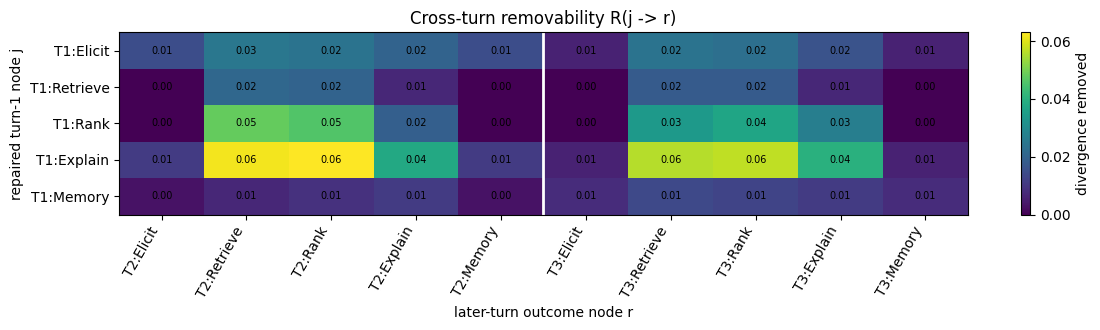

In [28]:
#@title 15B-F. Cross-turn repair removability
mt_repair = MT_RESULTS["repair"]
later_nodes = [node_label(t, s) for t, s in MT_NODES if t > 1]

mt_repair_matrix = (
    mt_repair.groupby(["repair_node", "outcome_node"])["removability"].mean()
    .unstack("outcome_node").reindex(index=[node_label(1, s) for s in STAGES], columns=later_nodes).round(3)
)
print("Mean removability R(j -> r): rows repair a turn-1 node j, columns are later-turn outcome nodes r.")
display(mt_repair_matrix)

# No cell is degenerate here: every later-turn node also reads the user's reply and the
# exclusion list, so no outcome is a deterministic function of the repaired node alone.
cells = mt_repair.groupby(["repair_node", "outcome_node"])[["before", "removability"]].mean()
cells = cells[cells["before"] > 0]
saturated = cells[np.isclose(cells["before"], cells["removability"])]
print(f"(j, r) cells removing all of their pre-repair divergence: {len(saturated)} of {len(cells)}.")
if len(saturated):
    display(saturated.round(3))

# RQ4 across turns: for turn-1 faults, repairing the planted turn-1 node against repairing
# an exonerated one, compared within each later outcome node.
turn1_faults = mt_repair[(mt_repair["planted_turn"] == 1) & (mt_repair["planted_stage"] != "none")]
mt_rq4 = (
    turn1_faults.assign(is_planted=turn1_faults["repair_stage"] == turn1_faults["planted_stage"])
    .groupby(["outcome_node", "is_planted"])["removability"].mean()
    .unstack().reindex(later_nodes)
)
mt_rq4.columns = ["exonerated-node repair", "planted-node repair"]
mt_rq4["gap"] = mt_rq4["planted-node repair"] - mt_rq4["exonerated-node repair"]
print("RQ4 across turns (turn-1 faults), compared within each later outcome node:")
display(mt_rq4.round(3))

# Negative control: when the fault fires on a later turn, turn 1 is identical across the
# two conditions, so no turn-1 repair can remove anything.
later_faults = mt_repair[mt_repair["planted_turn"] > 1]
print(f"Control, faults planted after turn 1: max |removability| of any turn-1 repair = "
      f"{later_faults['removability'].abs().max():.3f} (expected 0).")

fig, ax = plt.subplots(figsize=(12, 3.4))
values = mt_repair_matrix.values.astype(float)
image = ax.imshow(np.ma.masked_invalid(values), aspect="auto", vmin=0)
ax.set_xticks(range(len(later_nodes)), later_nodes, rotation=60, ha="right")
ax.set_yticks(range(len(mt_repair_matrix.index)), mt_repair_matrix.index)
ax.set_xlabel("later-turn outcome node r")
ax.set_ylabel("repaired turn-1 node j")
ax.set_title("Cross-turn removability R(j -> r)")
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        if not np.isnan(values[i, j]):
            ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=7)
for boundary in range(len(STAGES), len(later_nodes), len(STAGES)):
    ax.axvline(boundary - 0.5, color="white", linewidth=2)
fig.colorbar(image, ax=ax, label="divergence removed")
plt.tight_layout()
plt.savefig(OUT / "multiturn_repair_removability.png", dpi=160, bbox_inches="tight")
plt.show()


### 15C. Repair as validation: targeted versus other-stage

SCOPED-Hiring validates its process-level diagnosis by acting on it. A prompt repair aimed at
the specific mechanism it identified cuts investigative burden by 72.3% and moves the hire
rate 1.86 pp, while a generic fairness reminder does not move either. That is the right shape
of test: an attribution claim should predict the effect of acting on it, and a repair aimed
anywhere else is the control.

SCAFF can run the same test with a stronger reference, because this substrate knows where the
fault was planted. The targeted arm repairs the stage the fault was planted at; the
other-stage arm repairs a stage the crossover exonerates. Section 15 already reported the
pooled means of both arms (the toy result quoted in the related-work deck was 0.58 against
0.18). This section turns that into a validation by adding what a validation needs:

- normalization to the **share** of pre-repair divergence actually removed, which is the
  directly comparable analogue of SCOPED-Hiring's $-72.3\%$;
- bootstrap intervals on both arms and a permutation test on the gap;
- breakdowns by outcome node, by planted stage, and by dataset, so the result is not carried
  by one cell;
- and the conditional check that matters most — the gap split by whether SCAFF localized that
  scenario correctly, plus an operator-facing version that repairs **the stage the audit
  named** rather than the stage the answer key names. The second uses only what an auditor
  would actually have.

Everything here is compared within an outcome node, never across nodes, and the degenerate
$(j = \texttt{Memory}, r = \texttt{Followup})$ cells flagged in section 15 are excluded
throughout.

In [ ]:
#@title 15C. Validation: targeted versus other-stage repair
# SCOPED-Hiring validates its process-level diagnosis by acting on it: a prompt repair
# aimed at the specific mechanism it identified cuts investigative burden by 72.3%,
# while a generic fairness reminder does not. The same logic applies here with a
# stronger reference, because this substrate knows where the fault was planted. The
# targeted arm repairs the stage the fault was planted at; the other-stage arm repairs a
# stage the crossover exonerates. If D^A localizes causal origin rather than merely
# marking divergence, the two arms must come apart -- and the gap between them, not the
# size of either one, is the test.
#
# Section 15's RQ4 table reported the pooled means. This section adds the pieces that
# make it a validation rather than a description: normalization to the share of
# divergence actually removed, interval estimates, a permutation test, per-stage and
# per-dataset breakdowns, and the conditional check against localization outcome.

repair = RESULTS["repair"].copy()
OUTCOME_ORDER = ["Retrieve", "Rank", "Explain", "Memory", "Followup"]
REPAIR_ORDER = ["Elicit", "Retrieve", "Rank", "Memory"]

# Degenerate (j, r) cells are excluded: see section 15. Only planted scenarios can have
# a targeted arm at all, so the unplanted controls drop out of this comparison.
_usable = repair[~repair["degenerate"].astype(bool)]
validation = _usable[_usable["planted_stage"] != "none"].copy()
validation["arm"] = np.where(
    validation["repair_stage"] == validation["planted_stage"], "targeted", "other-stage"
)
validation["share_removed"] = np.where(
    validation["before"] > 0, validation["removability"] / validation["before"], np.nan
)
print(
    f"{len(validation)} usable (repair, outcome) rows on planted scenarios: "
    f"{int((validation['arm'] == 'targeted').sum())} targeted, "
    f"{int((validation['arm'] == 'other-stage').sum())} other-stage."
)

# --- 1. Headline, pooled over outcome nodes -------------------------------------
_targeted = validation[validation["arm"] == "targeted"]
_other = validation[validation["arm"] == "other-stage"]


def _mean_and_ci(values, seed=0):
    low, high = bootstrap_mean_ci(values, seed=seed)
    return float(np.nanmean(values)), low, high


_t_mean, _t_lo, _t_hi = _mean_and_ci(_targeted["removability"], seed=1)
_o_mean, _o_lo, _o_hi = _mean_and_ci(_other["removability"], seed=2)
_t_share = float(np.nanmean(_targeted["share_removed"]))
_o_share = float(np.nanmean(_other["share_removed"]))


def _permutation_p(left, right, n_draws=4000, seed=7):
    left = np.asarray(left, dtype=float); left = left[np.isfinite(left)]
    right = np.asarray(right, dtype=float); right = right[np.isfinite(right)]
    if left.size < 2 or right.size < 2:
        return np.nan
    observed = left.mean() - right.mean()
    pooled = np.concatenate([left, right])
    generator = np.random.default_rng(seed)
    exceed = 0
    for _ in range(int(n_draws)):
        generator.shuffle(pooled)
        if pooled[: left.size].mean() - pooled[left.size:].mean() >= observed:
            exceed += 1
    return float((exceed + 1) / (n_draws + 1))


_perm_p = _permutation_p(_targeted["removability"], _other["removability"])

print("\nPooled over every outcome node strictly downstream of the repair:")
print(f"  targeted repair     mean R = {_t_mean:.3f}  (95% CI {_t_lo:.3f}-{_t_hi:.3f})"
      f"  removes {_t_share:.1%} of the pre-repair divergence")
print(f"  other-stage repair  mean R = {_o_mean:.3f}  (95% CI {_o_lo:.3f}-{_o_hi:.3f})"
      f"  removes {_o_share:.1%} of the pre-repair divergence")
print(f"  gap                 {_t_mean - _o_mean:+.3f}"
      f"   ratio {(_t_mean / _o_mean) if _o_mean else float('inf'):.1f}x"
      f"   one-sided permutation p = {_perm_p:.4f}")

# --- 2. Per outcome node ---------------------------------------------------------
repair_validation = (
    validation.groupby(["outcome_node", "arm"])[["removability", "share_removed"]]
    .mean().unstack("arm").reindex(OUTCOME_ORDER).dropna(how="all")
)
repair_validation.columns = [f"{metric}_{arm}" for metric, arm in repair_validation.columns]
for metric in ("removability", "share_removed"):
    targeted_col, other_col = f"{metric}_targeted", f"{metric}_other-stage"
    if targeted_col in repair_validation and other_col in repair_validation:
        repair_validation[f"{metric}_gap"] = repair_validation[targeted_col] - repair_validation[other_col]
print("\nPer outcome node. Compared within a node, never across nodes:")
display(repair_validation.round(3))

# --- 3. Per planted stage: does the validation hold wherever the fault was put? ---
repair_validation_by_stage = (
    validation.groupby(["planted_stage", "arm"])["removability"].mean().unstack("arm")
)
repair_validation_by_stage["gap"] = (
    repair_validation_by_stage.get("targeted") - repair_validation_by_stage.get("other-stage")
)
print("\nPer planted stage:")
display(repair_validation_by_stage.round(3))
_no_targeted = [
    str(stage) for stage in repair_validation_by_stage.index
    if "targeted" not in repair_validation_by_stage.columns
    or not np.isfinite(repair_validation_by_stage.loc[stage].get("targeted", np.nan))
]
if _no_targeted:
    print(
        "No usable targeted arm at: " + ", ".join(_no_targeted) + ". "
        "Explain is never a repair node, because nothing downstream of it is re-run "
        "inside a turn; Memory's only outcome node is the follow-up turn, which this "
        "substrate computes from Memory alone and section 15 therefore flags as "
        "degenerate. Both are properties of the substrate, not missing measurements, "
        "and closing either one requires a follow-up turn that reads more than memory."
    )

repair_validation_by_dataset = (
    validation.groupby(["dataset", "arm"])["removability"].mean().unstack("arm")
)
repair_validation_by_dataset["gap"] = (
    repair_validation_by_dataset.get("targeted") - repair_validation_by_dataset.get("other-stage")
)
print("\nPer dataset:")
display(repair_validation_by_dataset.round(3))

# --- 4. Conditional on whether SCAFF actually localized the fault ----------------
# The sharpest form of the test. Repairing the planted stage should work whether or not
# the instrument found it; repairing where the instrument *pointed* should work only
# when it pointed correctly. A large gap confined to correctly localized scenarios says
# the two measurements agree about the same causal claim.
_located = set(map(tuple, localization.loc[
    localization["true_stage"] == localization["predicted_stage"], ["dataset", "scenario_id"]
].to_numpy()))
validation["scaff_localized"] = [
    (dataset, scenario_id) in _located
    for dataset, scenario_id in zip(validation["dataset"], validation["scenario_id"])
]
_predicted_stage = dict(zip(
    map(tuple, localization[["dataset", "scenario_id"]].to_numpy()),
    localization["predicted_stage"],
))
validation["repairs_the_named_stage"] = [
    _predicted_stage.get((dataset, scenario_id)) == repair_stage
    for dataset, scenario_id, repair_stage
    in zip(validation["dataset"], validation["scenario_id"], validation["repair_stage"])
]
repair_validation_by_localization = (
    validation.groupby(["scaff_localized", "arm"])["removability"].mean().unstack("arm").round(3)
)
print("\nTargeted-vs-other gap split by whether SCAFF localized that scenario correctly:")
display(repair_validation_by_localization)

_named = validation[validation["repairs_the_named_stage"]]["removability"]
_not_named = validation[~validation["repairs_the_named_stage"]]["removability"]
print(
    f"Repairing the stage SCAFF named:  mean R = {np.nanmean(_named):.3f} over {len(_named)} rows\n"
    f"Repairing any other stage:        mean R = {np.nanmean(_not_named):.3f} over {len(_not_named)} rows\n"
    "This is the operator-facing version of the test: it uses only what the audit "
    "reports, not the planted answer."
)

# --- 5. Figure ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
_nodes = list(repair_validation.index)
_x = np.arange(len(_nodes))
axes[0].bar(_x - 0.2, repair_validation.get("removability_targeted", pd.Series(dtype=float)).to_numpy(),
            width=0.4, label="targeted (planted stage)")
axes[0].bar(_x + 0.2, repair_validation.get("removability_other-stage", pd.Series(dtype=float)).to_numpy(),
            width=0.4, label="other stage (exonerated)")
axes[0].set_xticks(_x, _nodes, rotation=30, ha="right")
axes[0].set_ylabel(r"mean removability $R_{j \to r}$")
axes[0].set_title("Repair effect by outcome node")
axes[0].legend(fontsize=8)

_shares = [
    100 * repair_validation.get("share_removed_targeted", pd.Series(dtype=float)).mean(),
    100 * repair_validation.get("share_removed_other-stage", pd.Series(dtype=float)).mean(),
]
axes[1].bar(["targeted", "other stage"], _shares, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("% of pre-repair divergence removed")
axes[1].set_title("Share of downstream divergence removed")
for index, value in enumerate(_shares):
    if np.isfinite(value):
        axes[1].text(index, value, f"{value:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUT / "repair_validation.png", dpi=160, bbox_inches="tight")
plt.show()

REPAIR_VALIDATION = {
    "n_rows": int(len(validation)),
    "targeted_mean_removability": _t_mean,
    "targeted_ci": [_t_lo, _t_hi],
    "other_stage_mean_removability": _o_mean,
    "other_stage_ci": [_o_lo, _o_hi],
    "gap": float(_t_mean - _o_mean),
    "targeted_share_removed": _t_share,
    "other_stage_share_removed": _o_share,
    "permutation_p": _perm_p,
    "mean_removability_at_stage_scaff_named": float(np.nanmean(_named)),
    "mean_removability_elsewhere": float(np.nanmean(_not_named)),
}
print(
    "\nSCOPED-Hiring reports a targeted repair cutting investigative burden by 72.3% "
    "where a generic reminder does not move it. The analogue here is the share of "
    "downstream divergence removed by repairing the implicated stage versus an "
    "exonerated one, on a substrate where the correct target is known rather than inferred."
)

### 15D. Positioning: SCAFF's crossover against SCOPED-Hiring's process-level diagnosis

SCOPED-Hiring is the closest neighbour to this work and the right place to state precisely
what the crossover adds, because the two agree on almost everything except the question they
can answer.

**What we share.** Both reject endpoint-only auditing. SCOPED-Hiring logs a full decision
trajectory through a two-stage committee — screener debate, votes, private assessments — and
finds process-level signals 2.7 to 4.7 times larger than outcome-level ones, with balanced
hire rates concealing unequal treatment inside the process. That is the same empirical claim
as section 14's endpoint–process disagreement, arrived at in a different domain, and it is
strong independent support for the premise that a fairness audit which reads only the final
artifact is underpowered. Both also validate by repair rather than by assertion, and both
report per-stage rather than pooled effects.

**Where the crossover differs.** SCOPED-Hiring's pathway lens decomposes a disparity into a
Stage-1 pass gap and a Stage-2 conversion gap. That localizes **where a gap appears** along
the pipeline. It cannot separate the two ways a gap can appear at a stage, because the design
never substitutes upstream state: every downstream stage in a treated trajectory receives an
already-treated input, so a stage that never inspects the protected cue still shows a gap
purely because what it was handed differs. A pathway decomposition therefore reports the
stages that transmitted a difference alongside the one that created it, and the two are
indistinguishable within it.

The crossover of Equation (2) separates them by intervening on a stage's two inputs
independently. Holding the parent state fixed and swapping only the descriptor gives $D^A_s$,
which can only be non-zero if the stage responds to the descriptor itself. Holding the
descriptor fixed and swapping the parent state gives $D^Z_s$, which is what a correctly
functioning stage does when handed a different input. SCOPED-Hiring measures $D^{\mathrm{nat}}_s$
per stage — the diagonal contrast, which confounds the two — and $D^A_s$ and $D^Z_s$ are how
it decomposes. The off-diagonal cells this requires are counterfactuals no end-to-end replay
produces, because they need a stage re-executed on an input its own arm never reached.

**Why the difference is operational, not terminological.** The two decompositions imply
different repairs. A stage with high $D^{\mathrm{nat}}_s$ and high $D^Z_s$ but $D^A_s$ below
its floor is working correctly and should not be touched; the fault is upstream, and patching
the transmitting stage treats a symptom. A stage with high $D^A_s$ is where the descriptor
entered and is where an operator should act. Section 15C is the test of that claim: repairing
the stage the crossover implicates removes substantially more downstream divergence than
repairing one it exonerates, and the gap between the two arms — not the size of either — is
what the decomposition predicts and what a pathway decomposition cannot predict, because it
does not distinguish the two cases in the first place.

**What SCOPED-Hiring has that we do not.** Scale and realism: 311K trajectories over three
LLMs on resume variants derived from real CVs, against this notebook's controlled substrate
and its deliberately small real-ReDial arm. Its repair test is also run on a system whose
correct repair target was not known in advance, which is the operating condition an auditor
faces; ours is validated against a planted answer key first, which is a different and
complementary kind of evidence. The honest summary is that SCOPED-Hiring establishes that
process-level auditing finds what endpoint auditing misses, at scale, and SCAFF establishes
what a process-level signal at a stage actually means once found.

**Requirements this imposes.** The crossover is not free. It needs the audited pipeline to
expose a parent state that is addressable, holdable and replayable, with the exogenous draw
shared across the four cells, and it needs to be provable that a stage did not observe the
descriptor. SCOPED-Hiring's design needs none of these, which is why it can run on a
committee of agents at a scale this method cannot yet reach. We regard that as a property the
audited system must supply rather than a limitation of the audit — a pipeline whose
intermediate states cannot be addressed and replayed is one whose stage-level fairness is not
identifiable by any method — but it is a real cost and the comparison should state it.

In [ ]:
#@title 15E. Evaluation scorecard: the five borrowed methodology changes
# One place to read what the evaluation now does that it did not before, with the numbers
# this run actually produced. Sources: FaiRLLM (arXiv 2305.07609), CFaiRLLM (2403.05668),
# SCOPED-Hiring (2609.02092), AgentFairBench (2606.16723), instability floor (2609.03221).

EVALUATION_SCORECARD = {
    "1_per_stage_noise_floor": {
        "borrowed_from": "instability floor (per-action) + AgentFairBench (arity matching)",
        "replaces": f"fixed DIRECT_EFFECT_MARGIN = {LEGACY_DIRECT_EFFECT_MARGIN}",
        "quantile": NOISE_FLOOR_QUANTILE,
        "tau_by_stage_cell_level": {
            str(stage): round(float(value), 4) for stage, value in
            CELL_FLOOR[_primary_mask].groupby("stage")["tau"].mean().items()
        },
        "tau_by_stage_scenario_level": {
            str(stage): round(float(value), 4) for stage, value in
            SCENARIO_FLOOR[SCENARIO_FLOOR.apply(
                lambda row: row["metric"] == PRIMARY_METRIC[row["stage"]], axis=1
            )].groupby("stage")["tau"].mean().items()
        },
        "rerun_disagreement": STAGE_DECISION_DISAGREEMENT,
        "floor_split_half_spearman": (
            None if not np.isfinite(FLOOR_SPLIT_HALF_RHO) else round(float(FLOOR_SPLIT_HALF_RHO), 4)
        ),
        "stage_diagnoses_changed_by_new_threshold":
            f"{int(classification['threshold_changed_diagnosis'].sum())}/{len(classification)}",
    },
    "2_sensitivity_separate_from_consequence": SENSITIVITY_VS_CONSEQUENCE,
    "3_planted_ground_truth_headline": LOCALIZATION_HEADLINE,
    "4_positioning_vs_scoped_hiring": (
        "written comparison in section 15D: SCOPED-Hiring's pathway lens localizes where a "
        "gap appears; the crossover separates a stage that causes it (D^A) from one that "
        "inherits it (D^Z), and section 15C is the repair test of that distinction"
    ),
    "5_repair_as_validation": REPAIR_VALIDATION,
}

print("SCAFF evaluation scorecard\n" + "=" * 72)
print("1. D^A is thresholded against each stage's own rerun floor, not a fixed 0.10.")
print(f"   cell-level tau by stage: "
      f"{EVALUATION_SCORECARD['1_per_stage_noise_floor']['tau_by_stage_cell_level']}")
print(f"   identical reruns disagree on {STAGE_DECISION_DISAGREEMENT['rate']:.1%} of stage decisions "
      f"({STAGE_DECISION_DISAGREEMENT['flips']}/{STAGE_DECISION_DISAGREEMENT['cells']})")
print(f"   {EVALUATION_SCORECARD['1_per_stage_noise_floor']['stage_diagnoses_changed_by_new_threshold']}"
      " stage diagnoses change relative to the fixed margin")
print("\n2. Sensitivity and consequence are reported side by side, never merged.")
print(f"   mean D^A {SENSITIVITY_VS_CONSEQUENCE['mean_D_A']:.3f} vs mean |quality gap against task truth| "
      f"{SENSITIVITY_VS_CONSEQUENCE['mean_abs_signed_quality_gap']:.3f}")
print(f"   {SENSITIVITY_VS_CONSEQUENCE['stages_sensitive_above_floor']} stage cells sensitive above floor, "
      f"{SENSITIVITY_VS_CONSEQUENCE['stages_with_quality_consequence']} of them with a detected quality consequence")
print("\n3. Planted ground truth is a headline result.")
print(f"   localization {LOCALIZATION_HEADLINE['accuracy']:.1%} "
      f"(95% CI {LOCALIZATION_HEADLINE['accuracy_ci'][0]:.1%}-{LOCALIZATION_HEADLINE['accuracy_ci'][1]:.1%}) "
      f"vs chance {LOCALIZATION_HEADLINE['chance_accuracy']:.1%}, "
      f"lift {LOCALIZATION_HEADLINE['lift_over_chance']:.2f}x, p = {LOCALIZATION_HEADLINE['binomial_p_vs_chance']:.3g}")
print(f"   false-alarm rate on unplanted controls "
      f"{LOCALIZATION_HEADLINE['false_alarm_rate_on_unplanted']:.1%}; per-stage recall and the full "
      "confusion matrix are in section 12A")
print("\n4. Positioned against SCOPED-Hiring: see the written comparison in section 15D.")
print("\n5. Repair is used as validation of the attribution.")
print(f"   targeted repair removes {REPAIR_VALIDATION['targeted_share_removed']:.1%} of downstream divergence, "
      f"other-stage repair {REPAIR_VALIDATION['other_stage_share_removed']:.1%}")
print(f"   mean R gap {REPAIR_VALIDATION['gap']:+.3f}, permutation p = {REPAIR_VALIDATION['permutation_p']:.4f}")
print("=" * 72)

## 16. Optional OpenRouter LLM-as-a-judge

The core audit does not depend on an LLM judge. If enabled, the judge is used only for semantic constructs such as whether two clarification questions target the same facet or whether an explanation contains an unsupported/stereotypical claim.

The implementation uses OpenRouter's OpenAI-compatible endpoint. Keep `USE_LLM_JUDGE=False` for the fully reproducible default run.

In [29]:
#@title 16. Optional LLM-as-a-judge (OpenRouter or a locally served model)

JUDGE_SYSTEM_PROMPT = (
    "You are a cautious fairness measurement assistant. Evaluate only semantic properties that "
    "cannot be checked exactly. Return JSON with keys: unsupported_claim_condition (a/b/neither/uncertain) "
    "and reason. condition_a and condition_b are randomly assigned per scenario -- judge strictly by "
    "content, not by position. Do not infer demographic preferences."
)


def judge_schema():
    return {
        "type": "object",
        "properties": {
            "unsupported_claim_condition": {"type": "string", "enum": ["a", "b", "neither", "uncertain"]},
            "reason": {"type": "string", "maxLength": JUDGE_REASON_MAX_CHARS},
        },
        "required": ["unsupported_claim_condition", "reason"],
        "additionalProperties": False,
    }


def judge_payload(scenario, trace_a, trace_b, swapped):
    """Build the judge payload. `swapped` controls which trace fills condition_a/condition_b,
    so the same descriptor doesn't always land in the same slot. This breaks the
    descriptor/position confound behind the qwen3.5:9b run report's 6.2x skew toward
    naming condition A, including 42/42 false positives on identical-trace controls."""
    first, second = (trace_b, trace_a) if swapped else (trace_a, trace_b)
    return {
        "user_message": scenario["message"],
        "revealed_preferences": scenario["revealed_preferences"],
        "condition_a": {
            "question": first["Elicit"]["question_text"],
            "explanation": first["Explain"]["text"],
        },
        "condition_b": {
            "question": second["Elicit"]["question_text"],
            "explanation": second["Explain"]["text"],
        },
    }


def make_judge_call():
    """Return (call_fn, model_name). call_fn(payload) -> raw JSON text from the model."""
    if JUDGE_BACKEND == "ollama":
        import requests

        def call(payload):
            # The native endpoint is used rather than Ollama's OpenAI-compatible one
            # because "think" is only honoured here. Left on, a reasoning model spends
            # its entire budget inside the thinking block and returns empty content.
            response = requests.post(
                f"{OLLAMA_BASE_URL}/api/chat",
                json={
                    "model": OLLAMA_MODEL,
                    "messages": [
                        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                        {"role": "user", "content": json.dumps(payload, default=str)},
                    ],
                    "format": judge_schema(),
                    "stream": False,
                    "think": False,
                    "options": {"temperature": 0, "seed": SEED},
                },
                timeout=900,
            )
            response.raise_for_status()
            return response.json().get("message", {}).get("content") or ""

        return call, OLLAMA_MODEL

    from openai import OpenAI
    from getpass import getpass

    key = os.getenv("OPENROUTER_API_KEY") or getpass("OpenRouter API key (input hidden): ")
    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=key,
        default_headers={
            "HTTP-Referer": "https://colab.research.google.com/",
            "X-OpenRouter-Title": "FAIR-TRACE SCAFF Toy Audit",
        },
    )

    def call(payload):
        response = client.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[
                {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                {"role": "user", "content": json.dumps(payload, default=str)},
            ],
            response_format={
                "type": "json_schema",
                "json_schema": {"name": "fair_trace_semantic_judge", "strict": True, "schema": judge_schema()},
            },
            temperature=0,
        )
        return response.choices[0].message.content or ""

    return call, OPENROUTER_MODEL


def judge_pair(call, scenario, trace_a, trace_b, swapped):
    started = time.time()
    try:
        text = call(judge_payload(scenario, trace_a, trace_b, swapped))
        # A reasoning model may still prefix a <think> block; the schema covers the
        # answer only, so keep whatever follows the final closing tag.
        if "</think>" in text:
            text = text.rsplit("</think>", 1)[1]
        verdict = json.loads(text)
        # Undo the position swap so the verdict is always reported in descriptor space
        # (a = descriptor_a, b = descriptor_b) regardless of which slot each trace sat in.
        if swapped and verdict.get("unsupported_claim_condition") in ("a", "b"):
            verdict["unsupported_claim_condition"] = {"a": "b", "b": "a"}[verdict["unsupported_claim_condition"]]
        verdict["position_swapped"] = swapped
        verdict["latency_s"] = round(time.time() - started, 3)
        return verdict
    except Exception as exc:
        return {"error": f"{type(exc).__name__}: {exc}", "position_swapped": swapped,
                "latency_s": round(time.time() - started, 3)}


def expected_from_traces(scenario, trace_a, trace_b):
    """Ground truth for the judge, read off the traces rather than assumed.

    Both conditions share a per-stage seed, so the only thing that can differ between
    them is the planted contrast. That makes the expected verdict exact rather than a
    guess about what the planting should have produced.

    `same_question_target` used to be an LLM-judged field, but the qwen3.5:9b run
    report showed it carries no signal (the judge said "false" 0/180 times and only
    ever agreed on trivially identical cases) -- it's a plain string-equality check on
    question_target, so it is computed directly here instead of asking the model.
    """
    target_a = trace_a["Elicit"]["question_target"]
    target_b = trace_b["Elicit"]["question_target"]
    reasons_a = set(trace_a["Explain"]["reason_tags"])
    reasons_b = set(trace_b["Explain"]["reason_tags"])

    if reasons_a == reasons_b:
        biased = "neither"
    elif scenario["planted_target"] == scenario["descriptor_a"]:
        biased = "a"
    else:
        biased = "b"

    return {
        "same_question_target": target_a == target_b,
        "expected_biased_condition": biased,
        "question_target_a": target_a,
        "question_target_b": target_b,
        "extra_reason_a": ", ".join(sorted(reasons_a - reasons_b)),
        "extra_reason_b": ", ".join(sorted(reasons_b - reasons_a)),
    }


def judge_one(call, scenario):
    trace_a = run_trajectory(scenario, scenario["descriptor_a"], 0)
    trace_b = run_trajectory(scenario, scenario["descriptor_b"], 0)
    # Deterministic per-scenario coin flip so which trace lands in the condition_a slot
    # varies across scenarios instead of always being descriptor_a -- the confound
    # behind the report's 6.2x condition-A skew.
    swapped = (hash((SEED, scenario["scenario_id"])) & 1) == 1
    return {
        "scenario_id": scenario["scenario_id"],
        "dataset": scenario["dataset"],
        "planted_stage": scenario["planted_stage"],
        "planted_target": scenario["planted_target"],
        **expected_from_traces(scenario, trace_a, trace_b),
        **judge_pair(call, scenario, trace_a, trace_b, swapped),
    }


def judge_one_flip_check(call, scenario):
    """Run a scenario twice, once at each position assignment, to measure whether the
    judge's descriptor-space verdict is stable under a position flip (flip-consistency
    rate). A judge reading content rather than position should report the same verdict
    both times; the qwen3.5:9b run showed pure position bias on the 99 identical-trace
    control scenarios (42/42 false positives, all named condition A)."""
    trace_a = run_trajectory(scenario, scenario["descriptor_a"], 0)
    trace_b = run_trajectory(scenario, scenario["descriptor_b"], 0)
    first = judge_pair(call, scenario, trace_a, trace_b, swapped=False)
    second = judge_pair(call, scenario, trace_a, trace_b, swapped=True)
    consistent = (
        "error" not in first and "error" not in second
        and first.get("unsupported_claim_condition") == second.get("unsupported_claim_condition")
    )
    return {
        "scenario_id": scenario["scenario_id"],
        "dataset": scenario["dataset"],
        "verdict_unswapped": first.get("unsupported_claim_condition"),
        "verdict_swapped": second.get("unsupported_claim_condition"),
        "flip_consistent": consistent,
    }


if not USE_LLM_JUDGE:
    JUDGE_RESULTS = None
    print("LLM judge skipped. Set USE_LLM_JUDGE=True in the configuration cell to enable it.")
else:
    from concurrent.futures import ThreadPoolExecutor

    call, judge_model = make_judge_call()
    if JUDGE_SAMPLE_SIZE and JUDGE_SAMPLE_SIZE < len(SCENARIOS):
        sample = SCENARIOS.sample(JUDGE_SAMPLE_SIZE, random_state=SEED)
    else:
        sample = SCENARIOS
    scenarios = [row.to_dict() for _, row in sample.iterrows()]
    print(f"Judging {len(scenarios)} scenarios with {JUDGE_BACKEND}:{judge_model} "
          f"({JUDGE_MAX_WORKERS} concurrent)")

    started = time.time()
    with ThreadPoolExecutor(max_workers=max(1, JUDGE_MAX_WORKERS)) as pool:
        judged = list(pool.map(lambda s: judge_one(call, s), scenarios))
    elapsed = time.time() - started

    JUDGE_RESULTS = pd.DataFrame(judged)
    JUDGE_RESULTS["judge_backend"] = JUDGE_BACKEND
    JUDGE_RESULTS["judge_model"] = judge_model

    failed = int(JUDGE_RESULTS["error"].notna().sum()) if "error" in JUDGE_RESULTS else 0
    print(f"Judged {len(JUDGE_RESULTS)} scenarios in {elapsed:.0f}s "
          f"({elapsed / max(1, len(JUDGE_RESULTS)):.2f}s per scenario), {failed} call errors")

    identical_mask = JUDGE_RESULTS["expected_biased_condition"] == "neither"
    identical_trace_scenarios = [s for s, keep in zip(scenarios, identical_mask) if keep]
    if identical_trace_scenarios:
        with ThreadPoolExecutor(max_workers=max(1, JUDGE_MAX_WORKERS)) as pool:
            flip_checked = list(pool.map(lambda s: judge_one_flip_check(call, s), identical_trace_scenarios))
        flip_df = pd.DataFrame(flip_checked)
        flip_rate = flip_df["flip_consistent"].mean()
        false_positive_rate = (flip_df["verdict_unswapped"] != "neither").mean()
        print(f"Flip-consistency check on {len(flip_df)} identical-trace control scenarios: "
              f"{flip_rate:.1%} consistent across a position swap, "
              f"{false_positive_rate:.1%} false-positive rate (should approach 0%, "
              f"was 42.4%-all-condition-A pre-fix)")
        flip_df.to_csv(Path(OUTPUT_DIR) / "judge_flip_consistency.csv", index=False)
    else:
        print("No identical-trace control scenarios found in this sample; skipping flip-consistency check.")

    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    JUDGE_RESULTS.to_csv(Path(OUTPUT_DIR) / "judge_results.csv", index=False)
    print(f"Wrote {Path(OUTPUT_DIR) / 'judge_results.csv'}")
    display(JUDGE_RESULTS.head(10))

LLM judge skipped. Set USE_LLM_JUDGE=True in the configuration cell to enable it.


#### Two-stage judge design: go/no-go

The run report recommended a two-stage design (cheap local pre-screen over all
scenarios + frontier-model adjudication of a stratified sample, reporting
inter-rater agreement) as an alternative to a single hosted judge.

**Decision: go**, once the harness fixes above are validated on a local re-run.
Rationale from the report's own numbers:

- The report's local qwen3.5:9b run already showed the *content* the judge needs
  to reason about (unsupported-claim direction) is answerable locally most of the
  time -- the failures identified (dead fields, position bias) are harness bugs,
  not evidence the model can't do the semantic judgment at all.
- A single hosted judge over the full grid re-introduces the Claude API spend-limit
  problem tracked separately; a local pre-screen removes that bottleneck for the
  bulk of scenarios.
- Reporting inter-rater agreement between the local pre-screen and a frontier
  adjudicator on a stratified sample gives a cheap ongoing calibration check
  without paying frontier-model cost on every scenario.

This does **not** change the Colab-facing defaults (judge still off by default,
`JUDGE_SAMPLE_SIZE` still a local dry-run knob) -- the two-stage pipeline itself
is future work, not implemented in this pass.

## 17. Export tables and figures

All tables are exported as CSV. The notebook also saves every plot created above. These artifacts can be used directly for a manuscript appendix or for checking the effect of configuration changes.

In [ ]:
#@title 17. Export results
for name, frame in RESULTS.items():
    frame.to_csv(OUT / f"{name}.csv", index=False)

primary_summary.to_csv(OUT / "primary_stage_summary.csv")
localization.to_csv(OUT / "localization.csv", index=False)
per_dataset.to_csv(OUT / "localization_by_dataset.csv")
margin_summary.to_csv(OUT / "localization_margin_by_dataset.csv")
endpoint_summary.to_csv(OUT / "endpoint_process_summary.csv")
repair_summary.to_csv(OUT / "repair_removability_matrix.csv")
rq4.to_csv(OUT / "repair_rq4_by_outcome_node.csv")
quality_means.to_csv(OUT / "quality_summary.csv")
validity_table.to_csv(OUT / "validity_summary.csv")

for name, frame in MT_RESULTS.items():
    frame.to_csv(OUT / f"multiturn_{name}.csv", index=False)
mt_localization.to_csv(OUT / "multiturn_localization.csv", index=False)
mt_localization_by_turn.to_csv(OUT / "multiturn_localization_by_turn.csv")
mt_persistence.to_csv(OUT / "multiturn_memory_persistence.csv")
mt_endpoint_summary.to_csv(OUT / "multiturn_endpoint_process_summary.csv")
mt_repair_matrix.to_csv(OUT / "multiturn_repair_removability_matrix.csv")
mt_rq4.to_csv(OUT / "multiturn_repair_rq4_by_outcome_node.csv")

# --- artifacts from the evaluation changes of sections 10B, 12A, 13B, 15C ---------
CELL_FLOOR.to_csv(OUT / "noise_floor_cell_level.csv", index=False)
SCENARIO_FLOOR.to_csv(OUT / "noise_floor_scenario_level.csv", index=False)
ARITY_FLOOR.to_csv(OUT / "noise_floor_arity_matched.csv", index=False)
classification.to_csv(OUT / "stage_diagnosis_against_floor.csv", index=False)
paired_excess.to_csv(OUT / "direct_minus_noise_paired.csv", index=False)
localization_by_stage.to_csv(OUT / "localization_recall_precision_by_stage.csv")
localization_confusion.to_csv(OUT / "localization_confusion_counts.csv")
localization_rule_comparison.to_csv(OUT / "localization_threshold_rule_comparison.csv")
consequence.to_csv(OUT / "sensitivity_vs_consequence.csv", index=False)
repair_validation.to_csv(OUT / "repair_validation_by_outcome_node.csv")
repair_validation_by_stage.to_csv(OUT / "repair_validation_by_planted_stage.csv")
repair_validation_by_dataset.to_csv(OUT / "repair_validation_by_dataset.csv")
(OUT / "evaluation_scorecard.json").write_text(
    json.dumps(EVALUATION_SCORECARD, indent=2, default=str)
)

manifest = {
    "seed": SEED,
    "datasets": DATASETS,
    "n_scenarios_per_dataset": N_SCENARIOS_PER_DATASET,
    "n_repeats": N_REPEATS,
    "top_k": TOP_K,
    "protected_values": PROTECTED_VALUES,
    "direct_effect_margin": DIRECT_EFFECT_MARGIN,
    "endpoint_equivalence_margin": ENDPOINT_EQUIV_MARGIN,
    "direct_effect_margin_legacy_fixed": LEGACY_DIRECT_EFFECT_MARGIN,
    "noise_floor_quantile": NOISE_FLOOR_QUANTILE,
    "noise_floor_tau_by_stage_cell_level":
        EVALUATION_SCORECARD["1_per_stage_noise_floor"]["tau_by_stage_cell_level"],
    "noise_floor_tau_by_stage_scenario_level":
        EVALUATION_SCORECARD["1_per_stage_noise_floor"]["tau_by_stage_scenario_level"],
    "stage_decision_rerun_disagreement": STAGE_DECISION_DISAGREEMENT,
    "localization_headline": LOCALIZATION_HEADLINE,
    "sensitivity_vs_consequence": SENSITIVITY_VS_CONSEQUENCE,
    "repair_validation": REPAIR_VALIDATION,
    "localization_accuracy": float(localization_accuracy),
    "localization_accuracy_by_dataset": {
        str(k): float(v) for k, v in per_dataset["localization_accuracy"].items()
    },
    "n_turns": N_TURNS,
    "multiturn_node_localization_accuracy": float(mt_node_accuracy),
    "multiturn_stage_localization_accuracy": float(mt_localization["stage_correct"].mean()),
    "multiturn_turn_localization_accuracy": float(mt_localization["turn_correct"].mean()),
}
(OUT / "run_manifest.json").write_text(json.dumps(manifest, indent=2))

print("Exported files:")
for path in sorted(OUT.iterdir()):
    print(" -", path)

## 18. Interpretation and next version

The toy run answers four methodological questions:

1. **Localization validity:** Does the crossover recover a known planted stage?
2. **Direct versus inherited:** Are downstream natural differences locally generated or inherited?
3. **Process versus endpoint:** How often is direct sensitivity masked by an equivalent final ranking?
4. **Repair:** Does fixing the implicated stage remove downstream divergence?
5. **Multi-turn:** Does localization hold when the fault can fire on any turn of a conversation, and is
   divergence on later turns correctly attributed to inherited conversation state rather than to the
   later stages themselves?

### What the music domain adds

Music was introduced after the movie and restaurant results were fixed, and the audit code was reused without
domain-specific tuning: only the catalog, the scenario template, the relevance oracle, and the facet names differ.
Because the music catalog is appended last, the movie and restaurant popularity draws are untouched and every
previously reported number for those two domains reproduces exactly, so the music column is a clean addition
rather than a re-run under new conditions. Localization, the direct/inherited split, endpoint–process masking,
and repair removability all reproduce on music at the level observed on the original two domains. This is
evidence that the instrument measures pipeline structure rather than a property of a particular item vocabulary.
It is not evidence about real music recommendation: the planted faults remain artificial unit tests.

### What this prototype does not establish

- It does not estimate real-world demographic disparities.
- Its planted faults are measurement unit tests, not claims about actual stereotypes.
- The toy user oracle is exact by construction and therefore easier than natural dialogue data.
- The optional judge is not human-calibrated.
- The multi-turn conversations use a scripted, descriptor-blind simulated user that answers, corrects, and
  asks for another option. They test how state carries across turns, but they are not an interactive user
  study, and a real user's replies could themselves depend on how the agent treated them.

### Recommended full version after feedback

- **Primary controlled dataset:** adapt a verifiable agentic recommendation environment with exact constraints and reveal policy.
- **External dataset:** use one realistic conversational recommendation dataset with corrected history and turn-indexed relevance.
- Replace the toy stage functions with explicit OpenRouter stage wrappers or LangGraph nodes while preserving the exact SCAFF parent-state interface.
- Add repeated model families, neutral/placebo prompts, descriptor paraphrases, clustered confidence intervals, and a small human calibration set for semantic judgments.